# New API Implementation

## GLR detector for exponential families — `ExponentialFamilyGLR`

This section implements a **new-API-compatible** (`ScoreModel` protocol) version of the
general GLR changepoint detector for canonical exponential families.

**Recap:** For a canonical exponential family $p(y|\theta) = \eta(y)\exp(\theta^\top h(y) - A(\theta))$, the GLR statistic for a candidate changepoint $b$ at time $t$ is:
$$f_b^{(t)} = \ell(\hat\theta_{\text{pre}}) + \ell(\hat\theta_{\text{post}}) - \ell(\hat\theta_{\text{null}})$$
where $\ell(\theta; S, n) = \theta^\top S - nA(\theta)$ and $\hat\theta$ are obtained via Newton's method from $\nabla A(\hat\theta) = \bar{h}$.

**New API contract** (from `gridcp.typing.ScoreModel`):
- `init_state()` → fresh state
- `update(state, x)` → updated state (accumulate sufficient statistics)
- `compute_penalised_scores(state, grid_states)` → array of penalised scores, one per candidate

**What the user provides:**
- `h` — sufficient statistic (`@nb.njit`)
- `A` — log-partition function (`@nb.njit`)
- For $v=1$ (scalar): `A_prime`, `A_dprime` (`@nb.njit`)
- For $v>1$ (vector): `A_grad`, `A_hess` (`@nb.njit`)

Everything else (MLE solver, GLR kernel, penalty) is built automatically at construction time.

In [1]:
# Imports
# =============================================================================

import numpy as np
import numba as nb
import matplotlib.pyplot as plt
from dataclasses import dataclass

from gridcp import GridDetector
from gridcp.calibration import calibrate_threshold_false_alarm, mc_alarm_times, with_calibrated_threshold
from gridcp.scores import ExponentialFamilyGLR
from gridcp.scores._mean_cusum import MeanCUSUM

print("Imports done.")

Imports done.


## Structured Test Suite — ExponentialFamilyGLR

Comprehensive evaluation of `ExponentialFamilyGLR` across all exponential family scenarios.

**For each scenario** we:
1. Define the canonical `h`, `A`, `A'`, `A''` (or gradient/Hessian for vector cases)
2. **Calibrate** the threshold at alpha = 0.05 via `calibrate_threshold_false_alarm` (Monte Carlo, 2000 null paths)
3. **Single-stream plot**: 3-panel figure (raw data / EF detection statistic / reference, if available)
4. **Simulation study** (K = 1000 paths): detection delay histogram + ECDF + metrics table
5. **Timing comparison**: wall-clock seconds per stream (JIT warm-up excluded)

**Scenarios covered:**

| Nr | Family | v | Reference |
|----|--------|---|-----------|
| 1 | Gaussian mean (known var) | 1 | MeanCUSUM |
| 2 | Gaussian variance (known mean) | 1 | -- |
| 3 | Poisson | 1 | -- |
| 4 | Exponential | 1 | -- |
| 5 | Bernoulli | 1 | -- |
| 6 | Gaussian mean + variance | 2 | -- |
| 7 | MV Gaussian mean (known cov=I) | p=3 | MeanCUSUM |
| 8 | MV Gaussian covariance (known mean=0) | 6 | -- |

In [2]:
# Shared helpers for single-stream and simulation study cells

import time
import numpy as np
import matplotlib.pyplot as plt
from gridcp.detector import GridDetector
from gridcp.calibration import calibrate_threshold_false_alarm, mc_alarm_times

# ---- Constants ----
K_CAL   = 2000   # calibration paths
K_SIM   = 1000   # simulation paths
ALPHA   = 0.05   # false alarm prob
SEED    = 42
K_TIME  = 50     # timing repetitions
PARALLEL = True

# ---- Run one stream and collect outputs + max-score trace ----

def run_and_collect(data, detector):
    """Feed *data* (N, n_features) through *detector*, return (outputs, scores)."""
    state = detector.init_state()
    outputs, scores = [], []
    for t in range(len(data)):
        state, out = detector.update(state, data[t])
        outputs.append(out)
        scores.append(out["max_score"])
    return outputs, np.array(scores)


def first_alarm(outputs):
    for i, o in enumerate(outputs):
        if o["alarm"]:
            return i
    return None


# ---- Plotting: single-stream comparison ----

def plot_scenario(title, data, stats_ef, threshold_ef, alarm_ef, true_cp,
                  *, stats_ref=None, threshold_ref=None, alarm_ref=None,
                  ef_label="ExponentialFamilyGLR", ref_label="MeanCUSUM",
                  data_ylabel="Observation", data_transform=None):
    has_ref = stats_ref is not None
    nrows = 3 if has_ref else 2
    fig, axes = plt.subplots(nrows, 1, figsize=(10, 3.0 * nrows), sharex=True)
    fig.suptitle(title, fontsize=14)

    # Raw data
    raw = data_transform(data) if data_transform is not None else data[:, 0]
    axes[0].plot(raw, lw=0.6, color="steelblue")
    axes[0].axvline(true_cp, ls="--", color="black", label=f"True CP (t*={true_cp})")
    axes[0].legend(loc="upper left", fontsize=9)
    axes[0].set_ylabel(data_ylabel)
    axes[0].set_title("Raw data")

    # EF score
    axes[1].plot(stats_ef, lw=0.8, color="darkorange", label=f"{ef_label}")
    axes[1].axhline(threshold_ef, ls="--", color="red", lw=0.8,
                    label=f"Threshold ({threshold_ef:.2f})")
    if alarm_ef is not None:
        axes[1].axvline(alarm_ef, ls=":", color="darkorange", lw=1.2,
                        label=f"Alarm t={alarm_ef}")
    axes[1].axvline(true_cp, ls="--", color="black", lw=0.6)
    axes[1].legend(loc="upper left", fontsize=9)
    axes[1].set_ylabel("Max score")
    axes[1].set_title(ef_label)

    # Reference score
    if has_ref:
        axes[2].plot(stats_ref, lw=0.8, color="steelblue", label=ref_label)
        axes[2].axhline(threshold_ref, ls="--", color="red", lw=0.8,
                        label=f"Threshold ({threshold_ref:.2f})")
        if alarm_ref is not None:
            axes[2].axvline(alarm_ref, ls=":", color="steelblue", lw=1.2,
                            label=f"Alarm t={alarm_ref}")
        axes[2].axvline(true_cp, ls="--", color="black", lw=0.6)
        axes[2].legend(loc="upper left", fontsize=9)
        axes[2].set_ylabel("Max score")
        axes[2].set_title(ref_label)

    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()


# ---- Simulation study helper ----

def _compute_metrics(alarms, null_alarms, N, true_cp):
    K = len(alarms)
    Knull = len(null_alarms)
    # Only count alarms at or after the true CP as correct detections
    correct = alarms[(alarms < N) & (alarms >= true_cp)]
    false_pre_cp = np.sum((alarms < N) & (alarms < true_cp))  # alarms before CP
    n_correct = len(correct)
    delays = correct - true_cp
    null_fa = np.sum(null_alarms < N)
    return {
        "detection_rate": n_correct / K,
        "miss_rate": 1.0 - n_correct / K,
        "mean_delay": np.mean(delays) if n_correct > 0 else float("nan"),
        "median_delay": np.median(delays) if n_correct > 0 else float("nan"),
        "false_pre_cp": false_pre_cp / K,
        "null_FAR": null_fa / Knull if Knull > 0 else float("nan"),
    }


def run_sim_study(det_ef, det_ref, *, pre_sampler, post_sampler,
                  n_features, N, K, true_cp, rng=SEED):
    """Monte-Carlo simulation: alarm-time arrays for EF (and optionally ref)."""
    print(f"  ExponentialFamilyGLR: mc_alarm_times (K={K}) ...")
    alarms_ef = mc_alarm_times(
        det_ef, n_paths=K, stream_len=N,
        pre_sampler=pre_sampler, post_sampler=post_sampler,
        changepoint=true_cp, parallel=PARALLEL, rng=rng,
    )
    null_alarms_ef = mc_alarm_times(
        det_ef, n_paths=K, stream_len=N,
        pre_sampler=pre_sampler,
        parallel=PARALLEL, rng=rng + 1 if isinstance(rng, int) else rng,
    )
    results = {"alarms_ef": alarms_ef, "null_alarms_ef": null_alarms_ef, "N": N, "true_cp": true_cp}

    if det_ref is not None:
        print(f"  Ref: mc_alarm_times (K={K}) ...")
        alarms_ref = mc_alarm_times(
            det_ref, n_paths=K, stream_len=N,
            pre_sampler=pre_sampler, post_sampler=post_sampler,
            changepoint=true_cp, parallel=PARALLEL, rng=rng,
        )
        null_alarms_ref = mc_alarm_times(
            det_ref, n_paths=K, stream_len=N,
            pre_sampler=pre_sampler,
            parallel=PARALLEL, rng=rng + 1 if isinstance(rng, int) else rng,
        )
        results["alarms_ref"] = alarms_ref
        results["null_alarms_ref"] = null_alarms_ref
    return results


def plot_sim_study(results, title, *, ef_label="ExponentialFamilyGLR",
                   ref_label="MeanCUSUM"):
    N, true_cp = results["N"], results["true_cp"]
    K = len(results["alarms_ef"])
    has_ref = "alarms_ref" in results

    alarms_ef = results["alarms_ef"]
    m_ef = _compute_metrics(alarms_ef, results["null_alarms_ef"], N, true_cp)
    correct_ef = alarms_ef[(alarms_ef < N) & (alarms_ef >= true_cp)]
    delays_ef = correct_ef - true_cp

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{title}  (K={K}, N={N}, CP={true_cp})", fontsize=13)

    axes[0].hist(delays_ef, bins=30, alpha=0.6, color="darkorange",
                 edgecolor="white", label=ef_label, density=True)
    axes[0].set_xlabel("Detection delay (samples)")
    axes[0].set_ylabel("Density")
    axes[0].set_title("Detection delay histogram")

    sorted_ef = np.sort(delays_ef)
    ecdf_ef = np.arange(1, len(sorted_ef) + 1) / K
    axes[1].step(sorted_ef, ecdf_ef, color="darkorange", lw=1.5, label=ef_label, where="post")
    axes[1].set_xlabel("Detection delay (samples)")
    axes[1].set_ylabel("Cumulative proportion")
    axes[1].set_title("Detection delay ECDF")

    if has_ref:
        alarms_ref = results["alarms_ref"]
        m_ref = _compute_metrics(alarms_ref, results["null_alarms_ref"], N, true_cp)
        correct_ref = alarms_ref[(alarms_ref < N) & (alarms_ref >= true_cp)]
        delays_ref = correct_ref - true_cp

        axes[0].hist(delays_ref, bins=30, alpha=0.5, color="steelblue",
                     edgecolor="white", label=ref_label, density=True)
        sorted_ref = np.sort(delays_ref)
        ecdf_ref = np.arange(1, len(sorted_ref) + 1) / K
        axes[1].step(sorted_ref, ecdf_ref, color="steelblue", lw=1.5,
                     label=ref_label, where="post")

    axes[0].legend()
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    # Print metrics table
    header = f"{'Metric':<25} {ef_label:>20}"
    sep    = "-" * 47
    if has_ref:
        header += f" {ref_label:>20}"
        sep = "-" * 68
    print(sep)
    print(header)
    print(sep)
    rows = [
        ("Detection rate",  f"{m_ef['detection_rate']:.3f}"),
        ("Miss rate",       f"{m_ef['miss_rate']:.3f}"),
        ("Mean delay",      f"{m_ef['mean_delay']:.1f}"),
        ("Median delay",    f"{m_ef['median_delay']:.1f}"),
        ("False alarm (<CP)", f"{m_ef['false_pre_cp']:.3f}"),
        ("Null FAR",        f"{m_ef['null_FAR']:.3f}"),
    ]
    if has_ref:
        rows_ref = [
            f"{m_ref['detection_rate']:.3f}",
            f"{m_ref['miss_rate']:.3f}",
            f"{m_ref['mean_delay']:.1f}",
            f"{m_ref['median_delay']:.1f}",
            f"{m_ref['false_pre_cp']:.3f}",
            f"{m_ref['null_FAR']:.3f}",
        ]
        for (name, val_ef), val_ref in zip(rows, rows_ref):
            print(f"{name:<25} {val_ef:>20} {val_ref:>20}")
    else:
        for name, val_ef in rows:
            print(f"{name:<25} {val_ef:>20}")
    print(sep)


# ---- Timing helper ----

def time_detector(detector, pre_sampler, *, n_features, N, K_time=K_TIME):
    """Return mean wall-clock seconds per stream (JIT warm-up excluded)."""
    rng_t = np.random.default_rng(99)
    data = np.empty((K_time + 1, N, n_features), dtype=np.float64)
    for i in range(K_time + 1):
        for t in range(N):
            raw = pre_sampler(rng=rng_t)
            data[i, t, :] = np.asarray(raw, dtype=np.float64).reshape(-1)[:n_features]

    # Warm-up run (JIT compilation)
    state = detector.init_state()
    for t in range(N):
        state, _ = detector.update(state, data[0, t])

    # Timed runs
    start = time.perf_counter()
    for i in range(1, K_time + 1):
        state = detector.init_state()
        for t in range(N):
            state, _ = detector.update(state, data[i, t])
    elapsed = time.perf_counter() - start
    return elapsed / K_time


# ---- Detection delay sweep helpers ----

def sweep_detection_delay(detectors, deltas, *, pre_sampler, post_sampler_factory,
                          N, CP, K=K_SIM, rng=SEED):
    """Sweep over change sizes and compute detection delay statistics.

    Returns
    -------
    dict  {label: {"median": [...], "mean": [...],
                    "q10": [...], "q25": [...], "q75": [...], "q90": [...]}}
    """
    results = {label: {"median": [], "mean": [], "q10": [], "q25": [], "q75": [], "q90": []}
               for label, _ in detectors}
    for i, delta in enumerate(deltas):
        post_sampler = post_sampler_factory(delta)
        for label, det in detectors:
            alarms = mc_alarm_times(
                det, n_paths=K, stream_len=N,
                pre_sampler=pre_sampler, post_sampler=post_sampler,
                changepoint=CP, parallel=PARALLEL, rng=rng,
            )
            dd = alarms - CP
            dd = dd[dd >= 0]
            if len(dd) > 0:
                results[label]["median"].append(np.median(dd))
                results[label]["mean"].append(np.mean(dd))
                results[label]["q10"].append(np.percentile(dd, 10))
                results[label]["q25"].append(np.percentile(dd, 25))
                results[label]["q75"].append(np.percentile(dd, 75))
                results[label]["q90"].append(np.percentile(dd, 90))
            else:
                for key in results[label]:
                    results[label][key].append(np.nan)
    return results


def plot_detection_delay(deltas, results, title, *, xlabel="Change size", borders=True):
    """Plot mean detection delay with IQR and 10-90% quantile bands."""
    colors = ["darkorange", "steelblue", "green", "purple", "red"]
    fig, ax = plt.subplots(figsize=(8, 5))
    for idx, (label, stats) in enumerate(results.items()):
        c = colors[idx % len(colors)]
        avg = np.array(stats["mean"])
        q10 = np.array(stats["q10"])
        q25 = np.array(stats["q25"])
        q75 = np.array(stats["q75"])
        q90 = np.array(stats["q90"])
        if borders:
            ax.fill_between(deltas, q10, q90, color=c, alpha=0.15, label=f"{label} (10–90%)")
            ax.fill_between(deltas, q25, q75, color=c, alpha=0.3, label=f"{label} (IQR)")
        ax.plot(deltas, avg, marker="o", color=c, markersize=4, label=f"{label} (mean)")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Detection delay")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True)
    plt.tight_layout()
    plt.show()


print("Shared helpers defined.")

Shared helpers defined.


Calibrating ExponentialFamilyGLR ...


  EF threshold:      2.9898
Calibrating MeanCUSUM ...
  MeanCUSUM threshold: 2.9898


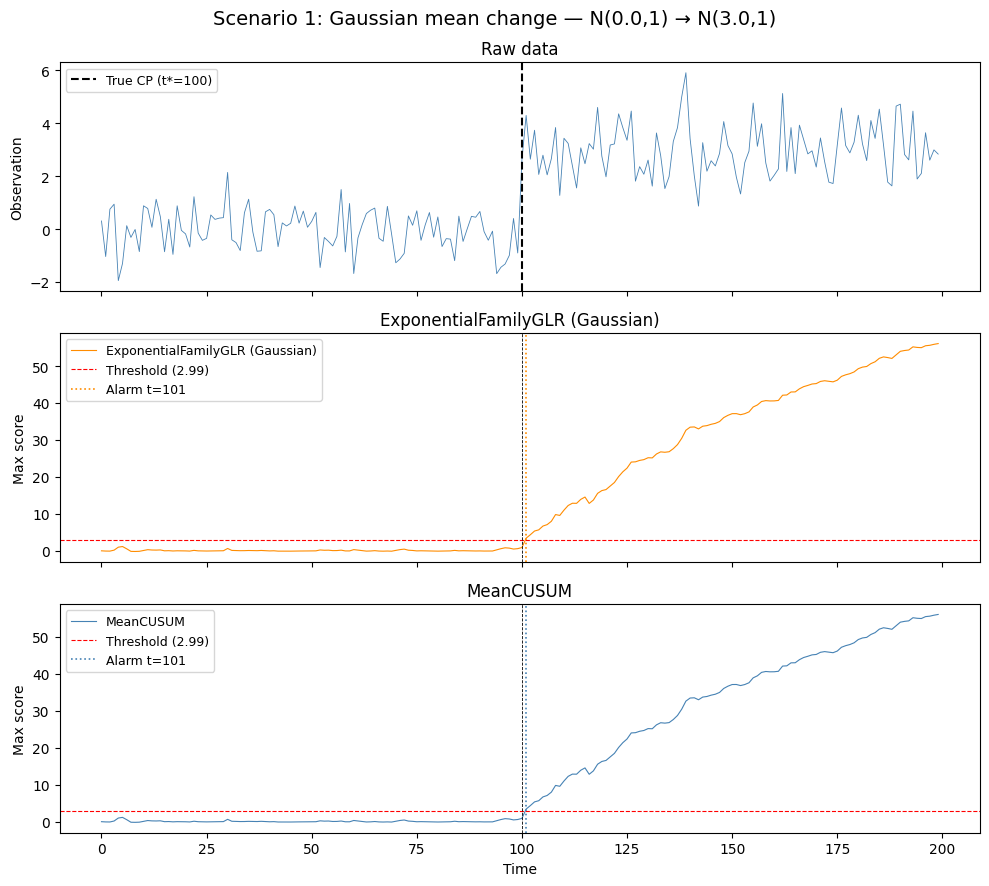

ExponentialFamilyGLR alarm:       101
MeanCUSUM alarm: 101

Running simulation study ...
  ExponentialFamilyGLR: mc_alarm_times (K=1000) ...
  Ref: mc_alarm_times (K=1000) ...


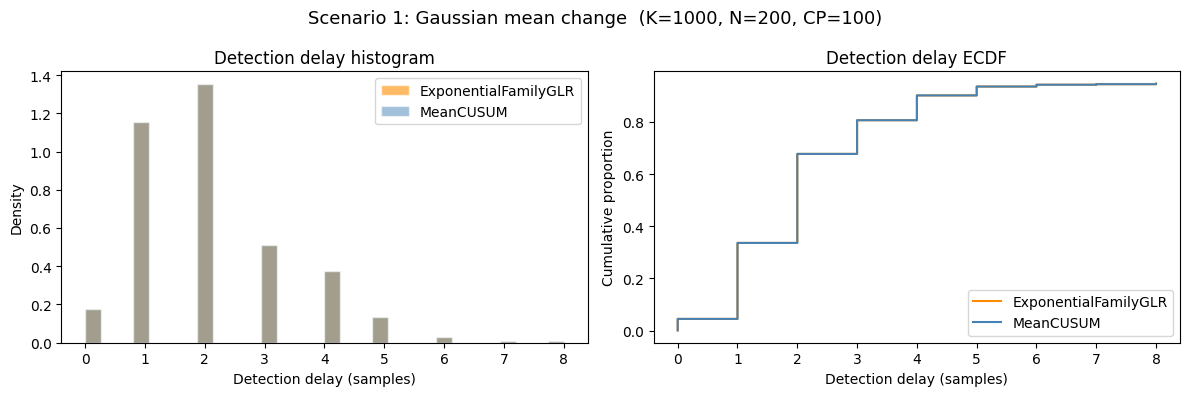

--------------------------------------------------------------------
Metric                    ExponentialFamilyGLR            MeanCUSUM
--------------------------------------------------------------------
Detection rate                           0.946                0.946
Miss rate                                0.054                0.054
Mean delay                                 2.1                  2.1
Median delay                               2.0                  2.0
False alarm (<CP)                        0.054                0.054
Null FAR                                 0.044                0.044
--------------------------------------------------------------------

Timing ...
ExponentialFamilyGLR:       5.3 ms/stream
MeanCUSUM: 4.1 ms/stream
Ratio:     1.30x


In [4]:
# Scenario 1: Univariate Gaussian — change in mean (known variance)
# h(x) = x,  A(θ) = θ²/2,  A'(θ) = θ,  A''(θ) = 1
# Pre: N(0,1) → Post: N(3,1)  |  N=200, CP=100  |  Reference: MeanCUSUM
# =============================================================================

from gridcp.scores import MeanCUSUM

N1, CP1, MU_PRE1, MU_POST1 = 200, 100, 0.0, 3.0
# stream length, changepoint location, pre- and post-change means

# -- h / A functions (reuse from smoke test if already defined) --
@nb.njit
def h1(x):
    return x[0]

@nb.njit
def A1(theta):
    return theta * theta / 2.0

@nb.njit
def Ap1(theta):
    return theta

@nb.njit
def App1(theta):
    return 1.0

# -- Scores --
score1_ef  = ExponentialFamilyGLR(v=1, n_features=1, h=h1, A=A1,
                                     A_prime=Ap1, A_dprime=App1, min_seg=1)
score1_ref = MeanCUSUM(n_features=1)

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR ...")
thr1_ef = calibrate_threshold_false_alarm(
    score1_ef, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N1,
    pre_sampler=lambda rng=None: rng.normal(MU_PRE1, 1.0),
    parallel=PARALLEL, rng=SEED,
)
print(f"  EF threshold:      {thr1_ef:.4f}")

print("Calibrating MeanCUSUM ...")
thr1_ref = calibrate_threshold_false_alarm(
    score1_ref, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N1,
    pre_sampler=lambda rng=None: rng.normal(MU_PRE1, 1.0),
    parallel=PARALLEL, rng=SEED,
)
print(f"  MeanCUSUM threshold: {thr1_ref:.4f}")

# -- Detectors --
det1_ef  = GridDetector(score=score1_ef,  threshold=thr1_ef)
det1_ref = GridDetector(score=score1_ref, threshold=thr1_ref)

# -- Single-stream test --
rng1 = np.random.default_rng(SEED)
data1 = np.concatenate([
    rng1.normal(MU_PRE1,  1.0, (CP1,       1)),
    rng1.normal(MU_POST1, 1.0, (N1 - CP1, 1)),
])
outs1_ef,  stats1_ef  = run_and_collect(data1, det1_ef)
outs1_ref, stats1_ref = run_and_collect(data1, det1_ref)

plot_scenario(
    f"Scenario 1: Gaussian mean change — N({MU_PRE1},{1}) → N({MU_POST1},{1})",
    data1, stats1_ef, thr1_ef, first_alarm(outs1_ef), CP1,
    stats_ref=stats1_ref, threshold_ref=thr1_ref, alarm_ref=first_alarm(outs1_ref),
    ef_label="ExponentialFamilyGLR (Gaussian)", ref_label="MeanCUSUM",
)
print(f"ExponentialFamilyGLR alarm:       {first_alarm(outs1_ef)}")
print(f"MeanCUSUM alarm: {first_alarm(outs1_ref)}")

# -- Simulation study --
print("\nRunning simulation study ...")
res1 = run_sim_study(
    det1_ef, det1_ref,
    pre_sampler=lambda rng=None: rng.normal(MU_PRE1, 1.0),
    post_sampler=lambda rng=None: rng.normal(MU_POST1, 1.0),
    n_features=1, N=N1, K=K_SIM, true_cp=CP1, rng=SEED,
)
plot_sim_study(res1, "Scenario 1: Gaussian mean change",
               ef_label="ExponentialFamilyGLR", ref_label="MeanCUSUM")

# -- Timing --
print("\nTiming ...")
t1_ef  = time_detector(det1_ef,  lambda rng=None: rng.normal(MU_PRE1, 1.0),
                        n_features=1, N=N1)
t1_ref = time_detector(det1_ref, lambda rng=None: rng.normal(MU_PRE1, 1.0),
                        n_features=1, N=N1)
print(f"ExponentialFamilyGLR:       {t1_ef*1000:.1f} ms/stream")
print(f"MeanCUSUM: {t1_ref*1000:.1f} ms/stream")
print(f"Ratio:     {t1_ef/t1_ref:.2f}x")

Scenario 1: sweeping Δμ ...


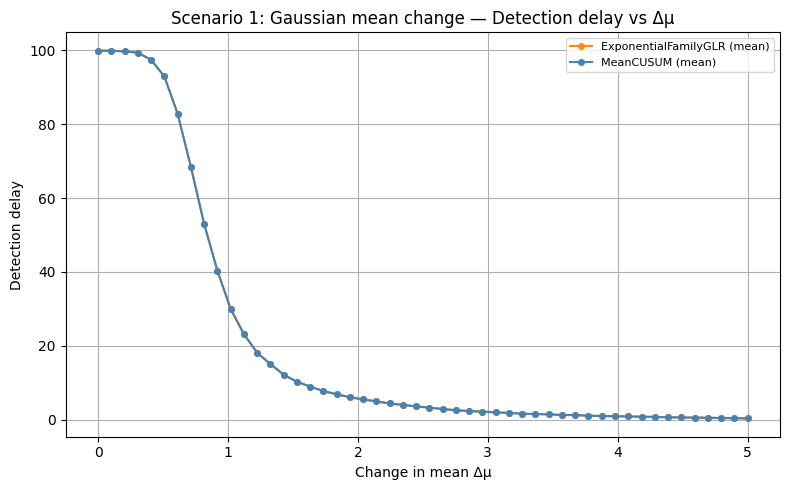

In [6]:
# Scenario 1: Detection delay vs change size (Δμ = μ_post − μ_pre)
# Sweep Δμ from 0 to 5; compare ExponentialFamilyGLR vs MeanCUSUM
# Uses det1_ef, det1_ref, N1, CP1 from the cell above.
# =============================================================================

deltas_1 = np.linspace(0.0, 5.0, num=50)

def post_sampler_factory_1(delta):
    mu_post = MU_PRE1 + delta
    def sampler(rng=None, _d=mu_post):
        return rng.normal(_d, 1.0)
    return sampler

print("Scenario 1: sweeping Δμ ...")
sweep1 = sweep_detection_delay(
    [("ExponentialFamilyGLR", det1_ef), ("MeanCUSUM", det1_ref)],
    deltas_1,
    pre_sampler=lambda rng=None: rng.normal(MU_PRE1, 1.0),
    post_sampler_factory=post_sampler_factory_1,
    N=N1, CP=CP1, K=K_SIM, rng=SEED,
)

plot_detection_delay(
    deltas_1, sweep1,
    "Scenario 1: Gaussian mean change — Detection delay vs Δμ",
    xlabel="Change in mean Δμ",
    borders=False
)

Calibrating ExponentialFamilyGLR (Gaussian variance) ...
  EF threshold: 2.8532


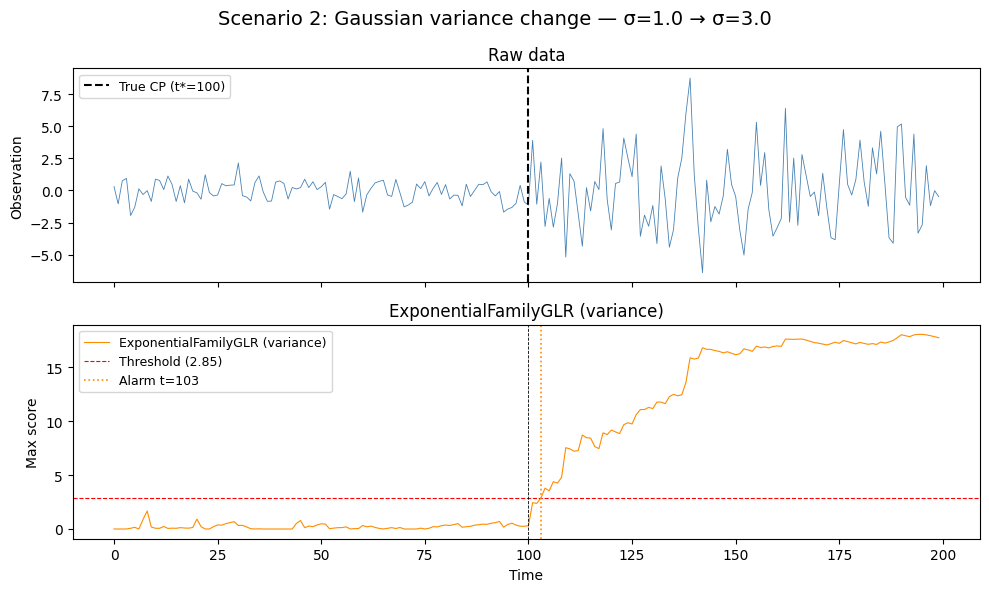

ExponentialFamilyGLR alarm: 103

Running simulation study ...
  ExponentialFamilyGLR: mc_alarm_times (K=1000) ...


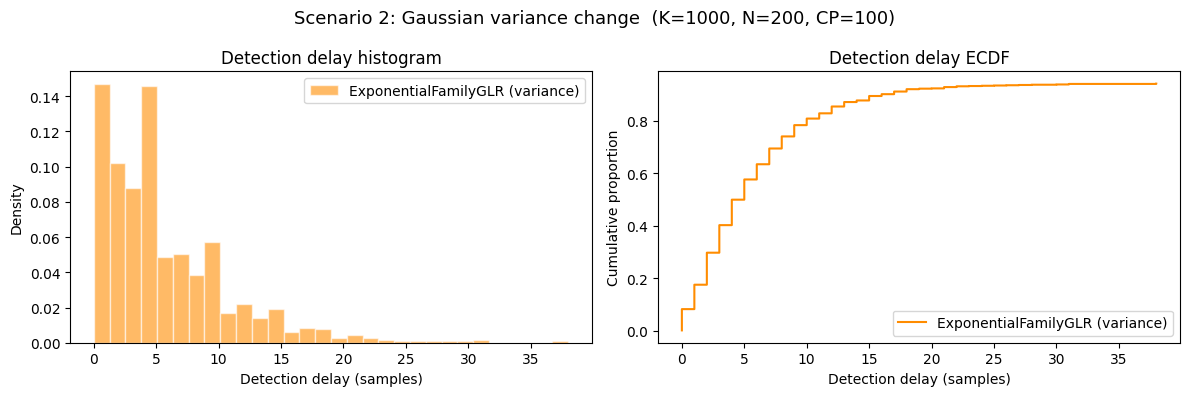

-----------------------------------------------
Metric                    ExponentialFamilyGLR (variance)
-----------------------------------------------
Detection rate                           0.941
Miss rate                                0.059
Mean delay                                 5.6
Median delay                               4.0
False alarm (<CP)                        0.059
Null FAR                                 0.054
-----------------------------------------------

Timing ...
ExponentialFamilyGLR: 6.3 ms/stream


In [9]:
# Scenario 2: Univariate Gaussian — change in variance (known mean = 0)
# h(x) = x²,  A(θ) = -½ log(-2θ),  θ < 0
# Pre: N(0,1) → Post: N(0,3)  |  N=200, CP=100  |  No built-in reference
# =============================================================================

N2, CP2, SIGMA_PRE2, SIGMA_POST2 = 200, 100, 1.0, 3.0

@nb.njit
def h2(x):
    return x[0] * x[0]

@nb.njit
def A2(theta):
    return -0.5 * np.log(-2.0 * theta)

@nb.njit
def Ap2(theta):
    return -1.0 / (2.0 * theta)

@nb.njit
def App2(theta):
    return 1.0 / (2.0 * theta * theta)

score2_ef = ExponentialFamilyGLR(
    v=1, n_features=1, h=h2, A=A2,
    A_prime=Ap2, A_dprime=App2,
    theta_init=-0.5, theta_max=-1e-9, min_seg=2
)

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR (Gaussian variance) ...")
thr2_ef = calibrate_threshold_false_alarm(
    score2_ef, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N2,
    pre_sampler=lambda rng=None: rng.normal(0.0, 1.0),
    parallel=PARALLEL,
)
print(f"  EF threshold: {thr2_ef:.4f}")

det2_ef = GridDetector(score=score2_ef, threshold=thr2_ef)

# -- Single-stream test --
rng2 = np.random.default_rng(SEED)
data2 = np.concatenate([
    rng2.normal(0.0, SIGMA_PRE2,  (CP2,       1)),
    rng2.normal(0.0, SIGMA_POST2, (N2 - CP2, 1)),
])
outs2_ef, stats2_ef = run_and_collect(data2, det2_ef)

plot_scenario(
    f"Scenario 2: Gaussian variance change — σ={SIGMA_PRE2} → σ={SIGMA_POST2}",
    data2, stats2_ef, thr2_ef, first_alarm(outs2_ef), CP2,
    ef_label="ExponentialFamilyGLR (variance)",
)
print(f"ExponentialFamilyGLR alarm: {first_alarm(outs2_ef)}")

# -- Simulation study --
print("\nRunning simulation study ...")
res2 = run_sim_study(
    det2_ef, None,
    pre_sampler=lambda rng=None: rng.normal(0.0, 1.0),
    post_sampler=lambda rng=None: rng.normal(0.0, SIGMA_POST2),
    n_features=1, N=N2, K=K_SIM, true_cp=CP2, rng=SEED,
)
plot_sim_study(res2, "Scenario 2: Gaussian variance change",
               ef_label="ExponentialFamilyGLR (variance)")

# -- Timing --
print("\nTiming ...")
t2_ef = time_detector(det2_ef, lambda rng=None: rng.normal(0.0, 1.0),
                       n_features=1, N=N2)
print(f"ExponentialFamilyGLR: {t2_ef*1000:.1f} ms/stream")

Scenario 2: sweeping Δσ ...


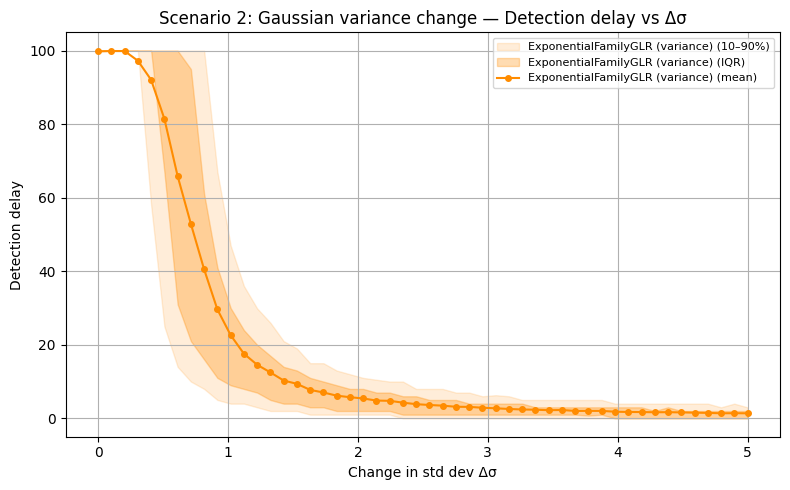

In [24]:
# Scenario 2: Detection delay vs change size (Δσ = σ_post − σ_pre)
# Sweep Δσ from 0 (no change) to 5; EF GLR only
# Uses det2_ef, N2, CP2 from the cell above.
# =============================================================================

delta_sigmas_2 = np.linspace(0.0, 5.0, num=50)

def post_sampler_factory_2(delta_sigma):
    sigma_post = SIGMA_PRE2 + delta_sigma
    def sampler(rng=None, _s=sigma_post):
        return np.random.default_rng().normal(0.0, _s)
    return sampler

print("Scenario 2: sweeping Δσ ...")
sweep2 = sweep_detection_delay(
    [("ExponentialFamilyGLR (variance)", det2_ef)],
    delta_sigmas_2,
    pre_sampler=np.random.default_rng(0).standard_normal,
    post_sampler_factory=post_sampler_factory_2,
    N=N2, CP=CP2, K=K_SIM, rng=SEED,
)

plot_detection_delay(
    delta_sigmas_2, sweep2,
    "Scenario 2: Gaussian variance change — Detection delay vs Δσ",
    xlabel="Change in std dev Δσ",
)

Calibrating ExponentialFamilyGLR (Poisson) ...


  EF threshold: 1.5422


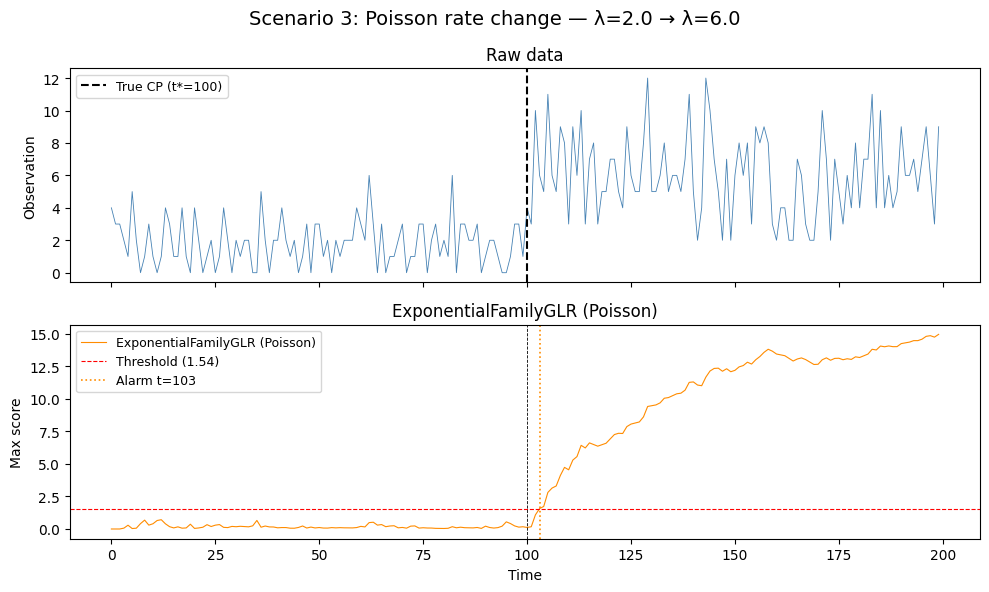

ExponentialFamilyGLR alarm: 103

Running simulation study ...
  ExponentialFamilyGLR: mc_alarm_times (K=1000) ...


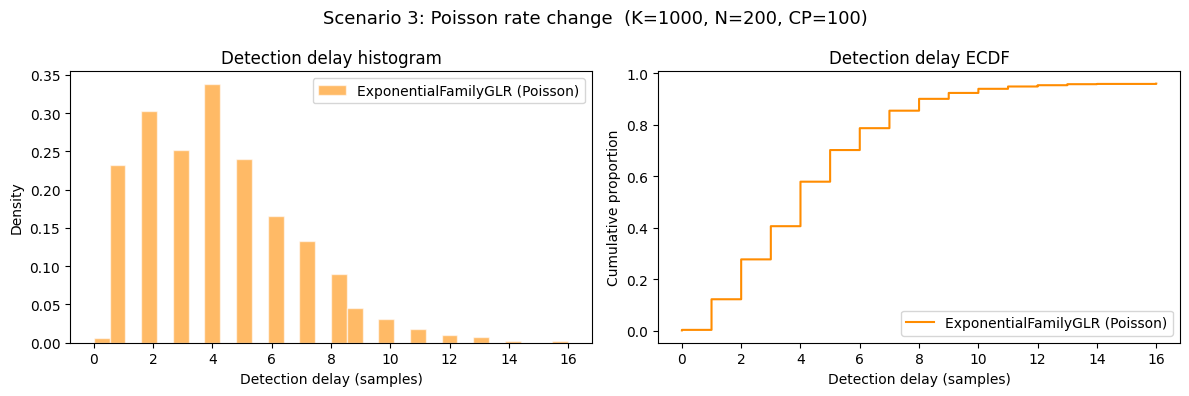

-----------------------------------------------
Metric                    ExponentialFamilyGLR (Poisson)
-----------------------------------------------
Detection rate                           0.960
Miss rate                                0.040
Mean delay                                 4.3
Median delay                               4.0
False alarm (<CP)                        0.040
Null FAR                                 0.051
-----------------------------------------------

Timing ...
ExponentialFamilyGLR: 2.5 ms/stream


In [8]:
# Scenario 3: Poisson — change in rate
# h(x) = x,  A(θ) = exp(θ),  A'(θ) = exp(θ),  A''(θ) = exp(θ)
# Pre: Poisson(2) → Post: Poisson(6)  |  N=1000, CP=500
# =============================================================================

N3, CP3, LAM_PRE3, LAM_POST3 = 200, 100, 2.0, 6.0

@nb.njit
def h3(x):
    return x[0]

@nb.njit
def A3(theta):
    return np.exp(theta)

@nb.njit
def Ap3(theta):
    return np.exp(theta)

@nb.njit
def App3(theta):
    return np.exp(theta)

score3_ef = ExponentialFamilyGLR(v=1, n_features=1, h=h3, A=A3,
                                    A_prime=Ap3, A_dprime=App3)

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR (Poisson) ...")

def _poisson_pre3(rng=None):
    return float(np.random.default_rng().poisson(LAM_PRE3))

def _poisson_post3(rng=None):
    return float(np.random.default_rng().poisson(LAM_POST3))

thr3_ef = calibrate_threshold_false_alarm(
    score3_ef, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N3,
    pre_sampler=_poisson_pre3,
    parallel=PARALLEL, rng=SEED,
)
print(f"  EF threshold: {thr3_ef:.4f}")

det3_ef = GridDetector(score=score3_ef, threshold=thr3_ef)

# -- Single-stream test --
rng3 = np.random.default_rng(SEED)
data3 = np.concatenate([
    rng3.poisson(LAM_PRE3,  (CP3,)).reshape(-1, 1),
    rng3.poisson(LAM_POST3, (N3 - CP3,)).reshape(-1, 1),
]).astype(np.float64)
outs3_ef, stats3_ef = run_and_collect(data3, det3_ef)

plot_scenario(
    f"Scenario 3: Poisson rate change — λ={LAM_PRE3} → λ={LAM_POST3}",
    data3, stats3_ef, thr3_ef, first_alarm(outs3_ef), CP3,
    ef_label="ExponentialFamilyGLR (Poisson)",
)
print(f"ExponentialFamilyGLR alarm: {first_alarm(outs3_ef)}")

# -- Simulation study --
print("\nRunning simulation study ...")
res3 = run_sim_study(
    det3_ef, None,
    pre_sampler=_poisson_pre3, post_sampler=_poisson_post3,
    n_features=1, N=N3, K=K_SIM, true_cp=CP3, rng=SEED,
)
plot_sim_study(res3, "Scenario 3: Poisson rate change",
               ef_label="ExponentialFamilyGLR (Poisson)")

# -- Timing --
print("\nTiming ...")
t3_ef = time_detector(det3_ef, _poisson_pre3, n_features=1, N=N3)
print(f"ExponentialFamilyGLR: {t3_ef*1000:.1f} ms/stream")

Scenario 3: sweeping Δλ ...


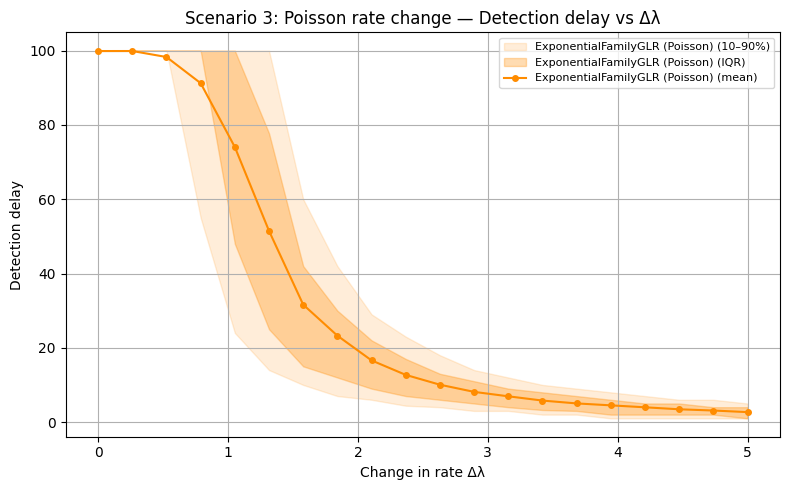

In [25]:
# Scenario 3: Detection delay vs change size (Δλ = λ_post − λ_pre)
# Sweep Δλ from 0 to 5; EF GLR only (no built-in reference for Poisson)
# Uses det3_ef, N3, CP3, LAM_PRE3 from the cell above.
# =============================================================================

deltas_3 = np.linspace(0.0, 5.0, num=20)

def post_sampler_factory_3(delta_lam):
    lam_post = LAM_PRE3 + delta_lam
    def sampler(rng=None, _l=lam_post):
        return float(np.random.default_rng().poisson(_l))
    return sampler

print("Scenario 3: sweeping Δλ ...")
sweep3 = sweep_detection_delay(
    [("ExponentialFamilyGLR (Poisson)", det3_ef)],
    deltas_3,
    pre_sampler=_poisson_pre3,
    post_sampler_factory=post_sampler_factory_3,
    N=N3, CP=CP3, K=K_SIM, rng=SEED,
)

plot_detection_delay(
    deltas_3, sweep3,
    "Scenario 3: Poisson rate change — Detection delay vs Δλ",
    xlabel="Change in rate Δλ",
)

Calibrating ExponentialFamilyGLR (Exponential) ...
  EF threshold: 1.4669


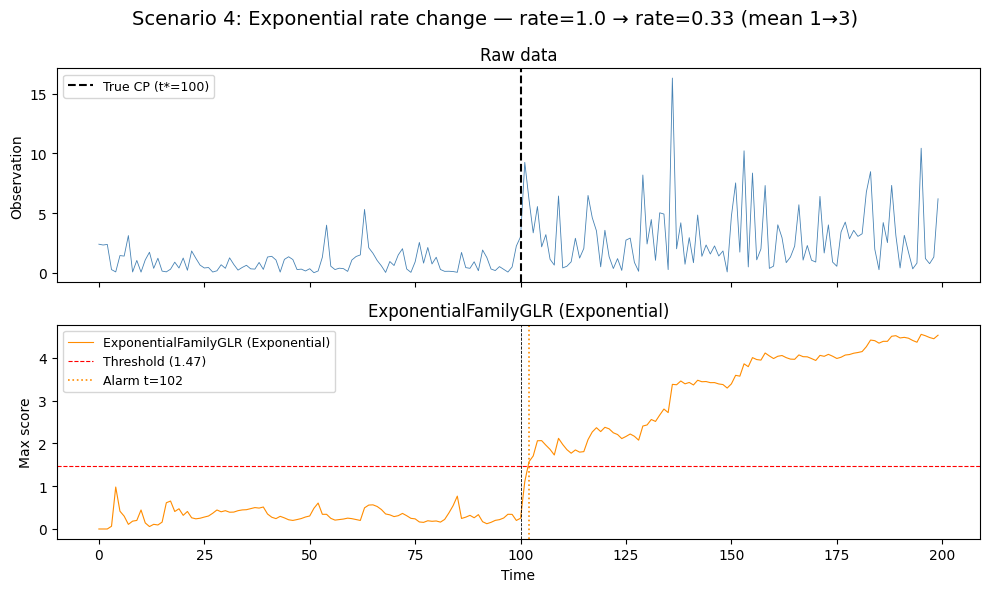

ExponentialFamilyGLR alarm: 102

Running simulation study ...
  ExponentialFamilyGLR: mc_alarm_times (K=1000) ...


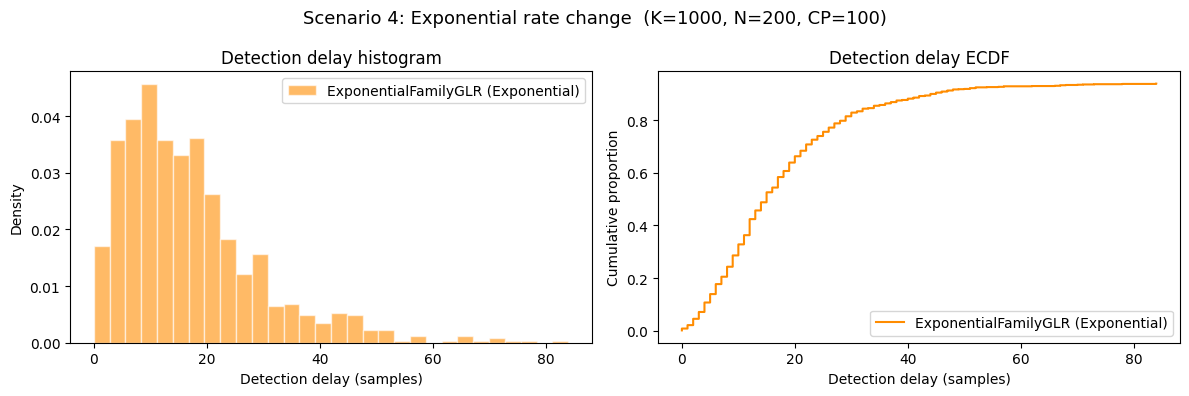

-----------------------------------------------
Metric                    ExponentialFamilyGLR (Exponential)
-----------------------------------------------
Detection rate                           0.939
Miss rate                                0.061
Mean delay                                16.9
Median delay                              14.0
False alarm (<CP)                        0.061
Null FAR                                 0.053
-----------------------------------------------

Timing ...
ExponentialFamilyGLR: 2.4 ms/stream


In [10]:
# Scenario 4: Exponential — change in rate
# h(x) = x,  A(θ) = -log(-θ),  A'(θ) = -1/θ,  A''(θ) = 1/θ²
# θ = -rate  (θ < 0)
# Pre: Exp(rate=1) → Post: Exp(rate=1/3)  (mean 1 → 3)  |  N=1000, CP=500
# =============================================================================

N4, CP4, RATE_PRE4, RATE_POST4 = 200, 100, 1.0, 1.0 / 3.0

@nb.njit
def h4(x):
    return x[0]

@nb.njit
def A4(theta):
    return -np.log(-theta)

@nb.njit
def Ap4(theta):
    return -1.0 / theta

@nb.njit
def App4(theta):
    return 1.0 / (theta * theta)

score4_ef = ExponentialFamilyGLR(
    v=1, n_features=1, h=h4, A=A4,
    A_prime=Ap4, A_dprime=App4,
    theta_init=-1.0,
)

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR (Exponential) ...")

def _exp_pre4(rng=None):
    return float(np.random.default_rng().exponential(1.0 / RATE_PRE4))

def _exp_post4(rng=None):
    return float(np.random.default_rng().exponential(1.0 / RATE_POST4))

thr4_ef = calibrate_threshold_false_alarm(
    score4_ef, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N4,
    pre_sampler=_exp_pre4,
    parallel=PARALLEL, rng=SEED,
)
print(f"  EF threshold: {thr4_ef:.4f}")

det4_ef = GridDetector(score=score4_ef, threshold=thr4_ef)

# -- Single-stream test --
rng4 = np.random.default_rng(SEED)
data4 = np.concatenate([
    rng4.exponential(1.0 / RATE_PRE4,  (CP4,       1)),
    rng4.exponential(1.0 / RATE_POST4, (N4 - CP4, 1)),
])
outs4_ef, stats4_ef = run_and_collect(data4, det4_ef)

plot_scenario(
    f"Scenario 4: Exponential rate change — rate={RATE_PRE4} → rate={RATE_POST4:.2f} (mean 1→3)",
    data4, stats4_ef, thr4_ef, first_alarm(outs4_ef), CP4,
    ef_label="ExponentialFamilyGLR (Exponential)",
)
print(f"ExponentialFamilyGLR alarm: {first_alarm(outs4_ef)}")

# -- Simulation study --
print("\nRunning simulation study ...")
res4 = run_sim_study(
    det4_ef, None,
    pre_sampler=_exp_pre4, post_sampler=_exp_post4,
    n_features=1, N=N4, K=K_SIM, true_cp=CP4, rng=SEED,
)
plot_sim_study(res4, "Scenario 4: Exponential rate change",
               ef_label="ExponentialFamilyGLR (Exponential)")

# -- Timing --
print("\nTiming ...")
t4_ef = time_detector(det4_ef, _exp_pre4, n_features=1, N=N4)
print(f"ExponentialFamilyGLR: {t4_ef*1000:.1f} ms/stream")

Scenario 4: sweeping Δmean ...


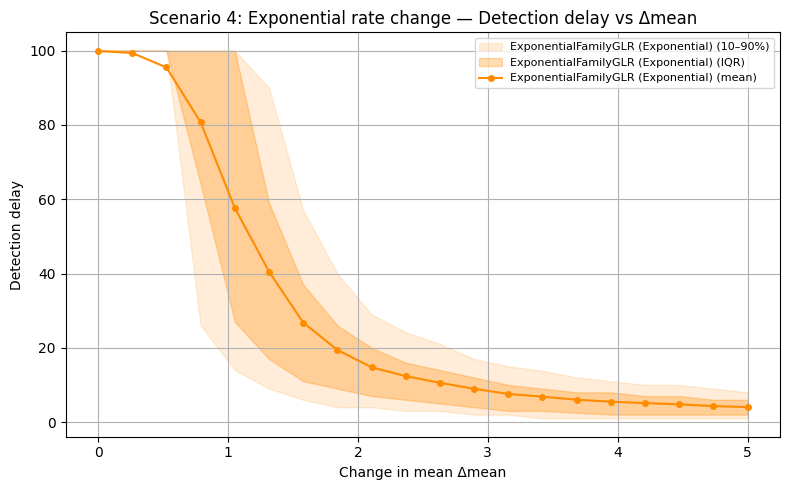

In [26]:
# Scenario 4: Detection delay vs change size (Δmean = mean_post − mean_pre)
# Sweep Δmean from 0 to 5; EF GLR only (no built-in reference for Exponential)
# Uses det4_ef, N4, CP4, RATE_PRE4 from the cell above.
# mean_pre = 1/RATE_PRE4 = 1.0
# =============================================================================

delta_means_4 = np.linspace(0.0, 5.0, num=20)
MEAN_PRE4 = 1.0 / RATE_PRE4

def post_sampler_factory_4(delta_mean):
    mean_post = MEAN_PRE4 + delta_mean
    def sampler(rng=None, _m=mean_post):
        return float(np.random.default_rng().exponential(_m))
    return sampler

print("Scenario 4: sweeping Δmean ...")
sweep4 = sweep_detection_delay(
    [("ExponentialFamilyGLR (Exponential)", det4_ef)],
    delta_means_4,
    pre_sampler=_exp_pre4,
    post_sampler_factory=post_sampler_factory_4,
    N=N4, CP=CP4, K=K_SIM, rng=SEED,
)

plot_detection_delay(
    delta_means_4, sweep4,
    "Scenario 4: Exponential rate change — Detection delay vs Δmean",
    xlabel="Change in mean Δmean",
)

Calibrating ExponentialFamilyGLR (Bernoulli) ...
  EF threshold: 1.4233


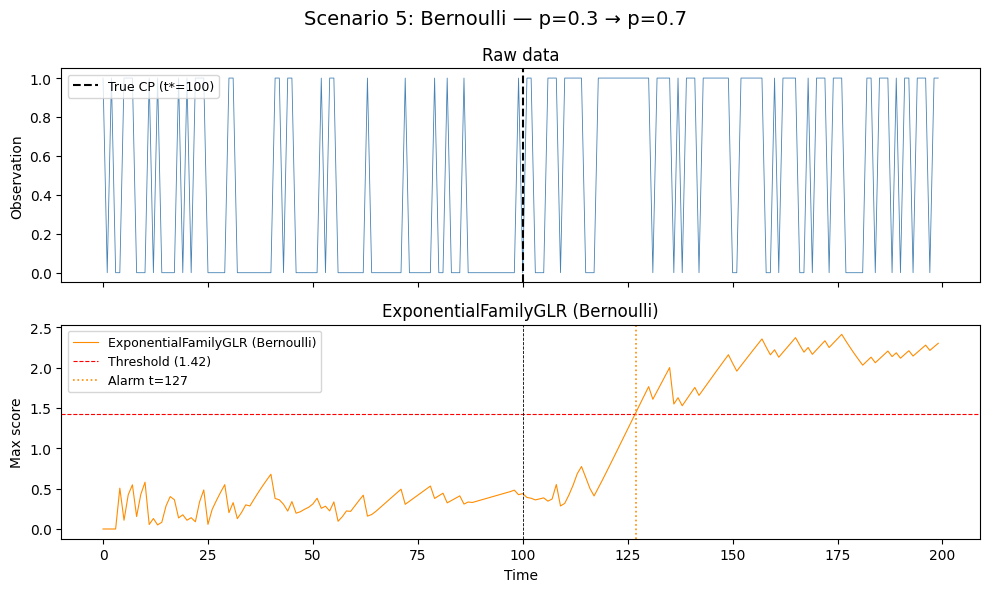

ExponentialFamilyGLR alarm: 127

Running simulation study ...
  ExponentialFamilyGLR: mc_alarm_times (K=1000) ...


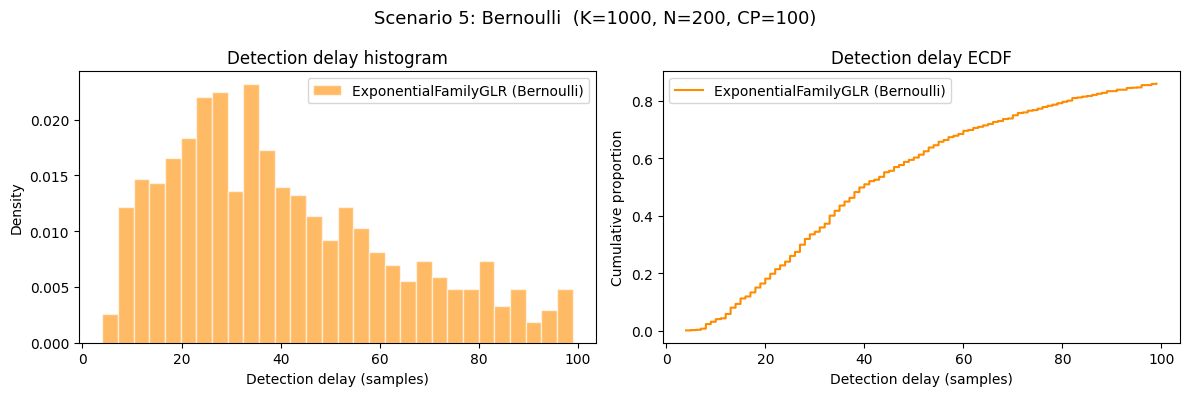

-----------------------------------------------
Metric                    ExponentialFamilyGLR (Bernoulli)
-----------------------------------------------
Detection rate                           0.859
Miss rate                                0.141
Mean delay                                40.3
Median delay                              35.0
False alarm (<CP)                        0.048
Null FAR                                 0.053
-----------------------------------------------

Timing ...
ExponentialFamilyGLR: 2.8 ms/stream


In [12]:
# Scenario 5: Bernoulli — change in success probability
# h(x) = x,  A(θ) = log(1 + exp(θ)),  A' = σ(θ),  A'' = σ(θ)(1-σ(θ))
# Pre: Bernoulli(0.3) → Post: Bernoulli(0.7)  |  N=1000, CP=500
# =============================================================================

N5, CP5, P_PRE5, P_POST5 = 200, 100, 0.3, 0.7

@nb.njit
def h5(x):
    return x[0]

@nb.njit
def A5(theta):
    # log(1 + exp(theta)), numerically stable
    if theta > 30.0:
        return theta
    return np.log1p(np.exp(theta))

@nb.njit
def Ap5(theta):
    # sigmoid
    if theta > 30.0:
        return 1.0
    if theta < -30.0:
        return 0.0
    return 1.0 / (1.0 + np.exp(-theta))

@nb.njit
def App5(theta):
    s = Ap5(theta)
    return s * (1.0 - s)

score5_ef = ExponentialFamilyGLR(v=1, n_features=1, h=h5, A=A5,
                                    A_prime=Ap5, A_dprime=App5)

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR (Bernoulli) ...")

def _bern_pre5(rng=None):
    return float(np.random.default_rng().binomial(1, P_PRE5))

def _bern_post5(rng=None):
    return float(np.random.default_rng().binomial(1, P_POST5))

thr5_ef = calibrate_threshold_false_alarm(
    score5_ef, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N5,
    pre_sampler=_bern_pre5,
    parallel=PARALLEL, rng=SEED,
)
print(f"  EF threshold: {thr5_ef:.4f}")

det5_ef = GridDetector(score=score5_ef, threshold=thr5_ef)

# -- Single-stream test --
rng5 = np.random.default_rng(SEED)
data5 = np.concatenate([
    rng5.binomial(1, P_PRE5,  (CP5,)).reshape(-1, 1),
    rng5.binomial(1, P_POST5, (N5 - CP5,)).reshape(-1, 1),
]).astype(np.float64)
outs5_ef, stats5_ef = run_and_collect(data5, det5_ef)

plot_scenario(
    f"Scenario 5: Bernoulli — p={P_PRE5} → p={P_POST5}",
    data5, stats5_ef, thr5_ef, first_alarm(outs5_ef), CP5,
    ef_label="ExponentialFamilyGLR (Bernoulli)",
)
print(f"ExponentialFamilyGLR alarm: {first_alarm(outs5_ef)}")

# -- Simulation study --
print("\nRunning simulation study ...")
res5 = run_sim_study(
    det5_ef, None,
    pre_sampler=_bern_pre5, post_sampler=_bern_post5,
    n_features=1, N=N5, K=K_SIM, true_cp=CP5, rng=SEED,
)
plot_sim_study(res5, "Scenario 5: Bernoulli",
               ef_label="ExponentialFamilyGLR (Bernoulli)")

# -- Timing --
print("\nTiming ...")
t5_ef = time_detector(det5_ef, _bern_pre5, n_features=1, N=N5)
print(f"ExponentialFamilyGLR: {t5_ef*1000:.1f} ms/stream")

Scenario 5: sweeping Δp ...


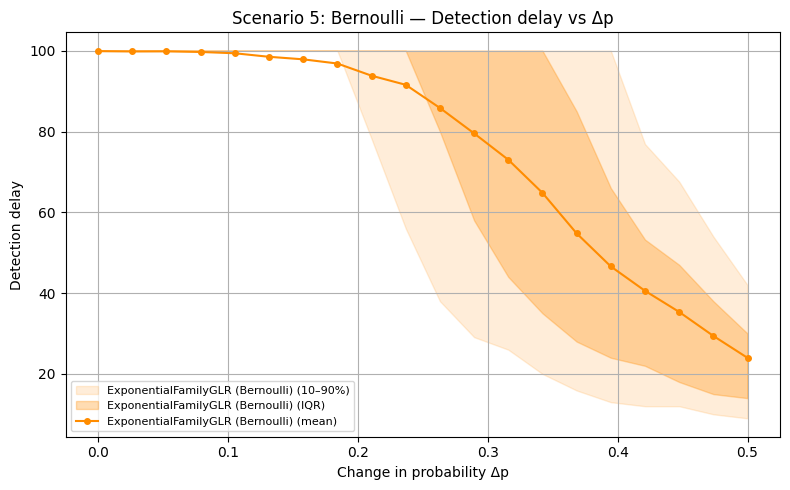

In [27]:
# Scenario 5: Detection delay vs change size (Δp = p_post − p_pre)
# Sweep Δp from 0 to 0.5 (p_post = 0.3 + Δp, capped below 1); EF GLR only
# Uses det5_ef, N5, CP5, P_PRE5 from the cell above.
# =============================================================================

deltas_5 = np.linspace(0.0, 0.5, num=20)

def post_sampler_factory_5(delta_p):
    p_post = P_PRE5 + delta_p
    def sampler(rng=None, _p=p_post):
        return float(np.random.default_rng().binomial(1, _p))
    return sampler

print("Scenario 5: sweeping Δp ...")
sweep5 = sweep_detection_delay(
    [("ExponentialFamilyGLR (Bernoulli)", det5_ef)],
    deltas_5,
    pre_sampler=_bern_pre5,
    post_sampler_factory=post_sampler_factory_5,
    N=N5, CP=CP5, K=K_SIM, rng=SEED,
)

plot_detection_delay(
    deltas_5, sweep5,
    "Scenario 5: Bernoulli — Detection delay vs Δp",
    xlabel="Change in probability Δp",
)

Calibrating ExponentialFamilyGLR (Gaussian mean+variance) ...


  EF threshold: 1.2480


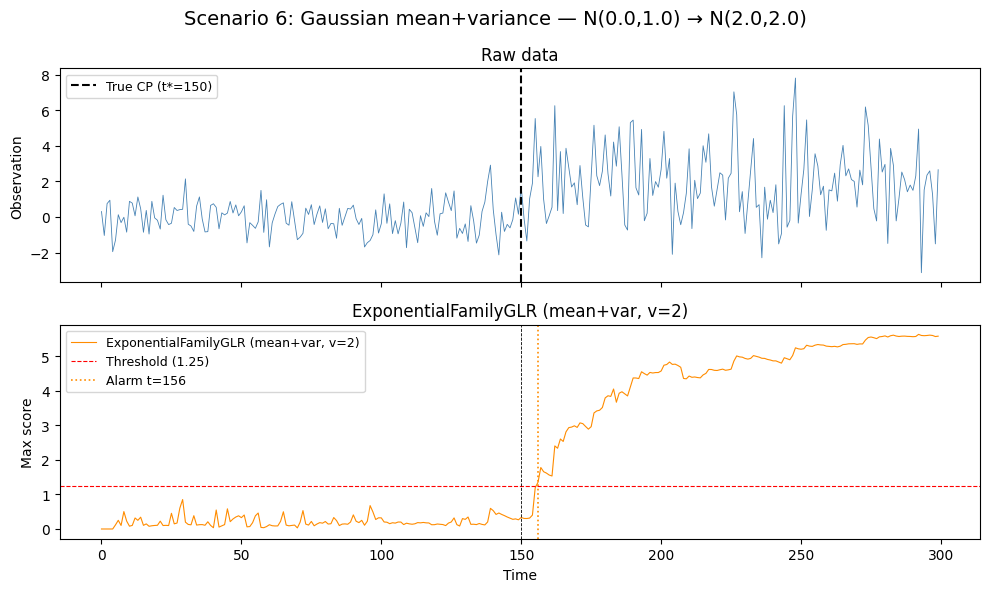

ExponentialFamilyGLR alarm: 156

Running simulation study ...
  ExponentialFamilyGLR: mc_alarm_times (K=1000) ...


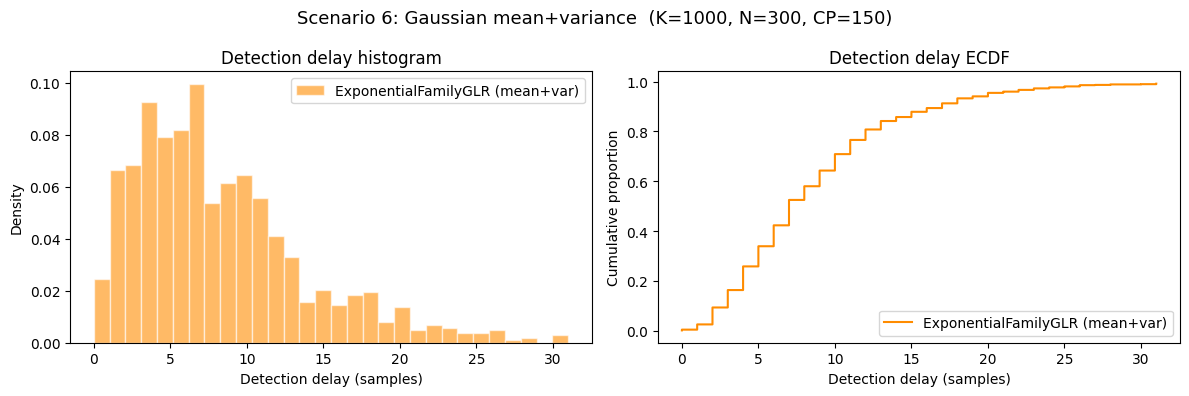

-----------------------------------------------
Metric                    ExponentialFamilyGLR (mean+var)
-----------------------------------------------
Detection rate                           0.992
Miss rate                                0.008
Mean delay                                 8.5
Median delay                               7.0
False alarm (<CP)                        0.008
Null FAR                                 0.016
-----------------------------------------------

Timing ...
ExponentialFamilyGLR: 19.4 ms/stream


In [8]:
# Scenario 6: Univariate Gaussian — joint change in mean AND variance (v=2)
# h(x) = (x, x²),  θ = (θ₀, θ₁) with θ₁ < 0
# A(θ) = -θ₀²/(4θ₁) - ½ log(-2θ₁)
# Pre: N(0,1) → Post: N(2,2)  |  N=300, CP=150
# =============================================================================

N6, CP6 = 300, 150
MU_PRE6, MU_POST6 = 0.0, 2.0
SIGMA_PRE6, SIGMA_POST6 = 1.0, 2.0

@nb.njit
def h6(x):
    out = np.empty(2)
    out[0] = x[0]
    out[1] = x[0] * x[0]
    return out

@nb.njit
def A6(theta):
    # theta = (theta0, theta1), theta1 < 0
    return -theta[0] * theta[0] / (4.0 * theta[1]) - 0.5 * np.log(-2.0 * theta[1])

@nb.njit
def Agrad6(theta):
    g = np.empty(2)
    g[0] = -theta[0] / (2.0 * theta[1])
    g[1] = theta[0] * theta[0] / (4.0 * theta[1] * theta[1]) - 1.0 / (2.0 * theta[1])
    return g

@nb.njit
def Ahess6(theta):
    H = np.zeros((2, 2))
    H[0, 0] = -1.0 / (2.0 * theta[1])
    H[0, 1] = theta[0] / (2.0 * theta[1] * theta[1])
    H[1, 0] = H[0, 1]
    H[1, 1] = (-theta[0] * theta[0] / (2.0 * theta[1]**3)
                + 1.0 / (2.0 * theta[1] * theta[1]))
    return H

# theta_init: for N(0,1) the canonical params are θ₀ = μ/σ² = 0, θ₁ = -1/(2σ²) = -0.5
score6_ef = ExponentialFamilyGLR(
    v=2, n_features=1, h=h6, A=A6,
    A_grad=Agrad6, A_hess=Ahess6,
    theta_init=np.array([0.0, -0.5]),
)

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR (Gaussian mean+variance) ...")
thr6_ef = calibrate_threshold_false_alarm(
    score6_ef, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N6,
    pre_sampler=np.random.default_rng(0).standard_normal,
    parallel=PARALLEL, rng=SEED,
)
print(f"  EF threshold: {thr6_ef:.4f}")

det6_ef = GridDetector(score=score6_ef, threshold=thr6_ef)

# -- Single-stream test --
rng6 = np.random.default_rng(SEED)
data6 = np.concatenate([
    rng6.normal(MU_PRE6,  SIGMA_PRE6,  (CP6,       1)),
    rng6.normal(MU_POST6, SIGMA_POST6, (N6 - CP6, 1)),
])
outs6_ef, stats6_ef = run_and_collect(data6, det6_ef)

plot_scenario(
    f"Scenario 6: Gaussian mean+variance — N({MU_PRE6},{SIGMA_PRE6}) → "
    f"N({MU_POST6},{SIGMA_POST6})",
    data6, stats6_ef, thr6_ef, first_alarm(outs6_ef), CP6,
    ef_label="ExponentialFamilyGLR (mean+var, v=2)",
)
print(f"ExponentialFamilyGLR alarm: {first_alarm(outs6_ef)}")

# -- Simulation study --
print("\nRunning simulation study ...")

def _gauss_post6(rng=None):
    return float(np.random.default_rng().normal(MU_POST6, SIGMA_POST6))

res6 = run_sim_study(
    det6_ef, None,
    pre_sampler=np.random.default_rng(0).standard_normal,
    post_sampler=_gauss_post6,
    n_features=1, N=N6, K=K_SIM, true_cp=CP6, rng=SEED,
)
plot_sim_study(res6, "Scenario 6: Gaussian mean+variance",
               ef_label="ExponentialFamilyGLR (mean+var)")

# -- Timing --
print("\nTiming ...")
t6_ef = time_detector(det6_ef, np.random.default_rng(0).standard_normal,
                       n_features=1, N=N6)
print(f"ExponentialFamilyGLR: {t6_ef*1000:.1f} ms/stream")

Calibrating ExponentialFamilyGLR (MV Gaussian mean) ...
  EF threshold: 0.5858
Calibrating MeanCUSUM(p=3) ...
  MeanCUSUM threshold: 3.7151


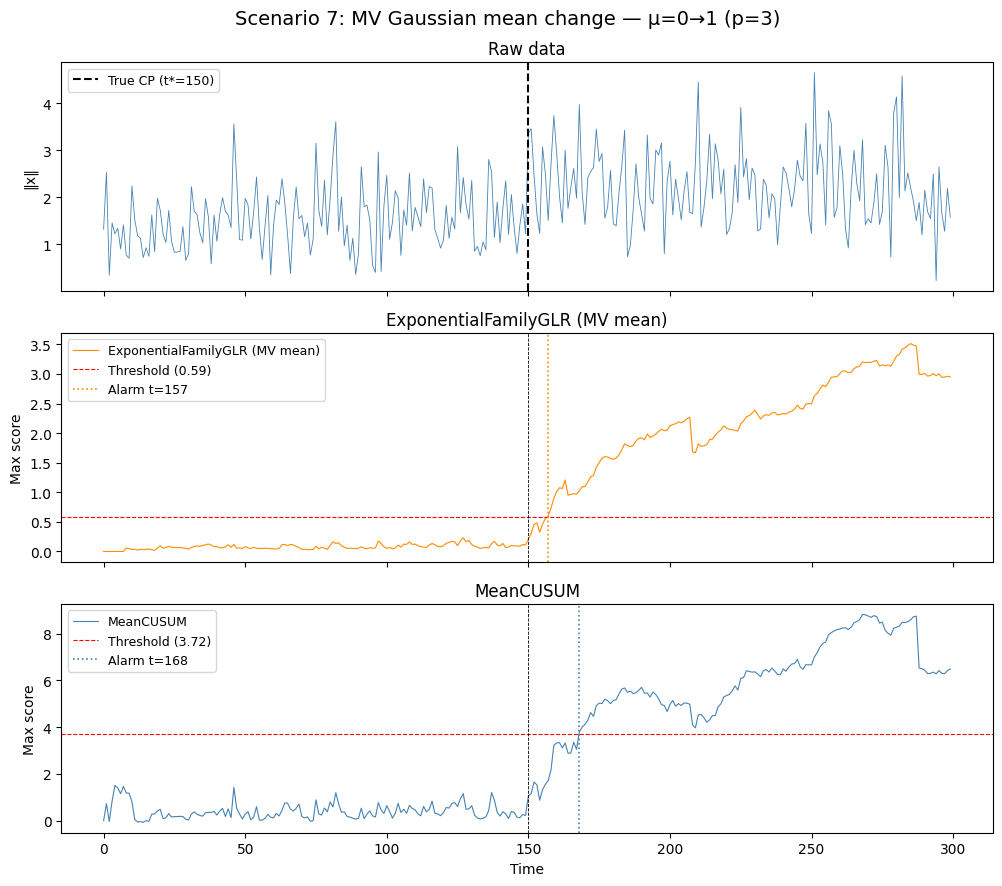

ExponentialFamilyGLR alarm:       157
MeanCUSUM alarm: 168

Running simulation study ...
  ExponentialFamilyGLR: mc_alarm_times (K=1000) ...
  Ref: mc_alarm_times (K=1000) ...


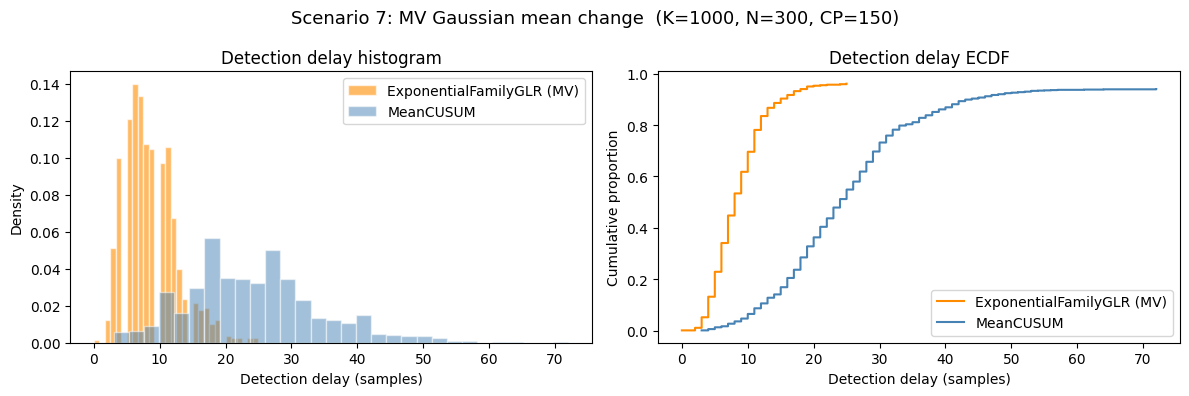

--------------------------------------------------------------------
Metric                    ExponentialFamilyGLR (MV)            MeanCUSUM
--------------------------------------------------------------------
Detection rate                           0.961                0.940
Miss rate                                0.039                0.060
Mean delay                                 8.5                 24.3
Median delay                               8.0                 23.0
False alarm (<CP)                        0.039                0.060
Null FAR                                 0.054                0.074
--------------------------------------------------------------------

Timing ...
ExponentialFamilyGLR:       12.4 ms/stream
MeanCUSUM: 3.6 ms/stream
Ratio:     3.45x


In [9]:
# Scenario 7: Multivariate Gaussian — change in mean (known cov = I, p=3)
# h(x) = x,  A(θ) = ½‖θ‖²,  ∇A = θ,  ∇²A = I
# Pre: N(0,I) → Post: N(1,I)  |  N=300, CP=150  |  Reference: MeanCUSUM(3)
# =============================================================================

P7 = 3
N7, CP7 = 300, 150

@nb.njit
def h7(x):
    return x.copy()

@nb.njit
def A7(theta):
    s = 0.0
    for i in range(theta.shape[0]):
        s += theta[i] * theta[i]
    return 0.5 * s

@nb.njit
def Agrad7(theta):
    return theta.copy()

@nb.njit
def Ahess7(theta):
    return np.eye(theta.shape[0])

score7_ef  = ExponentialFamilyGLR(v=P7, n_features=P7, h=h7, A=A7,
                                     A_grad=Agrad7, A_hess=Ahess7)
score7_ref = MeanCUSUM(n_features=P7)

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR (MV Gaussian mean) ...")

def _mv_pre7(rng=None):
    return np.random.default_rng().standard_normal(P7)

def _mv_post7(rng=None):
    return np.random.default_rng().standard_normal(P7) + 1.0

thr7_ef = calibrate_threshold_false_alarm(
    score7_ef, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N7,
    pre_sampler=_mv_pre7,
    parallel=PARALLEL, rng=SEED,
)
print(f"  EF threshold: {thr7_ef:.4f}")

print("Calibrating MeanCUSUM(p=3) ...")
thr7_ref = calibrate_threshold_false_alarm(
    score7_ref, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N7,
    pre_sampler=_mv_pre7,
    parallel=PARALLEL, rng=SEED,
)
print(f"  MeanCUSUM threshold: {thr7_ref:.4f}")

det7_ef  = GridDetector(score=score7_ef,  threshold=thr7_ef)
det7_ref = GridDetector(score=score7_ref, threshold=thr7_ref)

# -- Single-stream test --
rng7 = np.random.default_rng(SEED)
data7 = np.concatenate([
    rng7.multivariate_normal(np.zeros(P7), np.eye(P7), CP7),
    rng7.multivariate_normal(np.ones(P7),  np.eye(P7), N7 - CP7),
])
outs7_ef,  stats7_ef  = run_and_collect(data7, det7_ef)
outs7_ref, stats7_ref = run_and_collect(data7, det7_ref)

plot_scenario(
    f"Scenario 7: MV Gaussian mean change — μ=0→1 (p={P7})",
    data7, stats7_ef, thr7_ef, first_alarm(outs7_ef), CP7,
    stats_ref=stats7_ref, threshold_ref=thr7_ref, alarm_ref=first_alarm(outs7_ref),
    ef_label="ExponentialFamilyGLR (MV mean)", ref_label="MeanCUSUM",
    data_ylabel="‖x‖",
    data_transform=lambda d: np.linalg.norm(d, axis=1),
)
print(f"ExponentialFamilyGLR alarm:       {first_alarm(outs7_ef)}")
print(f"MeanCUSUM alarm: {first_alarm(outs7_ref)}")

# -- Simulation study --
print("\nRunning simulation study ...")
res7 = run_sim_study(
    det7_ef, det7_ref,
    pre_sampler=_mv_pre7, post_sampler=_mv_post7,
    n_features=P7, N=N7, K=K_SIM, true_cp=CP7, rng=SEED,
)
plot_sim_study(res7, "Scenario 7: MV Gaussian mean change",
               ef_label="ExponentialFamilyGLR (MV)", ref_label="MeanCUSUM")

# -- Timing --
print("\nTiming ...")
t7_ef  = time_detector(det7_ef,  _mv_pre7, n_features=P7, N=N7)
t7_ref = time_detector(det7_ref, _mv_pre7, n_features=P7, N=N7)
print(f"ExponentialFamilyGLR:       {t7_ef*1000:.1f} ms/stream")
print(f"MeanCUSUM: {t7_ref*1000:.1f} ms/stream")
print(f"Ratio:     {t7_ef/t7_ref:.2f}x")

Calibrating ExponentialFamilyGLR (MV Gaussian covariance) ...
  EF threshold: 0.4284


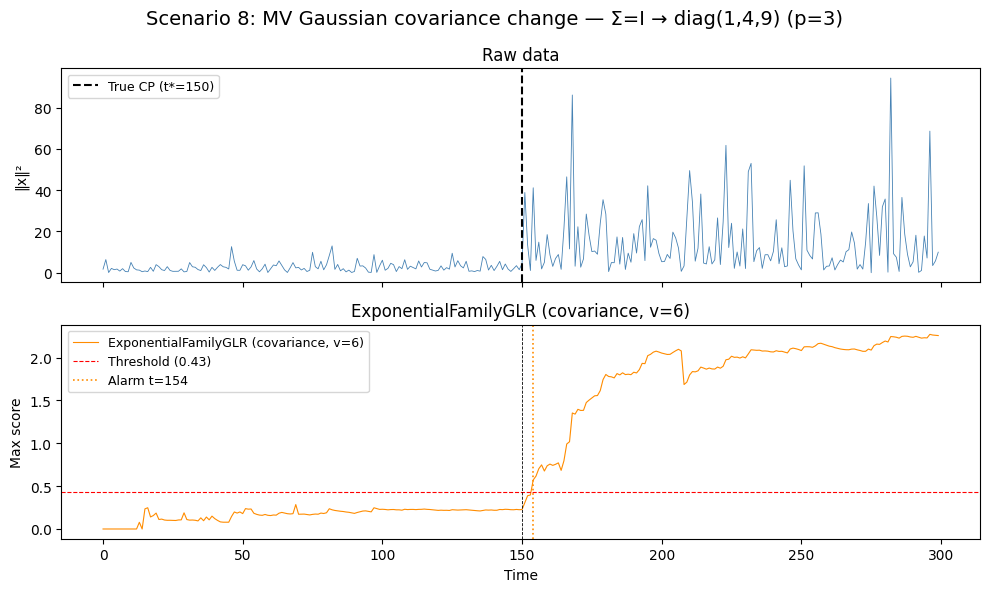

ExponentialFamilyGLR alarm: 154

Running simulation study ...
  ExponentialFamilyGLR: mc_alarm_times (K=1000) ...


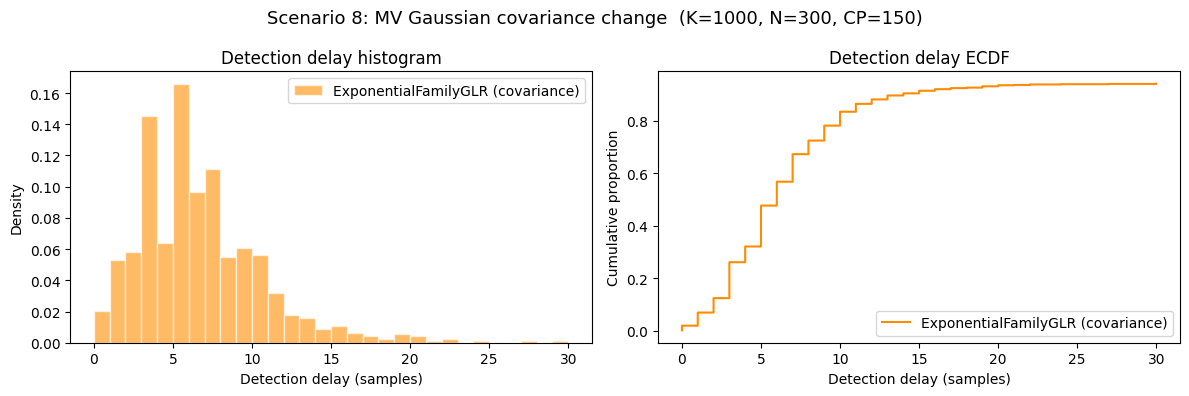

-----------------------------------------------
Metric                    ExponentialFamilyGLR (covariance)
-----------------------------------------------
Detection rate                           0.942
Miss rate                                0.058
Mean delay                                 6.2
Median delay                               5.0
False alarm (<CP)                        0.058
Null FAR                                 0.074
-----------------------------------------------

Timing ...
ExponentialFamilyGLR: 28.1 ms/stream


In [5]:
# Scenario 8: Multivariate Gaussian — change in covariance (known mean = 0, p=3)
# h(x) = vech(x xᵀ),  A(θ) = -½ log det(-2Θ)
# v = p(p+1)/2 = 6,  uses is_cov_case=True path in ExponentialFamilyGLR
# Pre: N(0,I) → Post: N(0, diag(1,4,9))  |  N=300, CP=150
# =============================================================================

P8 = 3
V8 = P8 * (P8 + 1) // 2   # = 6
N8, CP8 = 300, 150
SIGMA_PRE8  = np.eye(P8)
SIGMA_POST8 = np.diag([1.0, 4.0, 9.0])

# -- h: vech(x xᵀ), off-diag doubled so that θᵀh(x) = tr(Θ xxᵀ) --
@nb.njit
def h8(x):
    p = x.shape[0]
    v = p * (p + 1) // 2
    out = np.empty(v)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            if i == j:
                out[idx] = x[i] * x[j]
            else:
                out[idx] = 2.0 * x[i] * x[j]
            idx += 1
    return out

# -- A(θ) = -½ log det(-2Θ) --
@nb.njit
def A8(theta):
    p = _p_from_v(theta.shape[0])
    Theta = _fill_sym(theta, p)
    M = -2.0 * Theta
    sign, ld = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.inf
    return -0.5 * ld

# -- ∇A: ∂A/∂θ_{ii} = (M⁻¹)_{ii},  ∂A/∂θ_{ij} = 2(M⁻¹)_{ij} --
@nb.njit
def Agrad8(theta):
    v = theta.shape[0]
    p = _p_from_v(v)
    Theta = _fill_sym(theta, p)
    M = -2.0 * Theta
    sign, _ = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.full(v, np.nan)
    Mi = np.linalg.inv(M)
    g = np.empty(v)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            if i == j:
                g[idx] = Mi[i, i]
            else:
                g[idx] = 2.0 * Mi[i, j]
            idx += 1
    return g

# -- ∇²A --
@nb.njit
def Ahess8(theta):
    v = theta.shape[0]
    p = _p_from_v(v)
    Theta = _fill_sym(theta, p)
    M = -2.0 * Theta
    sign, _ = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.full((v, v), np.nan)
    Mi = np.linalg.inv(M)
    rows = np.empty(v, dtype=nb.int64)
    cols = np.empty(v, dtype=nb.int64)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            rows[idx] = i; cols[idx] = j
            idx += 1
    H = np.empty((v, v))
    for a in range(v):
        i, j = rows[a], cols[a]
        c_a = 1.0 if i == j else 2.0
        for b in range(v):
            k, l = rows[b], cols[b]
            c_b = 1.0 if k == l else 2.0
            H[a, b] = c_a * c_b * (Mi[i, k] * Mi[j, l] + Mi[i, l] * Mi[j, k])
    return H

# -- theta_init: Θ = -½ Σ⁻¹ for Σ = I → vech of -0.5*I --
_Theta8 = -0.5 * np.linalg.inv(SIGMA_PRE8)
theta_init8 = np.array([
    _Theta8[i, j] for i in range(P8) for j in range(i, P8)
], dtype=np.float64)

score8_ef = ExponentialFamilyGLR(
    v=V8, n_features=P8, h=h8, A=A8,
    A_grad=Agrad8, A_hess=Ahess8,
    theta_init=theta_init8,
    cov_parametrization=True,
)

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR (MV Gaussian covariance) ...")

def _mv_cov_pre8(rng=None):
    return np.random.default_rng().multivariate_normal(np.zeros(P8), SIGMA_PRE8)

def _mv_cov_post8(rng=None):
    return np.random.default_rng().multivariate_normal(np.zeros(P8), SIGMA_POST8)

thr8_ef = calibrate_threshold_false_alarm(
    score8_ef, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N8,
    pre_sampler=_mv_cov_pre8,
    parallel=PARALLEL, rng=SEED,
)
print(f"  EF threshold: {thr8_ef:.4f}")

det8_ef = GridDetector(score=score8_ef, threshold=thr8_ef)

# -- Single-stream test --
rng8 = np.random.default_rng(SEED)
data8 = np.concatenate([
    rng8.multivariate_normal(np.zeros(P8), SIGMA_PRE8,  CP8),
    rng8.multivariate_normal(np.zeros(P8), SIGMA_POST8, N8 - CP8),
])
outs8_ef, stats8_ef = run_and_collect(data8, det8_ef)

plot_scenario(
    f"Scenario 8: MV Gaussian covariance change — Σ=I → diag(1,4,9) (p={P8})",
    data8, stats8_ef, thr8_ef, first_alarm(outs8_ef), CP8,
    ef_label="ExponentialFamilyGLR (covariance, v=6)",
    data_ylabel="‖x‖²",
    data_transform=lambda d: np.sum(d ** 2, axis=1),
)
print(f"ExponentialFamilyGLR alarm: {first_alarm(outs8_ef)}")

# -- Simulation study --
print("\nRunning simulation study ...")
res8 = run_sim_study(
    det8_ef, None,
    pre_sampler=_mv_cov_pre8, post_sampler=_mv_cov_post8,
    n_features=P8, N=N8, K=K_SIM, true_cp=CP8, rng=SEED,
)
plot_sim_study(res8, "Scenario 8: MV Gaussian covariance change",
               ef_label="ExponentialFamilyGLR (covariance)")

# -- Timing --
print("\nTiming ...")
t8_ef = time_detector(det8_ef, _mv_cov_pre8, n_features=P8, N=N8)
print(f"ExponentialFamilyGLR: {t8_ef*1000:.1f} ms/stream")

Calibrating ExponentialFamilyGLR (MV Gaussian mean, p=10) ...
  EF threshold: 0.2604
Calibrating MeanCUSUM(p=10) ...
  MeanCUSUM threshold: 4.8988


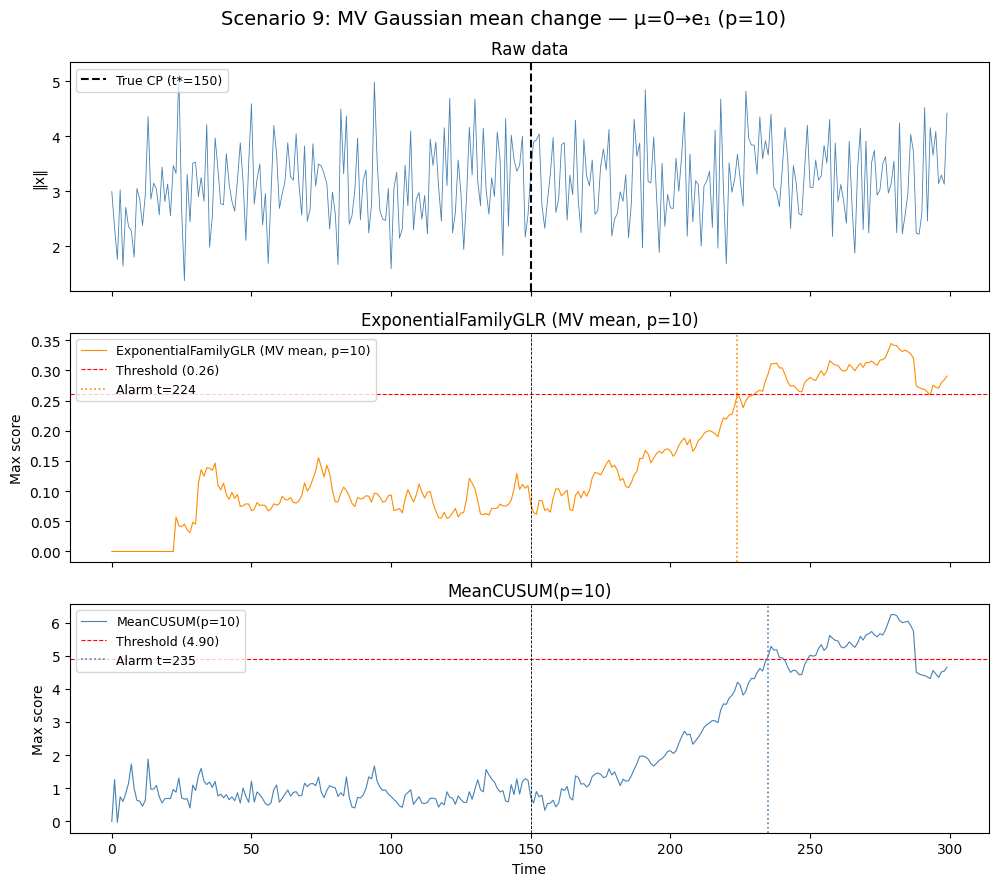

ExponentialFamilyGLR alarm:       224
MeanCUSUM alarm: 235

Running simulation study ...
  ExponentialFamilyGLR: mc_alarm_times (K=1000) ...
  Ref: mc_alarm_times (K=1000) ...


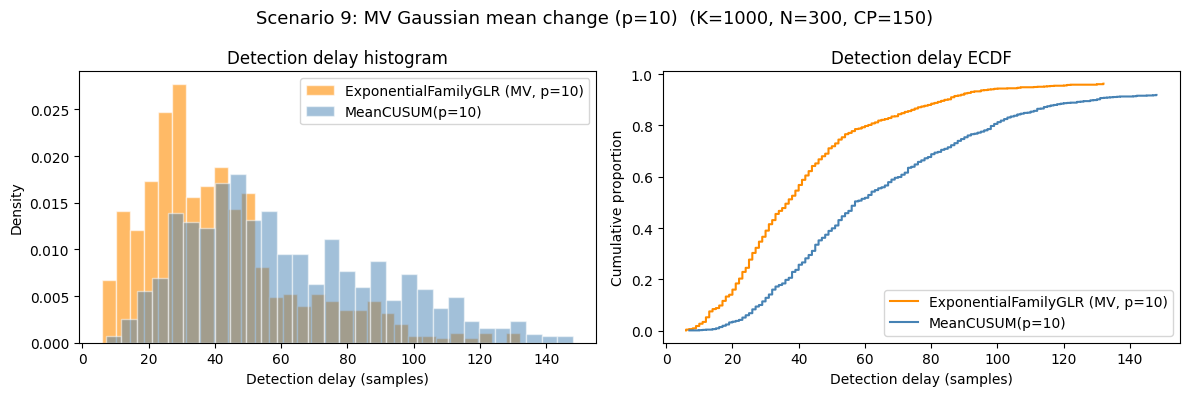

--------------------------------------------------------------------
Metric                    ExponentialFamilyGLR (MV, p=10)      MeanCUSUM(p=10)
--------------------------------------------------------------------
Detection rate                           0.963                0.919
Miss rate                                0.037                0.081
Mean delay                                40.6                 61.2
Median delay                              36.0                 55.0
False alarm (<CP)                        0.035                0.042
Null FAR                                 0.036                0.046
--------------------------------------------------------------------

Timing ...
ExponentialFamilyGLR:       26.9 ms/stream
MeanCUSUM: 3.5 ms/stream
Ratio:     7.61x


In [4]:
# Scenario 9: Multivariate Gaussian — change in mean (known cov = I, p=10)
# h(x) = x,  A(θ) = ½‖θ‖²,  ∇A = θ,  ∇²A = I
# Pre: N(0,I) → Post: N(μ₁,I), μ₁=(1,0,…,0)  |  N=300, CP=150
# Reference: MeanCUSUM(10)
# =============================================================================

P9 = 10
N9, CP9 = 300, 150
MU_POST9 = np.zeros(P9); MU_POST9[0] = 1.0   # shift first coordinate only

@nb.njit
def h9(x):
    return x.copy()

@nb.njit
def A9(theta):
    s = 0.0
    for i in range(theta.shape[0]):
        s += theta[i] * theta[i]
    return 0.5 * s

@nb.njit
def Agrad9(theta):
    return theta.copy()

@nb.njit
def Ahess9(theta):
    return np.eye(theta.shape[0])

score9_ef  = ExponentialFamilyGLR(v=P9, n_features=P9, h=h9, A=A9,
                                     A_grad=Agrad9, A_hess=Ahess9)
score9_ref = MeanCUSUM(n_features=P9)

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR (MV Gaussian mean, p=10) ...")

def _mv_pre9(rng=None):
    return np.random.default_rng().standard_normal(P9)

def _mv_post9(rng=None):
    return np.random.default_rng().standard_normal(P9) + MU_POST9

thr9_ef = calibrate_threshold_false_alarm(
    score9_ef, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N9,
    pre_sampler=_mv_pre9,
    parallel=PARALLEL, rng=SEED,
)
print(f"  EF threshold: {thr9_ef:.4f}")

print("Calibrating MeanCUSUM(p=10) ...")
thr9_ref = calibrate_threshold_false_alarm(
    score9_ref, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N9,
    pre_sampler=_mv_pre9,
    parallel=PARALLEL, rng=SEED,
)
print(f"  MeanCUSUM threshold: {thr9_ref:.4f}")

det9_ef  = GridDetector(score=score9_ef,  threshold=thr9_ef)
det9_ref = GridDetector(score=score9_ref, threshold=thr9_ref)

# -- Single-stream test --
rng9 = np.random.default_rng(SEED)
data9 = np.concatenate([
    rng9.multivariate_normal(np.zeros(P9), np.eye(P9), CP9),
    rng9.multivariate_normal(MU_POST9,     np.eye(P9), N9 - CP9),
])
outs9_ef,  stats9_ef  = run_and_collect(data9, det9_ef)
outs9_ref, stats9_ref = run_and_collect(data9, det9_ref)

plot_scenario(
    f"Scenario 9: MV Gaussian mean change — μ=0→e₁ (p={P9})",
    data9, stats9_ef, thr9_ef, first_alarm(outs9_ef), CP9,
    stats_ref=stats9_ref, threshold_ref=thr9_ref, alarm_ref=first_alarm(outs9_ref),
    ef_label="ExponentialFamilyGLR (MV mean, p=10)", ref_label="MeanCUSUM(p=10)",
    data_ylabel="‖x‖",
    data_transform=lambda d: np.linalg.norm(d, axis=1),
)
print(f"ExponentialFamilyGLR alarm:       {first_alarm(outs9_ef)}")
print(f"MeanCUSUM alarm: {first_alarm(outs9_ref)}")

# -- Simulation study --
print("\nRunning simulation study ...")
res9 = run_sim_study(
    det9_ef, det9_ref,
    pre_sampler=_mv_pre9, post_sampler=_mv_post9,
    n_features=P9, N=N9, K=K_SIM, true_cp=CP9, rng=SEED,
)
plot_sim_study(res9, "Scenario 9: MV Gaussian mean change (p=10)",
               ef_label="ExponentialFamilyGLR (MV, p=10)", ref_label="MeanCUSUM(p=10)")

# -- Timing --
print("\nTiming ...")
t9_ef  = time_detector(det9_ef,  _mv_pre9, n_features=P9, N=N9)
t9_ref = time_detector(det9_ref, _mv_pre9, n_features=P9, N=N9)
print(f"ExponentialFamilyGLR:       {t9_ef*1000:.1f} ms/stream")
print(f"MeanCUSUM: {t9_ref*1000:.1f} ms/stream")
print(f"Ratio:     {t9_ef/t9_ref:.2f}x")

Calibrating ExponentialFamilyGLR (MV Gaussian covariance, p=5) ...


  EF threshold: 0.2339


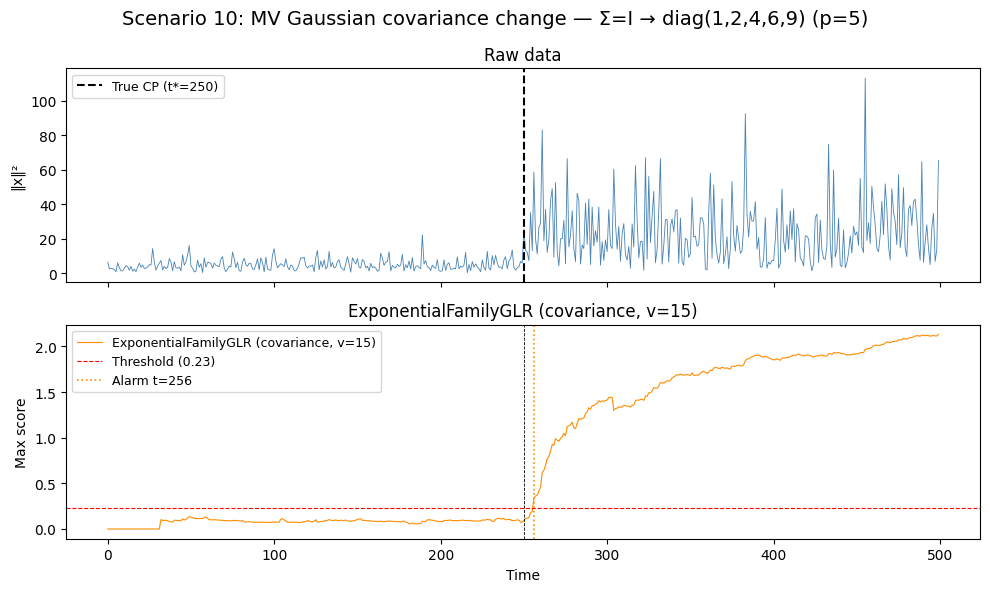

ExponentialFamilyGLR alarm: 256

Running simulation study ...
  ExponentialFamilyGLR: mc_alarm_times (K=1000) ...


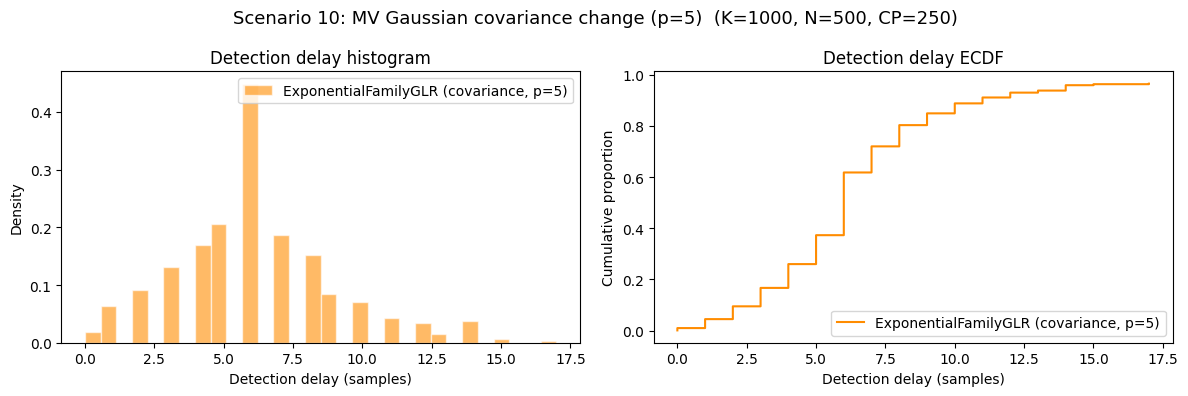

-----------------------------------------------
Metric                    ExponentialFamilyGLR (covariance, p=5)
-----------------------------------------------
Detection rate                           0.965
Miss rate                                0.035
Mean delay                                 6.1
Median delay                               6.0
False alarm (<CP)                        0.035
Null FAR                                 0.045
-----------------------------------------------

Timing ...
ExponentialFamilyGLR: 50.4 ms/stream


In [6]:
# Scenario 10: Multivariate Gaussian — change in covariance (known mean = 0, p=5)
# h(x) = vech(x xᵀ),  A(θ) = -½ log det(-2Θ)
# v = p(p+1)/2 = 15,  cov_parametrization=True
# Pre: N(0,I) → Post: N(0, diag(1,2,4,6,9))  |  N=500, CP=250
# =============================================================================

P10 = 5
V10 = P10 * (P10 + 1) // 2   # = 15
N10, CP10 = 500, 250
SIGMA_PRE10  = np.eye(P10)
SIGMA_POST10 = np.diag([1.0, 2.0, 4.0, 6.0, 9.0])

# -- h, A, Agrad, Ahess reuse the generic covariance functions from Scenario 8 --
# They are written generically via _p_from_v and _fill_sym, so they work for any p.

score10_ef = ExponentialFamilyGLR(
    v=V10, n_features=P10, h=h8, A=A8,
    A_grad=Agrad8, A_hess=Ahess8,
    theta_init=np.array([
        (-0.5 * np.linalg.inv(SIGMA_PRE10))[i, j]
        for i in range(P10) for j in range(i, P10)
    ], dtype=np.float64),
    cov_parametrization=True,
)

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR (MV Gaussian covariance, p=5) ...")

def _mv_cov_pre10(rng=None):
    return np.random.default_rng().multivariate_normal(np.zeros(P10), SIGMA_PRE10)

def _mv_cov_post10(rng=None):
    return np.random.default_rng().multivariate_normal(np.zeros(P10), SIGMA_POST10)

thr10_ef = calibrate_threshold_false_alarm(
    score10_ef, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N10,
    pre_sampler=_mv_cov_pre10,
    parallel=PARALLEL, rng=SEED,
)
print(f"  EF threshold: {thr10_ef:.4f}")

det10_ef = GridDetector(score=score10_ef, threshold=thr10_ef)

# -- Single-stream test --
rng10 = np.random.default_rng(SEED)
data10 = np.concatenate([
    rng10.multivariate_normal(np.zeros(P10), SIGMA_PRE10,  CP10),
    rng10.multivariate_normal(np.zeros(P10), SIGMA_POST10, N10 - CP10),
])
outs10_ef, stats10_ef = run_and_collect(data10, det10_ef)

plot_scenario(
    f"Scenario 10: MV Gaussian covariance change — Σ=I → diag(1,2,4,6,9) (p={P10})",
    data10, stats10_ef, thr10_ef, first_alarm(outs10_ef), CP10,
    ef_label="ExponentialFamilyGLR (covariance, v=15)",
    data_ylabel="‖x‖²",
    data_transform=lambda d: np.sum(d ** 2, axis=1),
)
print(f"ExponentialFamilyGLR alarm: {first_alarm(outs10_ef)}")

# -- Simulation study --
print("\nRunning simulation study ...")
res10 = run_sim_study(
    det10_ef, None,
    pre_sampler=_mv_cov_pre10, post_sampler=_mv_cov_post10,
    n_features=P10, N=N10, K=K_SIM, true_cp=CP10, rng=SEED,
)
plot_sim_study(res10, "Scenario 10: MV Gaussian covariance change (p=5)",
               ef_label="ExponentialFamilyGLR (covariance, p=5)")

# -- Timing --
print("\nTiming ...")
t10_ef = time_detector(det10_ef, _mv_cov_pre10, n_features=P10, N=N10)
print(f"ExponentialFamilyGLR: {t10_ef*1000:.1f} ms/stream")

## Built-in families

In [2]:
"""Sandbox: EF GLR families vs built-in reference detectors.

Run ONE scenario at a time by uncommenting the desired line at the bottom.

For each scenario the script:
  1. Calibrates the threshold (Monte Carlo, alpha=0.05, 2000 null paths)
  2. Simulates K_SIM=100 detection streams
  3. Prints a metrics table

Metrics
-------
Threshold  calibrated detection threshold
ADD        average detection delay (mean alarm - CP, streams that detect)
Median     median detection delay
Miss%      fraction of streams with no alarm before end (1 - power)
FA%        fraction of streams that alarm before the true changepoint
p5-p95     5th and 95th percentile of detection delays
ms/str     mean wall-clock time per stream (ms)
ms/obs     mean wall-clock time per observation (ms)
"""

import time

import numpy as np

from gridcp import GridDetector
from gridcp.calibration import calibrate_threshold_false_alarm
from gridcp.scores import (
    ExponentialFamilyGLR,
    MeanCUSUM,
    MeanOrVariance,
    MultivariateMeanIdentityCov,
    MultivariateMeanOrCovariance,
    Variance,
)

# ---------------------------------------------------------------------------
# Global settings  (edit freely)
# ---------------------------------------------------------------------------

N = 300        # total stream length
CP = 150       # true changepoint index (0-based)
ALPHA = 0.05   # target false alarm probability
N_CAL = 2000   # Monte Carlo paths for calibration
K_SIM = 1000    # simulation paths
SEED = 42      # master RNG seed

# ---------------------------------------------------------------------------
# Engine
# ---------------------------------------------------------------------------


def _simulate(detector, gen_stream, K, seed):
    """Run K streams; return (alarm_times, ms_per_stream)."""
    rng = np.random.default_rng(seed)
    child_seeds = rng.integers(0, 2**31, size=K)
    alarm_times, runtimes = [], []
    for s in child_seeds:
        data = gen_stream(np.random.default_rng(int(s)))
        state = detector.init_state()
        t0 = time.perf_counter()
        alarm = None
        for i, x in enumerate(data):
            state, out = detector.update(state, x)
            if alarm is None and out["alarm"]:
                alarm = i
        runtimes.append((time.perf_counter() - t0) * 1000)
        alarm_times.append(alarm)
    return alarm_times, runtimes


def _fmt_row(label, thr, alarm_times, runtimes, cp, n):
    n_streams = len(alarm_times)
    delays = [a - cp for a in alarm_times if a is not None and a >= cp]
    miss_pct = 100.0 * sum(1 for a in alarm_times if a is None) / n_streams
    fa_pct = 100.0 * sum(1 for a in alarm_times if a is not None and a < cp) / n_streams
    thr_str = f"{float(np.max(thr)):.3f}"
    if delays:
        add = f"{np.mean(delays):.1f}"
        med = f"{np.median(delays):.1f}"
        p5 = int(np.percentile(delays, 5))
        p95 = int(np.percentile(delays, 95))
        rng_str = f"{p5}–{p95}"
    else:
        add = med = rng_str = "—"
    ms_str = f"{np.mean(runtimes):.1f}"
    ms_obs = f"{np.mean(runtimes) / n:.3f}"
    return [label, thr_str, add, med, f"{miss_pct:.1f}%", f"{fa_pct:.1f}%", rng_str, ms_str, ms_obs]


def run_scenario(name, arms, N=N, CP=CP):
    """Calibrate, simulate, and print metrics for one scenario.

    Parameters
    ----------
    name : str
        Display name for the scenario.
    arms : list of dict
        Each dict has keys: ``label``, ``score``, ``pre_sampler``, ``gen_stream``.
        ``pre_sampler()`` returns one null observation (for calibration).
        ``gen_stream(rng)`` returns a full ``(N, n_features)`` data array.
    """
    print(f"\n{'═' * 72}")
    print(f"  {name}")
    print(f"  N={N}  CP={CP}  α={ALPHA}  K_cal={N_CAL}  K_sim={K_SIM}  seed={SEED}")
    print(f"{'═' * 72}")

    rows = []
    for arm in arms:
        label = arm["label"]
        score = arm["score"]
        print(f"  Calibrating {label} ...", end=" ", flush=True)
        thr = calibrate_threshold_false_alarm(
            score,
            false_alarm_probability=ALPHA,
            n_paths=N_CAL,
            stream_len=N,
            pre_sampler=arm["pre_sampler"],
            rng=SEED,
            parallel=True,
        )
        print(f"→ {float(np.max(thr)):.4f}")
        detector = GridDetector(score=score, threshold=thr)
        alarms, runtimes = _simulate(detector, arm["gen_stream"], K_SIM, SEED)
        rows.append(_fmt_row(label, thr, alarms, runtimes, CP, N))

    # Print table
    col_w = [32, 10, 7, 7, 7, 7, 8, 9, 9]
    headers = ["Detector", "Threshold", "ADD", "Median", "Miss%", "FA%", "p5–p95", "ms/str", "ms/obs"]
    sep = "  " + "  ".join("─" * w for w in col_w)
    fmt = "  " + "  ".join(f"{{:<{w}}}" for w in col_w)
    print()
    print(fmt.format(*headers))
    print(sep)
    for r in rows:
        print(fmt.format(*r))


# ---------------------------------------------------------------------------
# Scenario definitions
# ---------------------------------------------------------------------------

# ── Scenario 1: gaussian_mean vs MeanCUSUM ─────────────────────────────────
#   Pre: N(0, 1)  →  Post: N(3, 1)

def _s1_gen(rng):
    return np.vstack([rng.normal(0.0, 1.0, (CP, 1)),
                      rng.normal(3.0, 1.0, (N - CP, 1))])

SCENARIO_1 = dict(
    name="Scenario 1: gaussian_mean vs MeanCUSUM  [N(0,1)→N(3,1)]",
    arms=[
        dict(label="EF GLR (gaussian_mean)",
             score=ExponentialFamilyGLR.from_family("gaussian_mean"),
             pre_sampler=lambda rng=None: rng.standard_normal(1),
             gen_stream=_s1_gen),
        dict(label="MeanCUSUM",
             score=MeanCUSUM(n_features=1),
             pre_sampler=lambda rng=None: rng.standard_normal(1),
             gen_stream=_s1_gen),
    ],
)

# ── Scenario 2: gaussian_variance vs Variance ──────────────────────────────
#   Pre: N(0, 1)  →  Post: N(0, 2)  [σ: 1→2]

def _s2_gen(rng):
    return np.vstack([rng.normal(0.0, 1.0, (CP, 1)),
                      rng.normal(0.0, 2.0, (N - CP, 1))])

SCENARIO_2 = dict(
    name="Scenario 2: gaussian_variance vs Variance  [N(0,1)→N(0,2)]",
    arms=[
        dict(label="EF GLR (gaussian_variance)",
             score=ExponentialFamilyGLR.from_family("gaussian_variance"),
             pre_sampler=lambda: np.random.default_rng().standard_normal(1),
             gen_stream=_s2_gen),
        dict(label="Variance",
             score=Variance(n_features=1),
             pre_sampler=lambda: np.random.default_rng().standard_normal(1),
             gen_stream=_s2_gen),
    ],
)

# ── Scenario 3: gaussian_mean_variance vs MeanOrVariance ───────────────────
#   Pre: N(0, 1)  →  Post: N(2, 2)  [joint shift]

def _s3_gen(rng):
    return np.vstack([rng.normal(0.0, 1.0, (CP, 1)),
                      rng.normal(2.0, 2.0, (N - CP, 1))])

SCENARIO_3 = dict(
    name="Scenario 3: gaussian_mean_variance vs MeanOrVariance  [N(0,1)→N(2,2)]",
    arms=[
        dict(label="EF GLR (gaussian_mean_variance)",
             score=ExponentialFamilyGLR.from_family("gaussian_mean_variance"),
             pre_sampler=lambda: np.random.default_rng().standard_normal(1),
             gen_stream=_s3_gen),
        dict(label="MeanOrVariance",
             score=MeanOrVariance(n_features=1),
             pre_sampler=lambda: np.random.default_rng().standard_normal(1),
             gen_stream=_s3_gen),
    ],
)

# ── Scenario 4: gaussian_mean (p=3) vs MultivariateMeanIdentityCov ─────────
#   Pre: N(0, I₃)  →  Post: N(1·1, I₃)

_P4 = 3

def _s4_gen(rng):
    return np.vstack([rng.multivariate_normal(np.zeros(_P4), np.eye(_P4), CP),
                      rng.multivariate_normal(np.ones(_P4),  np.eye(_P4), N - CP)])

SCENARIO_4 = dict(
    name=f"Scenario 4: gaussian_mean (p={_P4}) vs MultivariateMeanIdentityCov  [μ=0→1]",
    arms=[
        dict(label=f"EF GLR (gaussian_mean, p={_P4})",
             score=ExponentialFamilyGLR.from_family("gaussian_mean", n_features=_P4),
             pre_sampler=lambda: np.random.default_rng().standard_normal(_P4),
             gen_stream=_s4_gen),
        dict(label="MultivariateMeanIdentityCov",
             score=MultivariateMeanIdentityCov(n_features=_P4),
             pre_sampler=lambda: np.random.default_rng().standard_normal(_P4),
             gen_stream=_s4_gen),
    ],
)

# ── Scenario 5: gaussian_covariance vs MultivariateMeanOrCovariance ────────
#   Pre: N(0, I₃)  →  Post: N(0, diag(1, 4, 9))

_P5 = 3
_SIGMA_POST5 = np.diag([1.0, 4.0, 9.0])

def _s5_gen(rng):
    return np.vstack([rng.multivariate_normal(np.zeros(_P5), np.eye(_P5),    CP),
                      rng.multivariate_normal(np.zeros(_P5), _SIGMA_POST5, N - CP)])

SCENARIO_5 = dict(
    name=f"Scenario 5: gaussian_covariance (p={_P5}) vs MultivariateMeanOrCovariance  [Σ=I→diag(1,4,9)]",
    arms=[
        dict(label=f"EF GLR (gaussian_covariance, p={_P5})",
             score=ExponentialFamilyGLR.from_family("gaussian_covariance", n_features=_P5),
             pre_sampler=lambda: np.random.default_rng().standard_normal(_P5),
             gen_stream=_s5_gen),
        dict(label="MultivariateMeanOrCovariance",
             score=MultivariateMeanOrCovariance(n_features=_P5),
             pre_sampler=lambda: np.random.default_rng().standard_normal(_P5),
             gen_stream=_s5_gen),
    ],
)

# ── Scenario 6: poisson (standalone) ───────────────────────────────────────
#   Pre: Poisson(2)  →  Post: Poisson(8)

def _s6_gen(rng):
    return np.vstack([rng.poisson(2.0, (CP,      1)).astype(float),
                      rng.poisson(8.0, (N - CP,  1)).astype(float)])

SCENARIO_6 = dict(
    name="Scenario 6: poisson (standalone)  [λ=2→8]",
    arms=[
        dict(label="EF GLR (poisson)",
             score=ExponentialFamilyGLR.from_family("poisson"),
             pre_sampler=lambda: np.array([float(np.random.default_rng().poisson(2.0))]),
             gen_stream=_s6_gen),
    ],
)

# ── Scenario 7: bernoulli (standalone) ─────────────────────────────────────
#   Pre: Bernoulli(0.2)  →  Post: Bernoulli(0.7)

def _s7_gen(rng):
    return np.vstack([rng.binomial(1, 0.2, (CP,      1)).astype(float),
                      rng.binomial(1, 0.7, (N - CP,  1)).astype(float)])

SCENARIO_7 = dict(
    name="Scenario 7: bernoulli (standalone)  [p=0.2→0.7]",
    arms=[
        dict(label="EF GLR (bernoulli)",
             score=ExponentialFamilyGLR.from_family("bernoulli"),
             pre_sampler=lambda: np.array([float(np.random.default_rng().binomial(1, 0.2))]),
             gen_stream=_s7_gen),
    ],
)

# ── Scenario 8: exponential (standalone) ───────────────────────────────────
#   Pre: Exp(rate=1, mean=1)  →  Post: Exp(rate=3, mean=1/3)

def _s8_gen(rng):
    return np.vstack([rng.exponential(1.0,     (CP,      1)),
                      rng.exponential(1.0 / 3, (N - CP,  1))])

SCENARIO_8 = dict(
    name="Scenario 8: exponential (standalone)  [rate=1→3]",
    arms=[
        dict(label="EF GLR (exponential)",
             score=ExponentialFamilyGLR.from_family("exponential"),
             pre_sampler=lambda: np.array([np.random.default_rng().exponential(1.0)]),
             gen_stream=_s8_gen),
    ],
)

In [3]:
# ---------------------------------------------------------------------------
# ── Run one scenario at a time — uncomment the one you want ─────────────────
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    run_scenario(**SCENARIO_1)
    #run_scenario(**SCENARIO_2)
    #run_scenario(**SCENARIO_3)
    #run_scenario(**SCENARIO_4)
    #run_scenario(**SCENARIO_5)
    #run_scenario(**SCENARIO_6)
    #run_scenario(**SCENARIO_7)
    #run_scenario(**SCENARIO_8)
    #run_scenario(**SCENARIO_9)



════════════════════════════════════════════════════════════════════════
  Scenario 1: gaussian_mean vs MeanCUSUM  [N(0,1)→N(3,1)]
  N=300  CP=150  α=0.05  K_cal=2000  K_sim=1000  seed=42
════════════════════════════════════════════════════════════════════════
  Calibrating EF GLR (gaussian_mean) ... → 3.0651
  Calibrating MeanCUSUM ... → 3.0651

  Detector                          Threshold   ADD      Median   Miss%    FA%      p5–p95    ms/str     ms/obs   
  ────────────────────────────────  ──────────  ───────  ───────  ───────  ───────  ────────  ─────────  ─────────
  EF GLR (gaussian_mean)            3.065       2.3      2.0      0.0%     4.7%     1–5       7.7        0.026    
  MeanCUSUM                         3.065       2.3      2.0      0.0%     4.7%     1–5       5.8        0.019    


# ARL Calibration

Tests of `calibrate_threshold_arl` and `calibrate_detector_threshold_arl`
from `old_notebooks/arl_calibration.py`.

The built-in `MeanCUSUM` is used with `penalty=PenaltyType.CONSTANT` so
that the test statistic is stationary under H₀, which is required for
ARL calibration to be valid.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

# Add old_notebooks to path so we can import the module
if '.' not in sys.path:
    sys.path.insert(0, '.')

from arl_calibration import calibrate_threshold_arl, calibrate_detector_threshold_arl
from gridcp.typing import PenaltyType
from gridcp.scores import MeanCUSUM
from gridcp.detector import GridDetector
from gridcp.calibration import calibrate_threshold_false_alarm, mc_alarm_times

print('Imports OK.')

Imports OK.


## Checking that it works:

1) Exponential assumption holds (QQ-plots - single test and multiple tests)
2) Empirical mean ARL is centered around the target ARL - and test how many MC calibrations are needed
3) Empirical mean ARL does not decrease as the number of tests increases (multiple test correction)

### 1. Exponential assumption tests

Calibrating ARL threshold (γ=2000, B=5000) ...
  ARL threshold (1/e-quantile): 13.6991

  Fraction alarmed (before 20000): 1.000
  Mean alarm time:    2001.8  (target γ = 2000)
  Median alarm time:  1397.0
  m(N) = median/log2: 2015.4


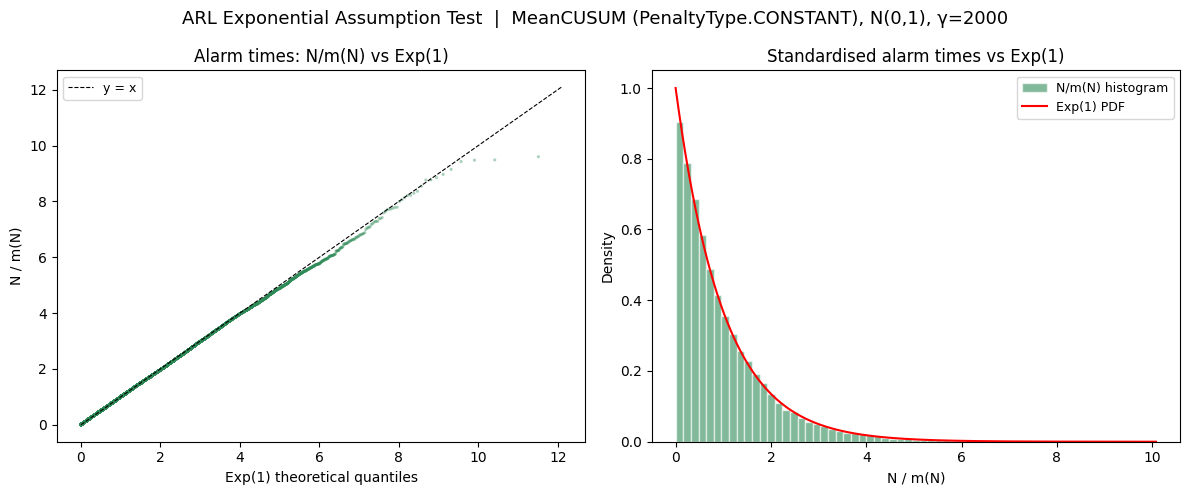


Summary
  Score:                MeanCUSUM (PenaltyType.CONSTANT)
  Null distribution:    N(0, 1)
  Target ARL (γ):       2000
  ARL threshold:        13.6991
  Mean alarm time:      2001.8
  m(N) = median/log2:   2015.4
  Ratio mean AT / γ:    1.001


In [2]:
# Exponential Assumption Test
# =============================================================================
# ARL calibration assumes that alarm times under H₀ are approximately
# exponentially distributed.  This holds when the test statistic is
# stationary under H₀ — which requires a *constant* penalty.
#
# Here we use MeanCUSUM(penalty=PenaltyType.CONSTANT) instead of the
# custom MeanCUSUMConstPenalty class used earlier in this notebook.
# The penalty=CONSTANT flag makes _get_penalty() return 1.0 at every step.
#
# Standardisation follows the OCD paper:
#   m(N) = median(alarm times) / log(2)
# If alarm times ~ Exp(1/γ), then median = γ * log(2), so
# N / m(N) ~ Exp(1).
# =============================================================================

GAMMA_EXP   = 2000   # target ARL
B_MAX       = 5000   # MC paths for calibration
B_ALARM     = 50000  # MC paths for assumption verification
SEED_EXP    = 42
PARALLEL    = True

score_const = MeanCUSUM(n_features=1, penalty=PenaltyType.CONSTANT)

print(f'Calibrating ARL threshold (γ={GAMMA_EXP}, B={B_MAX}) ...')
arl_thr = calibrate_threshold_arl(
    score_const,
    target_arl=GAMMA_EXP,
    n_paths=B_MAX,
    pre_sampler=lambda rng=None: rng.standard_normal(),
    rng=SEED_EXP,
    parallel=PARALLEL,
)
print(f'  ARL threshold (1/e-quantile): {arl_thr:.4f}')

# --- Collect alarm times for verification ---
det_arl_exp = GridDetector(score=MeanCUSUM(n_features=1, penalty=PenaltyType.CONSTANT),
                           threshold=arl_thr)
stream_len_verify = 10 * GAMMA_EXP
print(f'\nCollecting {B_ALARM} alarm times (stream_len={stream_len_verify}) ...')
alarm_times_exp = mc_alarm_times(
    det_arl_exp,
    n_paths=B_ALARM,
    stream_len=stream_len_verify,
    pre_sampler=lambda rng=None: rng.standard_normal(),
    rng=SEED_EXP + 1,
    parallel=PARALLEL,
)

alarmed_exp  = alarm_times_exp[alarm_times_exp < stream_len_verify].astype(float)
frac_alarmed = len(alarmed_exp) / B_ALARM
mean_at      = np.mean(alarmed_exp) if len(alarmed_exp) > 0 else float('nan')
median_at    = np.median(alarmed_exp) if len(alarmed_exp) > 0 else float('nan')
m_at         = median_at / np.log(2)  # OCD paper scale estimate

print(f'  Fraction alarmed (before {stream_len_verify}): {frac_alarmed:.3f}')
print(f'  Mean alarm time:    {mean_at:.1f}  (target γ = {GAMMA_EXP})')
print(f'  Median alarm time:  {median_at:.1f}')
print(f'  m(N) = median/log2: {m_at:.1f}')

# --- Two-panel figure: QQ-plot + histogram ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    f'ARL Exponential Assumption Test  |  '
    f'MeanCUSUM (PenaltyType.CONSTANT), N(0,1), γ={GAMMA_EXP}',
    fontsize=13,
)

# Panel 1: QQ-plot of N/m(N) vs Exp(1)
ax = axes[0]
std_at = alarmed_exp / m_at
n_at = len(std_at)
theoretical_q = sp_stats.expon.ppf((np.arange(1, n_at + 1) - 0.5) / n_at)
ax.scatter(theoretical_q, np.sort(std_at), s=5, alpha=0.4,
           color='seagreen', edgecolors='none')
hi = max(theoretical_q.max(), std_at.max()) * 1.05
ax.plot([0, hi], [0, hi], 'k--', lw=0.8, label='y = x')
ax.set_xlabel('Exp(1) theoretical quantiles')
ax.set_ylabel('N / m(N)')
ax.set_title('Alarm times: N/m(N) vs Exp(1)')
ax.legend(fontsize=9)

# Panel 2: Histogram vs Exp(1) PDF
ax = axes[1]
ax.hist(std_at, bins=60, density=True, alpha=0.6,
        color='seagreen', edgecolor='white', label='N/m(N) histogram')
xs = np.linspace(0, std_at.max() * 1.05, 300)
ax.plot(xs, sp_stats.expon.pdf(xs), 'r-', lw=1.5, label='Exp(1) PDF')
ax.set_xlabel('N / m(N)')
ax.set_ylabel('Density')
ax.set_title('Standardised alarm times vs Exp(1)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('\n' + '=' * 55)
print('Summary')
print('=' * 55)
print(f'  Score:                MeanCUSUM (PenaltyType.CONSTANT)')
print(f'  Null distribution:    N(0, 1)')
print(f'  Target ARL (γ):       {GAMMA_EXP}')
print(f'  ARL threshold:        {arl_thr:.4f}')
print(f'  Mean alarm time:      {mean_at:.1f}')
print(f'  m(N) = median/log2:   {m_at:.1f}')
print(f'  Ratio mean AT / γ:    {mean_at / GAMMA_EXP:.3f}')
print('=' * 55)

In [19]:
# Combined ARL threshold — 3-test scenario with different score magnitudes
# =============================================================================
# Purpose: verify that calibrate_threshold_arl's standardization step
# correctly controls the *joint* ARL when K=3 tests have very different
# natural score scales.
#
# Design
# ------
# We wrap three MeanCUSUM instances (one per feature dimension) into a
# single ScoreModel that returns shape (G, 3) penalised scores.
# Each test sees N(0, sigma_k^2) data with sigma = 1, 5, 20 — three very
# different scales so the individual thresholds differ by ~sigma_k.
#
# Expected outcome
# ----------------
# - Individual thresholds (step 1)  proportional to sigma_k
# - Combined multiplier c             > 1  (joint alarm is stricter)
# - Empirical ARL                    approx gamma  (combined thresholds correct)
# =============================================================================

from dataclasses import dataclass


@dataclass(frozen=True, slots=True)
class MultiTestScore:
    """K independent MeanCUSUM tests, one per feature dimension.

    compute_penalised_scores returns shape (G, K) so that GridDetector
    applies a separate threshold per test.
    """
    sub_scores: tuple   # K MeanCUSUM instances
    n_features: int     # = K (observation dimension)

    def init_state(self):
        return tuple(s.init_state() for s in self.sub_scores)

    def update(self, state, x):
        x_arr = np.asarray(x, dtype=float).ravel()
        return tuple(
            s.update(st, x_arr[k : k + 1])
            for k, (s, st) in enumerate(zip(self.sub_scores, state))
        )

    def compute_penalised_scores(self, state, grid_states, n_samples_for_penalty=None):
        cols = [
            s.compute_penalised_scores(state[k], [g[k] for g in grid_states], n_samples_for_penalty=n_samples_for_penalty)
            for k, s in enumerate(self.sub_scores)
        ]
        return np.column_stack(cols)  # (G, K)


# ── Setup ─────────────────────────────────────────────────────────────────
SIGMAS = [1.0, 5.0, 20.0]   # very different scales -> very different thresholds
K3     = len(SIGMAS)

score3 = MultiTestScore(
    sub_scores=tuple(
        MeanCUSUM(n_features=1, penalty=PenaltyType.CONSTANT) for _ in SIGMAS
    ),
    n_features=K3,
)

def null_sampler_3(rng=None):
    return np.array([rng.normal(0.0, s) for s in SIGMAS])

GAMMA_3 = 2000
B_CAL_3 = 2000
SEED_3  = 99

print(f"Calibrating combined ARL threshold (gamma={GAMMA_3}, K={K3}, B={B_CAL_3}) ...")
print(f"  Null scales sigma = {SIGMAS}")

tau3 = calibrate_threshold_arl(
    score3, target_arl=GAMMA_3, n_paths=B_CAL_3,
    pre_sampler=null_sampler_3, rng=SEED_3, parallel=PARALLEL,
)

print(f"\n  Combined thresholds tau_k:  {np.round(tau3, 3)}")
print(f"  Ratio tau_k / tau_0:        {np.round(tau3 / tau3[0], 3)}")
print(f"  sigma_k / sigma_0:          {[s / SIGMAS[0] for s in SIGMAS]}")
print(f"  (ratios should match approximately)")

# ── Empirical ARL check ───────────────────────────────────────────────────
B_VERIFY_3  = 2000
STREAM_LEN3 = 10 * GAMMA_3

det3 = GridDetector(score=score3, threshold=tau3)
print(f"\nVerifying empirical ARL ({B_VERIFY_3} paths, stream_len={STREAM_LEN3}) ...")
alarm_times3 = mc_alarm_times(
    det3, n_paths=B_VERIFY_3, stream_len=STREAM_LEN3,
    pre_sampler=null_sampler_3, rng=SEED_3 + 1, parallel=PARALLEL,
)

alarmed3    = alarm_times3[alarm_times3 < STREAM_LEN3].astype(float)
frac3       = len(alarmed3) / B_VERIFY_3
emp_mean3   = np.mean(alarmed3) if len(alarmed3) else float("nan")
emp_median3 = np.median(alarmed3) if len(alarmed3) else float("nan")

print(f"  Fraction alarmed within {STREAM_LEN3}: {frac3:.3f}")
print(f"  Empirical mean ARL:    {emp_mean3:.0f}  (target: {GAMMA_3})")
print(f"  Empirical median ARL:  {emp_median3:.0f}")


Calibrating combined ARL threshold (gamma=2000, K=3, B=2000) ...
  Null scales sigma = [1.0, 5.0, 20.0]

  Combined thresholds tau_k:  [  15.984  423.88  6789.087]
  Ratio tau_k / tau_0:        [  1.     26.519 424.745]
  sigma_k / sigma_0:          [1.0, 5.0, 20.0]
  (ratios should match approximately)

Verifying empirical ARL (2000 paths, stream_len=20000) ...
  Fraction alarmed within 20000: 1.000
  Empirical mean ARL:    2051  (target: 2000)
  Empirical median ARL:  1434


  sigma=1.0    tau=13.6402  mean ARL=1882
  sigma=5.0    tau=368.4431  mean ARL=2072
  sigma=20.0   tau=5846.7417  mean ARL=1928


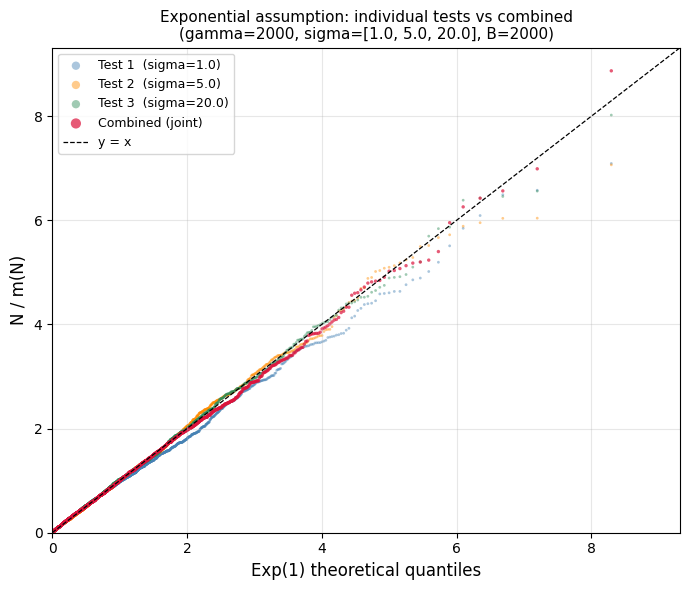

In [ ]:
# QQ-plot: exponential assumption for individual tests vs combined detector
# =============================================================================
# For each of the 3 individual tests (calibrated separately) and for the
# joint combined detector, we collect alarm times, standardise as N/m(N)
# (where m(N) = median/log2), and compare to Exp(1) quantiles.
#
# If the calibration is correct, all four series should lie on the diagonal.
# The combined series is the key check: it verifies that the standardization
# step in calibrate_threshold_arl controls the *joint* ARL correctly.
# =============================================================================

# ── Individual tests: calibrate + collect alarm times ────────────────────
individual_alarm_times = []

for sigma in SIGMAS:
    score_k  = MeanCUSUM(n_features=1, penalty=PenaltyType.CONSTANT)
    sampler_k = (lambda _s: lambda rng=None: np.array([np.random.default_rng().normal(0.0, _s)]))(sigma)
    tau_k = calibrate_threshold_arl(
        score_k, target_arl=GAMMA_3, n_paths=B_CAL_3,
        pre_sampler=sampler_k, rng=SEED_3, parallel=PARALLEL,
    )
    det_k = GridDetector(score=score_k, threshold=tau_k)
    at_k  = mc_alarm_times(
        det_k, n_paths=B_VERIFY_3, stream_len=STREAM_LEN3,
        pre_sampler=sampler_k, rng=SEED_3 + 1, parallel=PARALLEL,
    )
    individual_alarm_times.append(at_k)
    print(f"  sigma={sigma:<5}  tau={tau_k:.4f}  "
          f"mean ARL={at_k[at_k < STREAM_LEN3].mean():.0f}")

# ── Combined detector: reuse alarm_times3 from previous cell ─────────────
combined_at = alarm_times3

# ── Helper: standardise alarm times as N/m(N), m(N) = median/log2 ────────
def standardise(alarm_times, stream_len):
    alarmed = alarm_times[alarm_times < stream_len].astype(float)
    m = np.median(alarmed) / np.log(2)
    return alarmed / m


# ── QQ-plot ───────────────────────────────────────────────────────────────
COLORS_IND = ["steelblue", "darkorange", "seagreen"]
COLOR_COMB = "crimson"

fig, ax = plt.subplots(figsize=(7, 6))

all_series = [
    (standardise(at, STREAM_LEN3), f"Test {k+1}  (sigma={s})", COLORS_IND[k], 4, 0.45)
    for k, (at, s) in enumerate(zip(individual_alarm_times, SIGMAS))
] + [
    (standardise(combined_at, STREAM_LEN3), "Combined (joint)", COLOR_COMB, 6, 0.7),
]

hi = 0.0
for std_at, label, color, ms, alpha in all_series:
    n = len(std_at)
    theor = sp_stats.expon.ppf((np.arange(1, n + 1) - 0.5) / n)
    ax.scatter(theor, np.sort(std_at), s=ms, alpha=alpha,
               color=color, edgecolors="none", label=label)
    hi = max(hi, theor.max(), std_at.max())

hi *= 1.05
ax.plot([0, hi], [0, hi], "k--", lw=0.9, label="y = x")
ax.set_xlim(0, hi)
ax.set_ylim(0, hi)
ax.set_xlabel("Exp(1) theoretical quantiles", fontsize=12)
ax.set_ylabel("N / m(N)", fontsize=12)
ax.set_title(
    f"Exponential assumption: individual tests vs combined\n"
    f"(gamma={GAMMA_3}, sigma={SIGMAS}, B={B_VERIFY_3})",
    fontsize=11,
)
ax.legend(fontsize=9, markerscale=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2. ARL calibration convergence: Empirical ARL vs number of MC simulations

How many calibration paths ($K_{\mathrm{CAL}}$) are needed for a stable threshold?

**Method:** For different values of $K_{\mathrm{CAL}}$ and different calibration targets $\gamma$: Repeat $R=100$ times:
calibrate to a target ARL using $K_{\mathrm{CAL}}$ MC paths, then verify on $N_{\mathrm{VER}}=100$
null streams. Plot empirical ARL (box-plot).

Score: `MeanCUSUM(penalty=CONSTANT)`, null: N(0,1).

In [ ]:
# ARL calibration convergence across target ARLs
# ===============================================
# Extends the single-target study to TARGET_ARL in {100, 200, 500, 1000}.
# Pool trick: draw N_POOL max-scores once per (target_arl, r), then subsample
# for smaller K_CAL values — avoids 4 × 10 × 100 = 4 000 separate calibration calls.
import numpy as np
from gridcp import GridDetector
from gridcp.calibration import mc_alarm_times, mc_max_scores, with_calibrated_threshold
from gridcp.scores import MeanCUSUM
from gridcp.typing import PenaltyType

TARGET_ARL_VALUES = [100, 200, 500, 1000]
R                 = 50
N_VER             = 1000
K_CAL_VALUES      = [10, 20, 50, 100, 200, 500, 1_000]
N_POOL            = max(K_CAL_VALUES)
QUANTILE_LEVEL    = 1.0 / np.e   # (1/e)-quantile → expected alarm time ≈ target_arl

score   = MeanCUSUM(penalty=PenaltyType.CONSTANT)
sampler = lambda rng=None: rng.standard_normal()

# arl_matrices[target_arl] has shape (n_K, R); values are empirical ARL / target_arl
arl_matrices = {}

for target_arl in TARGET_ARL_VALUES:
    detector = GridDetector(score=score)
    max_t = 5 * target_arl
    n_K = len(K_CAL_VALUES)
    fm = np.zeros((n_K, R))

    # Draw calibration pool: R draws of N_POOL max-scores each
    pool = np.zeros((R, N_POOL))
    for r in range(R):
        pool[r] = mc_max_scores(
            detector, N_POOL, target_arl, pre_sampler=sampler, rng=r
        )
    print(f"TARGET_ARL={target_arl}: pool done.")

    for k, K_CAL in enumerate(K_CAL_VALUES):
        for r in range(R):
            threshold = float(np.quantile(pool[r, :K_CAL], QUANTILE_LEVEL))
            det_r = with_calibrated_threshold(detector, threshold)
            at = mc_alarm_times(
                det_r, N_VER, max_t,
                pre_sampler=sampler,
                rng=R + k * R + r,
            )
            fm[k, r] = at.mean() / target_arl
        print(f"  K_CAL={K_CAL:>6}  mean ARL ratio={fm[k].mean():.4f}")
    arl_matrices[target_arl] = fm


TARGET_ARL=100: pool done.
  K_CAL=    10  mean ARL ratio=1.1454
  K_CAL=    20  mean ARL ratio=1.0933
  K_CAL=    50  mean ARL ratio=1.0064
  K_CAL=   100  mean ARL ratio=0.9935
  K_CAL=   200  mean ARL ratio=1.0066
  K_CAL=   500  mean ARL ratio=0.9852
  K_CAL=  1000  mean ARL ratio=0.9991
TARGET_ARL=200: pool done.
  K_CAL=    10  mean ARL ratio=1.0571
  K_CAL=    20  mean ARL ratio=1.0350
  K_CAL=    50  mean ARL ratio=0.9909
  K_CAL=   100  mean ARL ratio=1.0016
  K_CAL=   200  mean ARL ratio=0.9869
  K_CAL=   500  mean ARL ratio=0.9803
  K_CAL=  1000  mean ARL ratio=1.0017
TARGET_ARL=500: pool done.
  K_CAL=    10  mean ARL ratio=1.0683
  K_CAL=    20  mean ARL ratio=0.9866
  K_CAL=    50  mean ARL ratio=0.9739
  K_CAL=   100  mean ARL ratio=0.9745
  K_CAL=   200  mean ARL ratio=0.9898
  K_CAL=   500  mean ARL ratio=0.9839
  K_CAL=  1000  mean ARL ratio=0.9913
TARGET_ARL=1000: pool done.
  K_CAL=    10  mean ARL ratio=1.0570
  K_CAL=    20  mean ARL ratio=1.0233
  K_CAL=    50  m

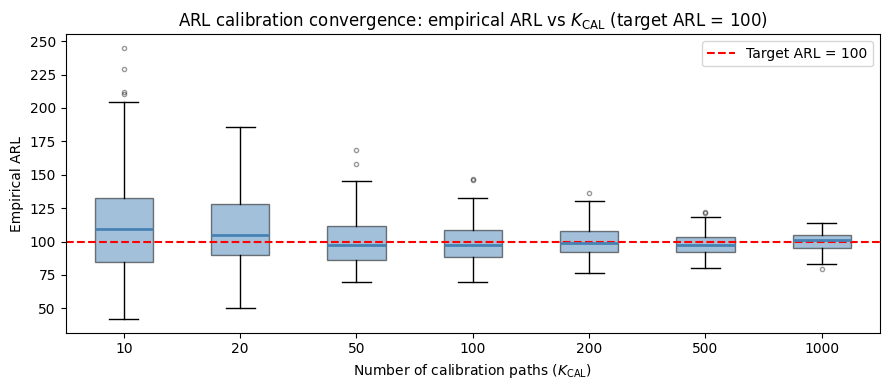

In [72]:
fig, ax = plt.subplots(figsize=(9, 4))

fm_raw = arl_matrices[100] * 100   # un-normalize
ax.boxplot(
    fm_raw.T,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.5),
    medianprops=dict(color="steelblue", linewidth=2),
    flierprops=dict(marker="o", markersize=3, alpha=0.4)
)
ax.axhline(100, color="r", linestyle="--", label="Target ARL = 100")
ax.set_xticks(range(1, len(K_CAL_VALUES) + 1))
ax.set_xticklabels(K_CAL_VALUES)
ax.set_xlabel("Number of calibration paths ($K_{\\mathrm{CAL}}$)")
ax.set_ylabel("Empirical ARL")
ax.set_title("ARL calibration convergence: empirical ARL vs $K_{\\mathrm{CAL}}$ (target ARL = 100)")
ax.legend()
plt.tight_layout()
plt.show()

<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3328885/507480702.py:38: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("Number of calibration paths ($K_{\mathrm{CAL}}$)")
/tmp/ipykernel_3328885/507480702.py:41: SyntaxWarning: invalid escape sequence '\m'
  "ARL calibration convergence: empirical ARL ratio vs $K_{\mathrm{CAL}}$\n"


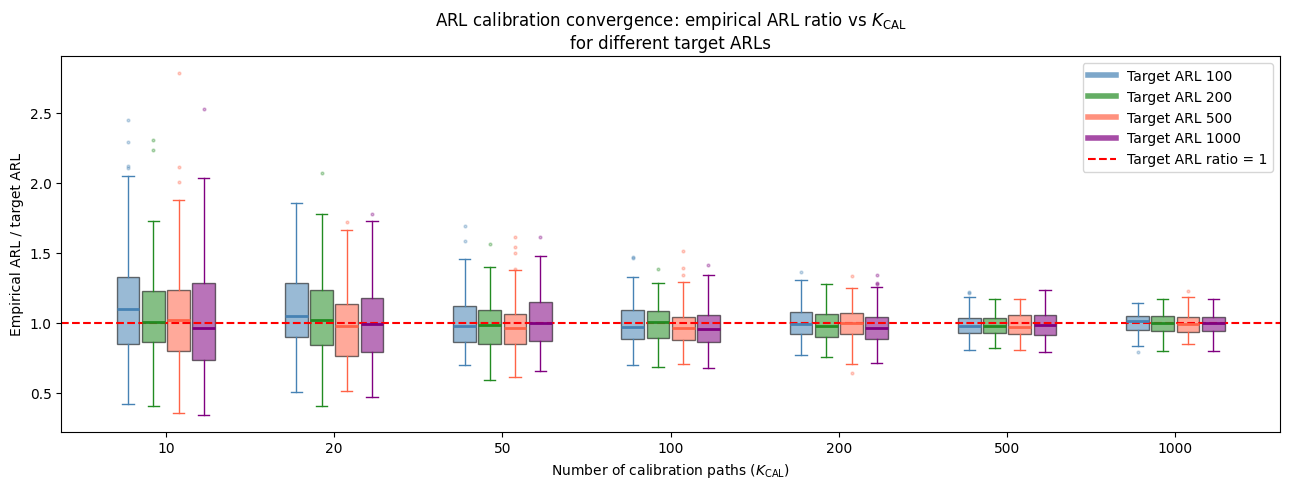

In [ ]:
# ARL convergence: grouped box plot by target ARL
# ================================================
import matplotlib.pyplot as plt
import numpy as np

colors = {100: "steelblue", 200: "forestgreen", 500: "tomato", 1000: "purple"}
n_K = len(K_CAL_VALUES)
n_T = len(TARGET_ARL_VALUES)
width = 0.6 / n_T
offsets = np.linspace(-(n_T - 1) / 2, (n_T - 1) / 2, n_T) * width

fig, ax = plt.subplots(figsize=(13, 5))

for i, target_arl in enumerate(TARGET_ARL_VALUES):
    fm = arl_matrices[target_arl]
    positions = np.arange(1, n_K + 1) + offsets[i]
    ax.boxplot(
        fm.T,
        positions=positions,
        widths=width * 0.9,
        patch_artist=True,
        boxprops=dict(facecolor=colors[target_arl], alpha=0.55),
        medianprops=dict(color=colors[target_arl], linewidth=2),
        whiskerprops=dict(color=colors[target_arl]),
        capprops=dict(color=colors[target_arl]),
        flierprops=dict(
            marker="o", markersize=2, alpha=0.3,
            markerfacecolor=colors[target_arl], markeredgecolor=colors[target_arl],
        ),
        manage_ticks=False,
    )
    ax.plot([], [], color=colors[target_arl], linewidth=4, alpha=0.7,
            label=f"Target ARL {target_arl}")

ax.axhline(1.0, color="r", linestyle="--", label="Target ARL ratio = 1")
ax.set_xticks(range(1, n_K + 1))
ax.set_xticklabels(K_CAL_VALUES)
ax.set_xlabel("Number of calibration paths ($K_{\mathrm{CAL}}$)")
ax.set_ylabel("Empirical ARL / target ARL")
ax.set_title(
    "ARL calibration convergence: empirical ARL ratio vs $K_{\mathrm{CAL}}$\n"
    "for different target ARLs"
)
ax.legend()
plt.tight_layout()
plt.show()


## Check that detection delay decreases

Calibrating scenario 1 (MeanCUSUM, Gaussian mean)...
  threshold: 13.7008
Calibrating scenario 2 (Variance, Gaussian variance)...
  threshold: 15.3760
Calibrating scenario 3 (EF GLR poisson, Poisson rate)...
  threshold: 13.3354


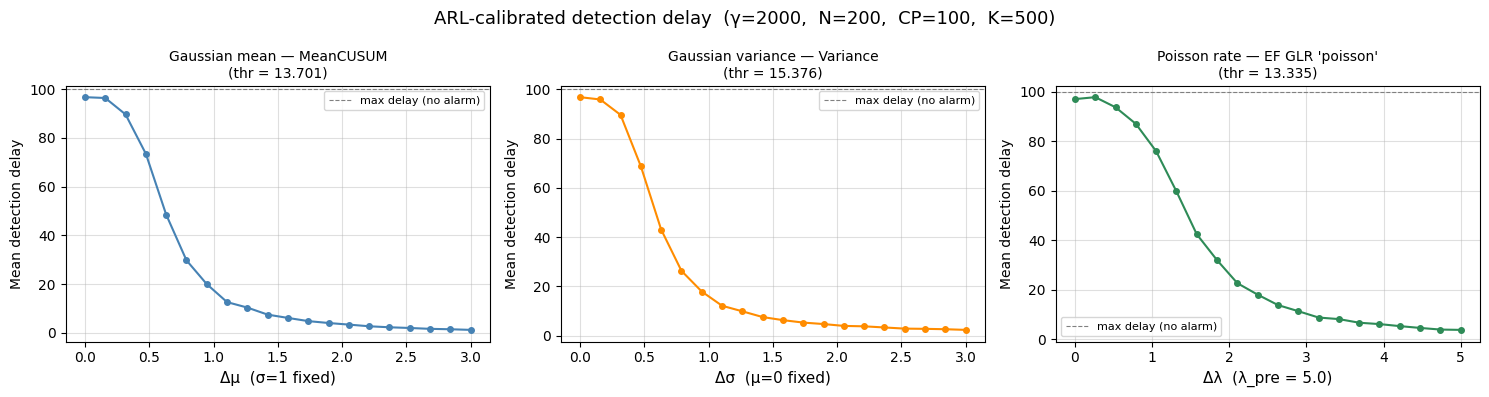

In [14]:
# ARL Calibration — Detection delay sweep for three score families
# =============================================================================
# Each score is ARL-calibrated to γ=2000 with PenaltyType.CONSTANT.
#
# Scenarios
# ---------
#  1. Gaussian mean change     — MeanCUSUM           Pre: N(0,1)  Post: N(δ,1)
#  2. Gaussian variance change — Variance             Pre: N(0,1)  Post: N(0,1+Δσ)
#  3. Poisson rate change      — ExponentialFamilyGLR Pre: Poi(5)  Post: Poi(5+Δλ)
#
# Detection delay:
#   - Correct detection (CP ≤ alarm < N): delay = alarm - CP
#   - No alarm (sentinel = N):            delay = N - CP  (censored at stream end)
#   - False alarm (alarm < CP):           excluded from the mean
# =============================================================================

from gridcp.detector import GridDetector
from gridcp.calibration import mc_alarm_times
from gridcp.scores import MeanCUSUM, Variance, ExponentialFamilyGLR
from gridcp.typing import PenaltyType

GAMMA    = 2000    # target ARL
B_CAL    = 3000    # calibration paths
N_PERF   = 200     # stream length
CP_PERF  = 100     # changepoint location
K_PERF   = 500     # paths per delta value
SEED_P   = 42
PARALLEL = True


def mean_delay(alarms, cp, n):
    """Mean detection delay, censoring non-detections and excluding false alarms."""
    correct  = alarms[(alarms >= cp) & (alarms < n)] - cp
    n_missed = np.sum(alarms == n)
    all_delays = np.concatenate([correct, np.full(n_missed, n - cp)])
    return np.mean(all_delays) if len(all_delays) > 0 else np.nan


# ── Scenario 1: Gaussian mean change — MeanCUSUM ──────────────────────────
print("Calibrating scenario 1 (MeanCUSUM, Gaussian mean)...")
pre_s1   = lambda rng=None: np.random.default_rng().standard_normal(1)
score_s1 = MeanCUSUM(n_features=1, penalty=PenaltyType.CONSTANT)
thr_s1   = calibrate_threshold_arl(
    score_s1, target_arl=GAMMA, n_paths=B_CAL,
    pre_sampler=pre_s1, rng=SEED_P, parallel=PARALLEL,
)
det_s1 = GridDetector(score=score_s1, threshold=thr_s1)
print(f"  threshold: {thr_s1:.4f}")

deltas_s1 = np.linspace(0.0, 3.0, 20)
delays_s1 = []
for delta in deltas_s1:
    alarms = mc_alarm_times(
        det_s1, n_paths=K_PERF, stream_len=N_PERF,
        pre_sampler=pre_s1,
        post_sampler=lambda rng=None, _d=delta: np.random.default_rng().normal(_d, 1.0, 1),
        changepoint=CP_PERF, parallel=PARALLEL, rng=SEED_P,
    )
    delays_s1.append(mean_delay(alarms, CP_PERF, N_PERF))


# ── Scenario 2: Gaussian variance change — Variance ───────────────────────
print("Calibrating scenario 2 (Variance, Gaussian variance)...")
pre_s2   = lambda rng=None: np.random.default_rng().standard_normal(1)
score_s2 = Variance(n_features=1, penalty=PenaltyType.CONSTANT)
thr_s2   = calibrate_threshold_arl(
    score_s2, target_arl=GAMMA, n_paths=B_CAL,
    pre_sampler=pre_s2, rng=SEED_P, parallel=PARALLEL,
)
det_s2 = GridDetector(score=score_s2, threshold=thr_s2)
print(f"  threshold: {thr_s2:.4f}")

deltas_s2 = np.linspace(0.0, 3.0, 20)   # Δσ: post std = 1 + Δσ
delays_s2 = []
for delta in deltas_s2:
    sigma_post = 1.0 + delta
    alarms = mc_alarm_times(
        det_s2, n_paths=K_PERF, stream_len=N_PERF,
        pre_sampler=pre_s2,
        post_sampler=lambda rng=None, _s=sigma_post: np.random.default_rng().normal(0.0, _s, 1),
        changepoint=CP_PERF, parallel=PARALLEL, rng=SEED_P,
    )
    delays_s2.append(mean_delay(alarms, CP_PERF, N_PERF))


# ── Scenario 3: Poisson rate change — ExponentialFamilyGLR('poisson') ─────
print("Calibrating scenario 3 (EF GLR poisson, Poisson rate)...")
lambda_pre = 5.0
pre_s3   = lambda rng=None: np.array([float(np.random.default_rng().poisson(lambda_pre))])
score_s3 = ExponentialFamilyGLR.from_family('poisson', penalty=PenaltyType.CONSTANT)
thr_s3   = calibrate_threshold_arl(
    score_s3, target_arl=GAMMA, n_paths=B_CAL,
    pre_sampler=pre_s3, rng=SEED_P, parallel=PARALLEL,
)
det_s3 = GridDetector(score=score_s3, threshold=thr_s3)
print(f"  threshold: {thr_s3:.4f}")

deltas_s3 = np.linspace(0.0, 5.0, 20)   # Δλ: post rate = lambda_pre + Δλ
delays_s3 = []
for delta in deltas_s3:
    lam_post = lambda_pre + delta
    alarms = mc_alarm_times(
        det_s3, n_paths=K_PERF, stream_len=N_PERF,
        pre_sampler=pre_s3,
        post_sampler=lambda rng=None, _l=lam_post: np.array([float(np.random.default_rng().poisson(_l))]),
        changepoint=CP_PERF, parallel=PARALLEL, rng=SEED_P,
    )
    delays_s3.append(mean_delay(alarms, CP_PERF, N_PERF))


# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle(
    f'ARL-calibrated detection delay  '
    f'(γ={GAMMA},  N={N_PERF},  CP={CP_PERF},  K={K_PERF})',
    fontsize=13,
)

for ax, deltas, delays, xlabel, title, color in [
    (axes[0], deltas_s1, delays_s1,
     'Δμ  (σ=1 fixed)',
     f'Gaussian mean — MeanCUSUM\n(thr = {thr_s1:.3f})',
     'steelblue'),
    (axes[1], deltas_s2, delays_s2,
     'Δσ  (μ=0 fixed)',
     f'Gaussian variance — Variance\n(thr = {thr_s2:.3f})',
     'darkorange'),
    (axes[2], deltas_s3, delays_s3,
     f'Δλ  (λ_pre = {lambda_pre})',
     f"Poisson rate — EF GLR 'poisson'\n(thr = {thr_s3:.3f})",
     'seagreen'),
]:
    ax.plot(deltas, delays, marker='o', markersize=4, lw=1.5, color=color)
    ax.axhline(N_PERF - CP_PERF, ls='--', color='grey', lw=0.8, label='max delay (no alarm)')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Mean detection delay', fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


### ARL vs number of tests ($K$)

**Purpose:** (i) Check that ARL calibration corrects for multiple tests (step 2 of OCD). so that empirical ARL does not decrease as the number of tests increases. (ii) Compare performance and speed of re-running simulations in the second step of the ocd-procedure vs. re-using the ones from step 1

**Method:** For some number ($K$) of independent MeanCUSUM tests (constant penalty, N(0,1) null), calibrate to $\mathbb{E}[\gamma]=100$ using $K_{\mathrm{CAL}}=100$ (in the "correct" ocd implementation, this means 200 streams total - 100 in step 1 and 100 in step 2). Verify on 100 streams of length 500. Rerun 50 timer per $K$, and plot distribution of empirical ARL per $K$ (box-plot) and time, for each of the two methods (no re-run of simulations vs re-run simulations).

In [64]:
 # ARL vs K — one-sim vs two-sim: fair comparison (shared step-1 batch)                                                                                                                                        
# =============================================================================                                                                                                                               
import time                                                                                                                                                                                                   
from dataclasses import dataclass                                                                                                                                                                             
                                                                                                                                                                                                              
import numpy as np                                                                                                                                                                                            
from gridcp import GridDetector                                                                                                                                                                               
from gridcp.calibration import mc_alarm_times, mc_max_scores                                                                                                                                                  
from gridcp.scores import MeanCUSUM
from gridcp.typing import PenaltyType                                                                                                                                                                         
                                                                                                                                                                                                            
                                                                                                                                                                                                              
@dataclass(frozen=True, slots=True)
class MultiTestScore:                                                                                                                                                                                         
    """K independent single-feature MeanCUSUM scores, one per input component."""                                                                                                                           
    sub_scores: tuple
    n_features: int
    def init_state(self):
        return tuple(s.init_state() for s in self.sub_scores)
                                                                                                                                                                                                              
    def update(self, state, x):
        x = np.asarray(x, dtype=float).ravel()                                                                                                                                                                
        return tuple(                                                                                                                                                                                       
            s.update(st, x[k : k + 1])
            for k, (s, st) in enumerate(zip(self.sub_scores, state))
        )                                                                                                                                                                                                     
 
    def compute_penalised_scores(self, state, grid_states, n_samples_for_penalty=None):                                                                                                                       
        per_test = [                                                                                                                                                                                        
            sub_score.compute_penalised_scores(                                                                                                                                                               
                state[k],
                [gs[k] for gs in grid_states],                                                                                                                                                                
                n_samples_for_penalty=n_samples_for_penalty,                                                                                                                                                
            )
            for k, sub_score in enumerate(self.sub_scores)
        ]                                                                                                                                                                                                     
        return np.column_stack(per_test)  # (G, K)
                                                                                                                                                                                                              
                                                                                                                                                                                                              
def _threshold_from_max_scores(ms1, ms2):
    """Compute ARL threshold(s).                                                                                                                                                                              
                                                                                                                                                                                                            
    ms1 : (n_paths, K) or (n_paths,) — step-1 max scores (individual quantiles)
    ms2 : same shape — step-2 max scores (joint scaling); may be ms1 itself (one-sim)                                                                                                                         
    """                                                                                                                                                                                                       
    if ms1.ndim == 1:                                                                                                                                                                                         
        # K=1: no joint scaling needed, both methods identical                                                                                                                                                
        return float(np.quantile(ms1, 1.0 / np.e))                                                                                                                                                          
                                                                                                                                                                                                              
    individual_thresholds = np.array(                                                                                                                                                                       
        [float(np.quantile(ms1[:, k], 1.0 / np.e)) for k in range(ms1.shape[1])],                                                                                                                             
        dtype=np.float64,                                                                                                                                                                                   
    )
    combined_max = np.max(ms2 / individual_thresholds, axis=1)                                                                                                                                                
    c = float(np.quantile(combined_max, 1.0 / np.e))
    return c * individual_thresholds                                                                                                                                                                          
                                                                                                                                                                                                              
 
TARGET_ARL = 100                                                                                                                                                                                              
B_CAL      = 1000   # paths per step (both steps use B_CAL paths)                                                                                                                                           
B_VER      = 1000   # verification paths per repeat                                                                                                                                                           
R          = 50     # repeats per K
MAX_T      = 5 * TARGET_ARL                                                                                                                                                                                   
K_VALUES   = 2 ** np.arange(1, 7)   # 2, 4, 8, 16, 32, 64                                                                                                                                                   
                                                                                                                                                                                                              
                                                                                                                                                                                                            
def make_null_sampler(K):                                                                                                                                                                                     
    def sampler(rng):                                                                                                                                                                                       
        return rng.standard_normal(K)
    return sampler
                                                                                                                                                                                                              
arls_one, arls_two   = {}, {}
times_one, times_two = {}, {}                                                                                                                                                                                 
                                                                                                                                                                                                            
for K in K_VALUES:
    score        = MultiTestScore(
        sub_scores=tuple(MeanCUSUM(n_features=1, penalty=PenaltyType.CONSTANT) for _ in range(K)),
        n_features=int(K),                                                                                                                                                                                    
    )
    null_sampler = make_null_sampler(int(K))                                                                                                                                                                  
    detector_base = GridDetector(score=score, threshold=1.0)                                                                                                                                                
                                                                                                                                                                                                              
    arls_one[K]  = np.empty(R)
    arls_two[K]  = np.empty(R)                                                                                                                                                                                
    times_one[K] = np.empty(R)                                                                                                                                                                              
    times_two[K] = np.empty(R)
                                                                                                                                                                                                              
    for r in range(R):
        seed = r * 1000                                                                                                                                                                                       
                                                                                                                                                                                                            
        # --- Shared step-1 batch ---
        t0  = time.perf_counter()
        ms1 = mc_max_scores(                                                                                                                                                                                  
            detector_base, B_CAL, TARGET_ARL,
            pre_sampler=null_sampler, rng=seed, parallel=True,                                                                                                                                                
        )                                                                                                                                                                                                   
        t_ms1 = time.perf_counter() - t0
                                                                                                                                                                                                              
        # --- One-sim: reuse ms1 for step 2 ---
        t0 = time.perf_counter()                                                                                                                                                                              
        thr_one = _threshold_from_max_scores(ms1, ms1)                                                                                                                                                      
        times_one[K][r] = t_ms1 + (time.perf_counter() - t0)                                                                                                                                                  
 
        # --- Two-sim: fresh batch for step 2 ---                                                                                                                                                             
        t0  = time.perf_counter()                                                                                                                                                                           
        ms2 = mc_max_scores(                                                                                                                                                                                  
            detector_base, B_CAL, TARGET_ARL,                                                                                                                                                               
            pre_sampler=null_sampler, rng=seed + 10_000, parallel=True,
        )                                                                                                                                                                                                     
        thr_two = _threshold_from_max_scores(ms1, ms2)
        times_two[K][r] = t_ms1 + (time.perf_counter() - t0)                                                                                                                                                  
                                                                                                                                                                                                              
        # --- Shared verification (same null streams, different thresholds) ---                                                                                                                               
        det_one = GridDetector(score=score, threshold=thr_one)                                                                                                                                                
        at_one  = mc_alarm_times(                                                                                                                                                                             
            det_one, B_VER, MAX_T,                                                                                                                                                                          
            pre_sampler=null_sampler, rng=seed + 1, parallel=True,
        )                                                                                                                                                                                                     
        arls_one[K][r] = at_one.mean()
                                                                                                                                                                                                              
        det_two = GridDetector(score=score, threshold=thr_two)                                                                                                                                                
        at_two  = mc_alarm_times(
            det_two, B_VER, MAX_T,                                                                                                                                                                            
            pre_sampler=null_sampler, rng=seed + 1, parallel=True,                                                                                                                                          
        )
        arls_two[K][r] = at_two.mean()
                                                                                                                                                                                                              
    print(
        f"K={K:2d}  "                                                                                                                                                                                         
        f"one-sim: ARL={arls_one[K].mean():.1f} ± {arls_one[K].std():.1f}  "
        f"t={times_one[K].mean():.2f}s  |  "                                                                                                                                                                  
        f"two-sim: ARL={arls_two[K].mean():.1f} ± {arls_two[K].std():.1f}  "
        f"t={times_two[K].mean():.2f}s"                                                                                                                                                                       
    )

K= 2  one-sim: ARL=97.9 ± 3.3  t=0.85s  |  two-sim: ARL=98.1 ± 3.6  t=1.70s
K= 4  one-sim: ARL=97.9 ± 4.7  t=1.18s  |  two-sim: ARL=98.5 ± 4.9  t=2.37s
K= 8  one-sim: ARL=98.1 ± 3.8  t=1.87s  |  two-sim: ARL=98.6 ± 3.9  t=3.76s
K=16  one-sim: ARL=97.9 ± 4.2  t=3.22s  |  two-sim: ARL=98.1 ± 4.6  t=6.45s
K=32  one-sim: ARL=98.1 ± 3.7  t=5.81s  |  two-sim: ARL=98.5 ± 4.2  t=11.66s
K=64  one-sim: ARL=97.6 ± 4.3  t=11.03s  |  two-sim: ARL=97.9 ± 4.5  t=22.00s


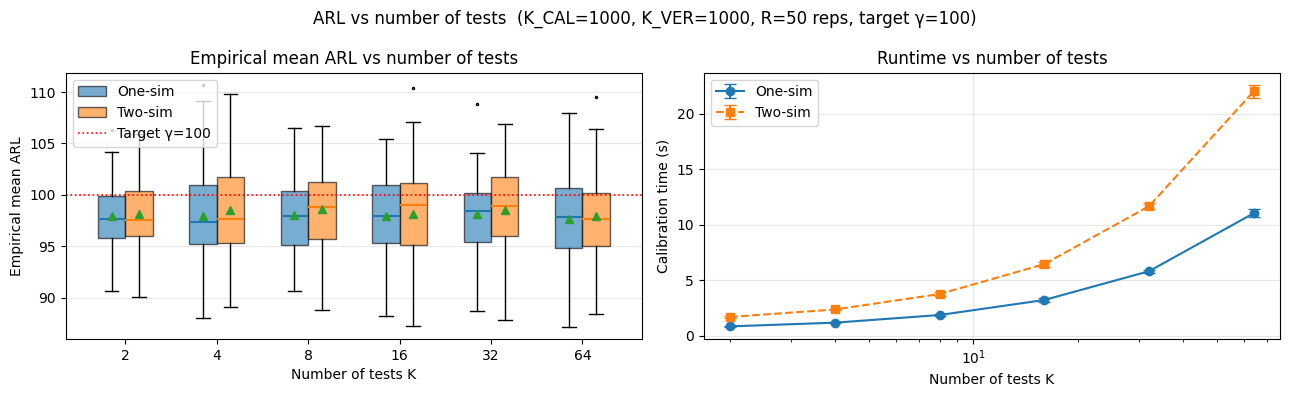

In [70]:
# ARL vs K — plot: correctness and speed
# =============================================================================
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    f"ARL vs number of tests  (K_CAL={B_CAL}, K_VER={B_VER}, R={R} reps, target γ={TARGET_ARL})",
    fontsize=12,
)

positions = np.arange(len(K_VALUES))
width = 0.3

# --- Correctness: boxplots of empirical mean ARL across R repetitions ---
bp1 = ax1.boxplot(
    [arls_one[K] for K in K_VALUES],
    positions=positions - width / 2,
    widths=width,
    patch_artist=True,
    boxprops=dict(facecolor="C0", alpha=0.6),
    medianprops=dict(color="C0", linewidth=1.5),
    flierprops=dict(marker=".", markersize=3),
    label="One-sim", showmeans=True,
)
bp2 = ax1.boxplot(
    [arls_two[K] for K in K_VALUES],
    positions=positions + width / 2,
    widths=width,
    patch_artist=True,
    boxprops=dict(facecolor="C1", alpha=0.6),
    medianprops=dict(color="C1", linewidth=1.5),
    flierprops=dict(marker=".", markersize=3),
    label="Two-sim", showmeans=True,
)
ax1.axhline(TARGET_ARL, color="red", linestyle=":", linewidth=1.2, label=f"Target γ={TARGET_ARL}")
ax1.set_xticks(positions)
ax1.set_xticklabels(K_VALUES)
ax1.set_xlabel("Number of tests K")
ax1.set_ylabel("Empirical mean ARL")
ax1.set_title("Empirical mean ARL vs number of tests")
ax1.legend(
    handles=[bp1["boxes"][0], bp2["boxes"][0], ax1.get_lines()[-1]],
    labels=["One-sim", "Two-sim", f"Target γ={TARGET_ARL}"],
)
ax1.grid(True, alpha=0.3, axis="y")

# --- Efficiency: mean calibration time ± std across R repetitions ---
t_one_mean = [times_one[K].mean() for K in K_VALUES]
t_two_mean = [times_two[K].mean() for K in K_VALUES]
t_one_std  = [times_one[K].std()  for K in K_VALUES]
t_two_std  = [times_two[K].std()  for K in K_VALUES]

ax2.errorbar(K_VALUES, t_one_mean, yerr=t_one_std, fmt="o-",  capsize=4, label="One-sim")
ax2.errorbar(K_VALUES, t_two_mean, yerr=t_two_std, fmt="s--", capsize=4, label="Two-sim")
ax2.set_xscale("log")
ax2.set_xlabel("Number of tests K")
ax2.set_ylabel("Calibration time (s)")
ax2.set_title("Runtime vs number of tests")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Bootstrap ARL Calibration

In [25]:
# Bootstrap ARL — Empirical ARL verification
# ============================================
# Score: MeanCUSUM with constant penalty (stationary under null)
# Target ARL: gamma = 500
#
# Three calibration paths compared:
#   (1) Block bootstrap (auto block length) — should also work on iid data
#   (2) iid bootstrap (block_length=1)      — appropriate for iid observations
#   (3) Parametric MC (gold standard)       — uses true N(0,1) null sampler
#
# Verification: N_PATHS_VER null streams, empirical mean alarm time should be approx gamma.

import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, ".")

from arl_calibration import (
    calibrate_threshold_arl,
    calibrate_threshold_arl_from_data,
    calibrate_threshold_arl_from_samples,
)
from gridcp import GridDetector
from gridcp.calibration import mc_alarm_times
from gridcp.scores import MeanCUSUM
from gridcp.typing import PenaltyType

TARGET_ARL = 500
N_PATHS_CAL = 1000
N_PATHS_VER = 2000
N_TRAIN = 10_000          # large enough for empirical null to match true N(0,1)

score = MeanCUSUM(n_features=1, penalty=PenaltyType.CONSTANT)

def null_sampler(rng):
    return rng.standard_normal()

# --- Generate iid N(0,1) training data ---
training_data = np.random.default_rng(0).standard_normal(N_TRAIN)
print(f"Training data: N={N_TRAIN:,}, iid N(0,1)")

bl_auto_iid = max(1, int(N_TRAIN ** (1.0 / 3.0)))
print(f"Auto block length: {bl_auto_iid}")

# --- (1) Block bootstrap (auto block length) ---
threshold_block = calibrate_threshold_arl_from_data(
    score=score,
    training_data=training_data,
    target_arl=TARGET_ARL,
    n_paths=N_PATHS_CAL,
    rng=42,
    parallel=False,
)

# --- (2) iid bootstrap (block_length=1) ---
threshold_iid_boot = calibrate_threshold_arl_from_data(
    score=score,
    training_data=training_data,
    target_arl=TARGET_ARL,
    n_paths=N_PATHS_CAL,
    block_length=1,
    rng=42,
    parallel=False,
)

# --- (3) Parametric MC (gold standard) ---
threshold_parametric = calibrate_threshold_arl(
    score=score,
    target_arl=TARGET_ARL,
    n_paths=N_PATHS_CAL,
    pre_sampler=null_sampler,
    rng=42,
    parallel=False,
)

print(f"Block bootstrap threshold (bl={bl_auto_iid})  : {threshold_block:.4f}")
print(f"iid  bootstrap threshold (bl=1)   : {threshold_iid_boot:.4f}")
print(f"Parametric MC threshold           : {threshold_parametric:.4f}")

# --- Verify empirical ARL for all three ---
alarm_times = {}
for th, name in [
    (threshold_block,      "block"),
    (threshold_iid_boot,   "iid_boot"),
    (threshold_parametric, "parametric"),
]:
    det = GridDetector(score=score, threshold=th)
    alarm_times[name] = mc_alarm_times(
        detector=det,
        n_paths=N_PATHS_VER,
        stream_len=TARGET_ARL * 6,
        pre_sampler=null_sampler,
        rng=99,
        parallel=False,
    )

print(f"Empirical ARL on iid N(0,1) data (target ARL = {TARGET_ARL}):")
print(f"  Block bootstrap (bl={bl_auto_iid})   : {alarm_times['block'].mean():.1f}  (ratio={alarm_times['block'].mean()/TARGET_ARL:.3f})")
print(f"  iid bootstrap (bl=1)    : {alarm_times['iid_boot'].mean():.1f}  (ratio={alarm_times['iid_boot'].mean()/TARGET_ARL:.3f})")
print(f"  Parametric MC           : {alarm_times['parametric'].mean():.1f}  (ratio={alarm_times['parametric'].mean()/TARGET_ARL:.3f})")


Training data: N=10,000, iid N(0,1)
Auto block length: 21
Block bootstrap threshold (bl=21)  : 10.3925
iid  bootstrap threshold (bl=1)   : 10.4499
Parametric MC threshold           : 10.9063
Empirical ARL on iid N(0,1) data (target ARL = 500):
  Block bootstrap (bl=21)   : 415.0  (ratio=0.830)
  iid bootstrap (bl=1)    : 427.1  (ratio=0.854)
  Parametric MC           : 532.8  (ratio=1.066)


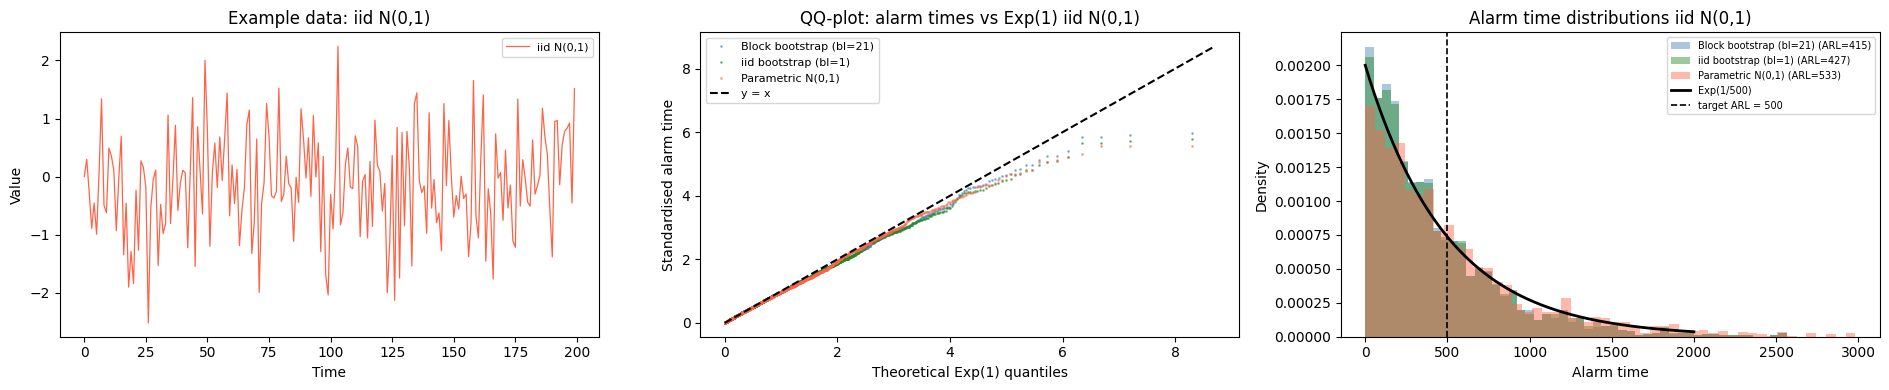

In [26]:
# iid N(0,1) — Example data, QQ-plots and alarm time histograms
# ==============================================================

fig, axes = plt.subplots(1, 3, figsize=(19, 4))

# Only include paths that alarmed before the stream ended
stream_len = TARGET_ARL * 6
at_shown = {k: v[v < stream_len] for k, v in alarm_times.items()}

# --- Subplot 0: Example iid data trace ---
rng_ex = np.random.default_rng(7)
n_ex = 200
ex_iid = rng_ex.standard_normal(n_ex)
t_ex = np.arange(n_ex)
axes[0].plot(t_ex, ex_iid, color="tomato", linewidth=0.9, label="iid N(0,1)")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Value")
axes[0].set_title("Example data: iid N(0,1)")
axes[0].legend(fontsize=8)

# --- Subplot 1: QQ-plot ---
styles = {
    "block":      ("steelblue",   f"Block bootstrap (bl={bl_auto_iid})"),
    "iid_boot":   ("forestgreen", "iid bootstrap (bl=1)"),
    "parametric": ("tomato",      "Parametric N(0,1)"),
}

for key, (color, label) in styles.items():
    at = at_shown[key]
    sorted_at = np.sort(at)
    n = len(sorted_at)
    theoretical_q = -np.log(1 - (np.arange(1, n + 1) - 0.5) / n)
    scale = np.median(at) / np.log(2)
    axes[1].plot(theoretical_q, sorted_at / scale, ".", color=color,
                 markersize=2, alpha=0.5, label=label)

lim = theoretical_q.max() * 1.05
axes[1].plot([0, lim], [0, lim], "k--", linewidth=1.5, label="y = x")
axes[1].set_xlabel("Theoretical Exp(1) quantiles")
axes[1].set_ylabel("Standardised alarm time")
axes[1].set_title("QQ-plot: alarm times vs Exp(1) iid N(0,1)")
axes[1].legend(fontsize=8)

# --- Subplot 2: Histogram of alarm times ---
x = np.linspace(0, TARGET_ARL * 4, 500)
for key, (color, label) in styles.items():
    at = at_shown[key]
    axes[2].hist(at, bins=50, density=True, alpha=0.45,
                 color=color, label=f"{label} (ARL={alarm_times[key].mean():.0f})")
axes[2].plot(x, (1 / TARGET_ARL) * np.exp(-x / TARGET_ARL), "k-",
             linewidth=2, label=f"Exp(1/{TARGET_ARL})")
axes[2].axvline(TARGET_ARL, color="k", linestyle="--", linewidth=1.2,
                label=f"target ARL = {TARGET_ARL}")
axes[2].set_xlabel("Alarm time")
axes[2].set_ylabel("Density")
axes[2].set_title("Alarm time distributions iid N(0,1)")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()


### Correlated Data: Block Bootstrap vs Wrong Parametric Assumption

A key motivation for the block bootstrap is data with **temporal dependence**.
When observations are autocorrelated, calibrating with a parametric iid N(0,1) assumption
gives the wrong threshold: under positive autocorrelation the CUSUM accumulates faster,
so the iid-calibrated threshold is too low and alarms fire much earlier than intended.

The block bootstrap corrects for this automatically by resampling in blocks that
preserve the within-block correlation structure.

**Setup:**
- Data: AR(1) with ρ = 0.4 and unit marginal variance, x_t = ρ·x_{t-1} + √(1-ρ²)·ε_t
- Three calibration strategies compared:
  1. **Block bootstrap** —  with auto block length
  2. **iid bootstrap** (block_length=1) — wrong for correlated data
  3. **Parametric MC** assuming iid N(0,1) — wrong for correlated data

In [16]:
# Correlated data — AR(1) bootstrap vs parametric calibration
# =============================================================

import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, ".")

from gridcp.calibration import (
    calibrate_threshold_arl,
    calibrate_threshold_arl_from_data,
)
from gridcp import GridDetector
from gridcp.calibration import _mc_alarm_times_chunk_from_samples
from gridcp.scores import MeanCUSUM
from gridcp.typing import PenaltyType

RHO       = 0.4          # AR(1) autocorrelation
TARGET_ARL = 500
N_PATHS_CAL = 1000
N_PATHS_VER = 2000
N_TRAIN   = 10_000

score = MeanCUSUM(n_features=1, penalty=PenaltyType.CONSTANT)

# --- Generate AR(1) training data ---
def generate_ar1(n, rho, rng):
    """AR(1) with unit marginal variance: x_t = rho*x_{t-1} + sqrt(1-rho^2)*eps_t."""
    sigma_eps = np.sqrt(1 - rho**2)
    x = np.zeros(n)
    x[0] = rng.standard_normal()
    eps = rng.standard_normal(n)
    for t in range(1, n):
        x[t] = rho * x[t-1] + sigma_eps * eps[t]
    return x

def generate_ar1_streams(n_paths, stream_len, rho, rng):
    """Vectorised AR(1) stream generation. Returns (n_paths, stream_len, 1)."""
    sigma_eps = np.sqrt(1 - rho**2)
    noise = rng.standard_normal((n_paths, stream_len))
    streams = np.zeros((n_paths, stream_len, 1))
    streams[:, 0, 0] = noise[:, 0]
    for t in range(1, stream_len):
        streams[:, t, 0] = rho * streams[:, t-1, 0] + sigma_eps * noise[:, t]
    return streams

training_data = generate_ar1(N_TRAIN, RHO, np.random.default_rng(0))
print(f"Training data: N={N_TRAIN:,}, rho={RHO}, sample mean={training_data.mean():.4f}")

# --- (1) Block bootstrap (auto block length) ---
bl_auto = max(1, int(N_TRAIN ** (1.0 / 3.0)))
print(f"Auto block length: {bl_auto}")
threshold_block = calibrate_threshold_arl_from_data(
    score=score,
    training_data=training_data,
    target_arl=TARGET_ARL,
    n_paths=N_PATHS_CAL,
    rng=42,
    parallel=False,
)

# --- (2) iid bootstrap (block_length=1, ignores correlation) ---
threshold_iid_boot = calibrate_threshold_arl_from_data(
    score=score,
    training_data=training_data,
    target_arl=TARGET_ARL,
    n_paths=N_PATHS_CAL,
    block_length=1,
    rng=42,
    parallel=False,
)

# --- (3) Parametric MC assuming iid N(0,1) ---
def null_sampler(rng):
    return rng.standard_normal()

threshold_parametric = calibrate_threshold_arl(
    score=score,
    target_arl=TARGET_ARL,
    n_paths=N_PATHS_CAL,
    pre_sampler=null_sampler,
    rng=42,
    parallel=False,
)

print(f"Block bootstrap threshold (bl={bl_auto})  : {threshold_block:.4f}")
print(f"iid  bootstrap threshold (bl=1)   : {threshold_iid_boot:.4f}")
print(f"Parametric MC threshold (N(0,1))  : {threshold_parametric:.4f}")

# --- Verify: run all three on AR(1) test streams ---
test_streams = generate_ar1_streams(N_PATHS_VER, TARGET_ARL * 6, RHO, np.random.default_rng(99))

alarm_times = {}
for th, key in [
    (threshold_block,      "block"),
    (threshold_iid_boot,   "iid_boot"),
    (threshold_parametric, "parametric"),
]:
    det = GridDetector(score=score, threshold=th)
    alarm_times[key] = _mc_alarm_times_chunk_from_samples(det, test_streams)

print(f"Empirical ARL on AR(1) data (rho={RHO}, target ARL = {TARGET_ARL}):")
print(f"  Block bootstrap   : {alarm_times['block'].mean():.1f}  (ratio={alarm_times['block'].mean()/TARGET_ARL:.3f})")
print(f"  iid bootstrap     : {alarm_times['iid_boot'].mean():.1f}  (ratio={alarm_times['iid_boot'].mean()/TARGET_ARL:.3f})")
print(f"  Parametric N(0,1) : {alarm_times['parametric'].mean():.1f}  (ratio={alarm_times['parametric'].mean()/TARGET_ARL:.3f})")

Training data: N=10,000, rho=0.4, sample mean=0.0097
Auto block length: 21
Block bootstrap threshold (bl=21)  : 18.3818
iid  bootstrap threshold (bl=1)   : 10.7472
Parametric MC threshold (N(0,1))  : 10.9063
Empirical ARL on AR(1) data (rho=0.4, target ARL = 500):
  Block bootstrap   : 463.2  (ratio=0.926)
  iid bootstrap     : 93.5  (ratio=0.187)
  Parametric N(0,1) : 96.6  (ratio=0.193)


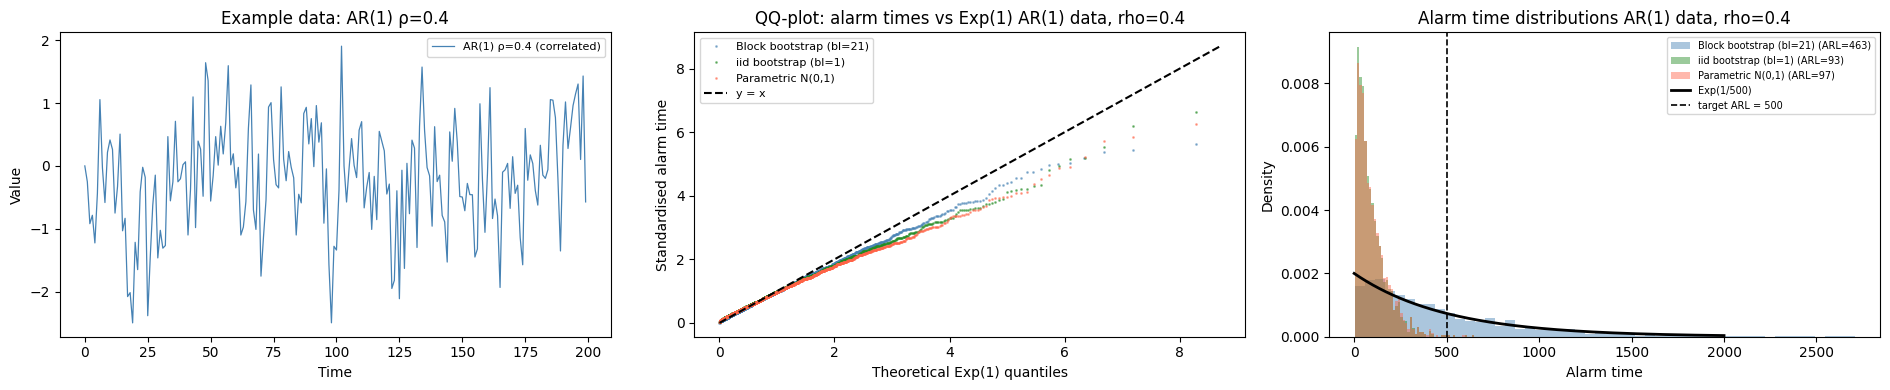

In [23]:
# AR(1) — Example data, QQ-plots and alarm time histograms
# ==========================================================

fig, axes = plt.subplots(1, 3, figsize=(19, 4))

# Only include paths that alarmed before the stream ended
stream_len = TARGET_ARL * 6
at_shown = {k: v[v < stream_len] for k, v in alarm_times.items()}

# --- Subplot 0: Example data traces ---
rng_ex = np.random.default_rng(7)
n_ex = 200
ex_corr = generate_ar1(n_ex, RHO, rng_ex)
ex_iid  = rng_ex.standard_normal(n_ex)
t_ex = np.arange(n_ex)
axes[0].plot(t_ex, ex_corr, color="steelblue", linewidth=0.9, label=f"AR(1) ρ={RHO} (correlated)")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Value")
axes[0].set_title(f"Example data: AR(1) ρ={RHO}")
axes[0].legend(fontsize=8)

# --- Subplot 1: QQ-plot ---
styles = {
    "block":      ("steelblue",   f"Block bootstrap (bl={bl_auto})"),
    "iid_boot":   ("forestgreen", "iid bootstrap (bl=1)"),
    "parametric": ("tomato",      "Parametric N(0,1)"),
}

for key, (color, label) in styles.items():
    at = at_shown[key]
    sorted_at = np.sort(at)
    n = len(sorted_at)
    theoretical_q = -np.log(1 - (np.arange(1, n + 1) - 0.5) / n)
    scale = np.median(at) / np.log(2)
    axes[1].plot(theoretical_q, sorted_at / scale, ".", color=color,
                 markersize=2, alpha=0.5, label=label)

lim = theoretical_q.max() * 1.05
axes[1].plot([0, lim], [0, lim], "k--", linewidth=1.5, label="y = x")
axes[1].set_xlabel("Theoretical Exp(1) quantiles")
axes[1].set_ylabel("Standardised alarm time")
axes[1].set_title(f"QQ-plot: alarm times vs Exp(1) AR(1) data, rho={RHO}")
axes[1].legend(fontsize=8)

# --- Subplot 2: Histogram of alarm times ---
x = np.linspace(0, TARGET_ARL * 4, 500)
for key, (color, label) in styles.items():
    at = at_shown[key]
    axes[2].hist(at, bins=50, density=True, alpha=0.45,
                 color=color, label=f"{label} (ARL={alarm_times[key].mean():.0f})")
axes[2].plot(x, (1 / TARGET_ARL) * np.exp(-x / TARGET_ARL), "k-",
             linewidth=2, label=f"Exp(1/{TARGET_ARL})")
axes[2].axvline(TARGET_ARL, color="k", linestyle="--", linewidth=1.2,
                label=f"target ARL = {TARGET_ARL}")
axes[2].set_xlabel("Alarm time")
axes[2].set_ylabel("Density")
axes[2].set_title(f"Alarm time distributions AR(1) data, rho={RHO}")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()


## False alarm rate analysis


### FAR calibration convergence: Empirical FA rate vs number of MC simulations

How many calibration paths ($K_{\mathrm{CAL}}$) are needed for a stable threshold?

**Method:** For different values of $K_{\mathrm{CAL}}$: Repeat $R=100$ times:
calibrate to a target FAR of α=0.05 at horizon $N=100$ using $K_{\mathrm{CAL}}$ MC paths,
then verify on $N_{\mathrm{VER}}=100$ null streams of length $N=100$.
Plot empirical FA rate (box-plot).

Score: `MeanCUSUM(penalty=CONSTANT)`, null: N(0,1).

In [48]:
# FAR calibration convergence — empirical FA rate vs number of calibration paths
# =============================================================================
# Speed note: instead of calling calibrate_threshold_false_alarm R times per
# K_CAL value (1 000 separate calibration runs), we draw a pool of
# N_POOL = max(K_CAL_VALUES) max-scores once per repeat and subsample for
# smaller K_CAL values. This cuts calibration calls from 1 000 → R = 100.
import numpy as np
import matplotlib.pyplot as plt
from gridcp import GridDetector
from gridcp.calibration import (
    mc_alarm_times,
    mc_max_scores,
    with_calibrated_threshold,
)
from gridcp.scores import MeanCUSUM
from gridcp.typing import PenaltyType

ALPHA        = 0.05
STREAM_LEN   = 100        # calibration horizon
R            = 100        # repeats per K_CAL value
N_VER        = 1000        # verification streams per repeat
K_CAL_VALUES = [10, 20, 50, 100, 200, 500, 1_000] #, 2_000, 5_000, 10_000]
N_POOL       = max(K_CAL_VALUES)  # paths drawn per repeat

score    = MeanCUSUM()
detector = GridDetector(score=score)
sampler  = lambda rng=None: rng.standard_normal()

n_K = len(K_CAL_VALUES)
far_matrix = np.zeros((n_K, R))  # empirical FA rates, shape (n_K, R)

# Step 1: draw one pool of N_POOL max-scores per repeat (R calls total)
pool = np.zeros((R, N_POOL))
for r in range(R):
    pool[r] = mc_max_scores(
        detector, N_POOL, STREAM_LEN,
        pre_sampler=sampler,
        rng=r,
    )
    if r%10 == 0:
        print(f"Calibration pool: repeat {r+1}/{R} done.")
print("Calibration pool done.")

# Step 2: for each K_CAL, subsample pool and verify
for k, K_CAL in enumerate(K_CAL_VALUES):
    for r in range(R):
        threshold = float(np.quantile(pool[r, :K_CAL], 1.0 - ALPHA))
        det_r = with_calibrated_threshold(detector, threshold)
        at = mc_alarm_times(
            det_r, N_VER, STREAM_LEN,
            pre_sampler=sampler,
            rng=R + k * R + r,
        )
        far_matrix[k, r] = np.mean(at < STREAM_LEN)
    print(f"K_CAL={K_CAL:>6}  done ({k+1}/{n_K})")

print(f"Done. far_matrix shape: {far_matrix.shape}")

Calibration pool: repeat 1/100 done.
Calibration pool: repeat 11/100 done.
Calibration pool: repeat 21/100 done.
Calibration pool: repeat 31/100 done.
Calibration pool: repeat 41/100 done.
Calibration pool: repeat 51/100 done.
Calibration pool: repeat 61/100 done.
Calibration pool: repeat 71/100 done.
Calibration pool: repeat 81/100 done.
Calibration pool: repeat 91/100 done.
Calibration pool done.
K_CAL=    10  done (1/7)
K_CAL=    20  done (2/7)
K_CAL=    50  done (3/7)
K_CAL=   100  done (4/7)
K_CAL=   200  done (5/7)
K_CAL=   500  done (6/7)
K_CAL=  1000  done (7/7)
Done. far_matrix shape: (7, 100)


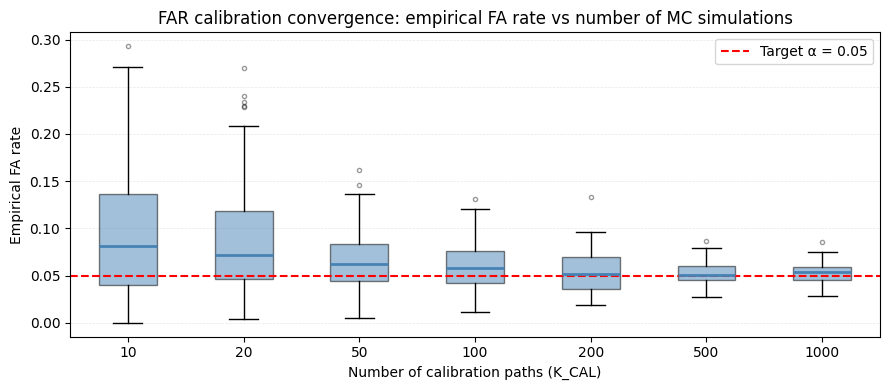

In [49]:
# FAR calibration convergence — plot
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 4))

ax.boxplot(
    far_matrix.T,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.5),
    medianprops=dict(color="steelblue", linewidth=2),
    flierprops=dict(marker="o", markersize=3, alpha=0.4),
)
ax.axhline(ALPHA, color="r", linestyle="--", label=f"Target \u03b1 = {ALPHA}")
ax.set_xticks(range(1, len(K_CAL_VALUES) + 1))
ax.set_xticklabels(K_CAL_VALUES)
ax.set_xlabel("Number of calibration paths (K_CAL)")
ax.set_ylabel("Empirical FA rate")
ax.set_title(
    "FAR calibration convergence: empirical FA rate vs number of MC simulations"
)
ax.legend()
# Grid with more lines for better visibility of convergence pattern
ax.grid(True, alpha=0.3, axis="y", which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

### FAR calibration convergence across calibration stream lengths

Same study as above, but repeated for calibration stream lengths $N \in \{100, 200, 400\}$.
A grouped box plot compares how quickly the empirical FA rate converges to the target $\alpha = 0.05$
as a function of $K_{\mathrm{CAL}}$, for each horizon.

In [6]:
# FAR calibration convergence across calibration horizons
# ========================================================
# Extends the STREAM_LEN=100 study to STREAM_LEN in {100, 200, 400}.
# Uses the same pool-subsampling trick: draw N_POOL max-scores once per
# repeat, then subsample for smaller K_CAL values.
import numpy as np
from gridcp import GridDetector
from gridcp.calibration import mc_alarm_times, mc_max_scores, with_calibrated_threshold
from gridcp.scores import MeanCUSUM
from gridcp.typing import PenaltyType

ALPHA        = 0.05
STREAM_LENS  = [100, 200, 500, 1000]  # calibration horizons to sweep over
R            = 100
N_VER        = 100
K_CAL_VALUES = [10, 20, 50, 100, 200, 500, 1_000, 2_000]
N_POOL       = max(K_CAL_VALUES)

score   = MeanCUSUM(penalty=PenaltyType.CONSTANT)
sampler = lambda rng=None: rng.standard_normal()

far_matrices = {}   # stream_len -> ndarray shape (n_K, R)

for sl in STREAM_LENS:
    detector = GridDetector(score=score)
    n_K = len(K_CAL_VALUES)
    fm = np.zeros((n_K, R))

    # Draw calibration pool: R draws of N_POOL max-scores each
    pool = np.zeros((R, N_POOL))
    for r in range(R):
        pool[r] = mc_max_scores(detector, N_POOL, sl, pre_sampler=sampler, rng=r, parallel=True)
    print(f"STREAM_LEN={sl}: pool done.")

    # Verify for each K_CAL value
    for k, K_CAL in enumerate(K_CAL_VALUES):
        for r in range(R):
            threshold = float(np.quantile(pool[r, :K_CAL], 1.0 - ALPHA))
            det_r = with_calibrated_threshold(detector, threshold)
            at = mc_alarm_times(
                det_r, N_VER, sl,
                pre_sampler=sampler,
                rng=R + k * R + r,
                parallel=False
            )
            fm[k, r] = np.mean(at < sl)
        print(f"  K_CAL={K_CAL:>6}  mean FAR={fm[k].mean():.4f}")
    far_matrices[sl] = fm


STREAM_LEN=100: pool done.
  K_CAL=    10  mean FAR=0.1220
  K_CAL=    20  mean FAR=0.0961
  K_CAL=    50  mean FAR=0.0628
  K_CAL=   100  mean FAR=0.0627
  K_CAL=   200  mean FAR=0.0583
  K_CAL=   500  mean FAR=0.0531
  K_CAL=  1000  mean FAR=0.0491
  K_CAL=  2000  mean FAR=0.0527
STREAM_LEN=200: pool done.
  K_CAL=    10  mean FAR=0.1300
  K_CAL=    20  mean FAR=0.0959
  K_CAL=    50  mean FAR=0.0717
  K_CAL=   100  mean FAR=0.0612
  K_CAL=   200  mean FAR=0.0537
  K_CAL=   500  mean FAR=0.0511
  K_CAL=  1000  mean FAR=0.0540
  K_CAL=  2000  mean FAR=0.0542
STREAM_LEN=500: pool done.
  K_CAL=    10  mean FAR=0.1226
  K_CAL=    20  mean FAR=0.0944
  K_CAL=    50  mean FAR=0.0688
  K_CAL=   100  mean FAR=0.0617
  K_CAL=   200  mean FAR=0.0541
  K_CAL=   500  mean FAR=0.0543
  K_CAL=  1000  mean FAR=0.0518
  K_CAL=  2000  mean FAR=0.0535
STREAM_LEN=1000: pool done.
  K_CAL=    10  mean FAR=0.1253
  K_CAL=    20  mean FAR=0.0969
  K_CAL=    50  mean FAR=0.0662
  K_CAL=   100  mean FAR=0.

<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3328885/2441895212.py:38: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("Number of calibration paths ($K_{\mathrm{CAL}}$)")
/tmp/ipykernel_3328885/2441895212.py:41: SyntaxWarning: invalid escape sequence '\m'
  "FAR calibration convergence: empirical FA rate vs $K_{\mathrm{CAL}}$\n"


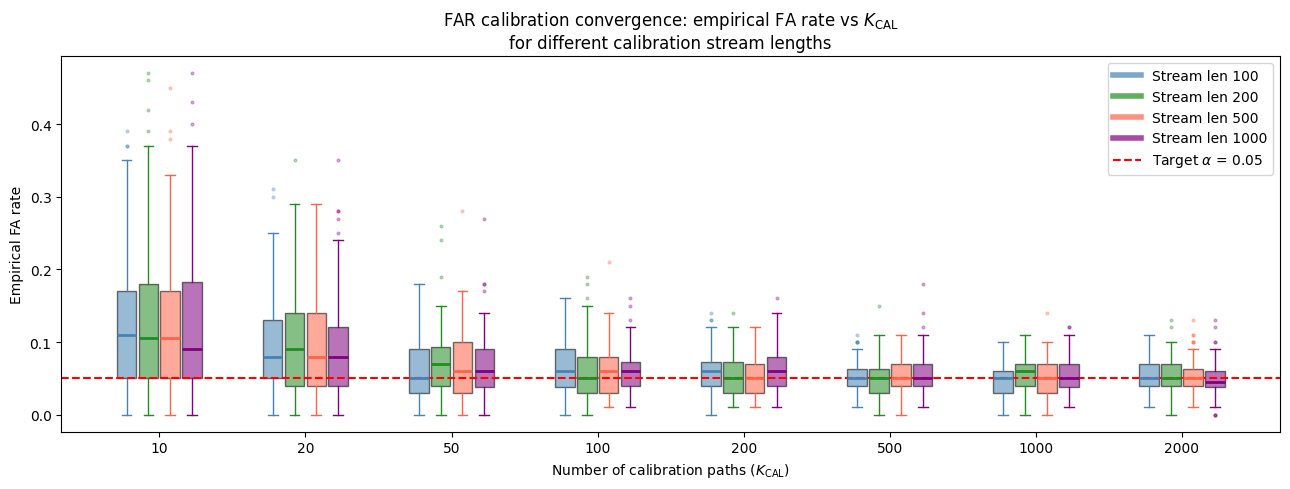

In [11]:
# FAR convergence: grouped box plot by stream length
# ===================================================
import matplotlib.pyplot as plt
import numpy as np

colors = {100: "steelblue", 200: "forestgreen", 500: "tomato", 1000: "purple"}
n_K = len(K_CAL_VALUES)
n_L = len(STREAM_LENS)
width = 0.6 / n_L
offsets = np.linspace(-(n_L - 1) / 2, (n_L - 1) / 2, n_L) * width

fig, ax = plt.subplots(figsize=(13, 5))

for i, sl in enumerate(STREAM_LENS):
    fm = far_matrices[sl]
    positions = np.arange(1, n_K + 1) + offsets[i]
    ax.boxplot(
        fm.T,
        positions=positions,
        widths=width * 0.9,
        patch_artist=True,
        boxprops=dict(facecolor=colors[sl], alpha=0.55),
        medianprops=dict(color=colors[sl], linewidth=2),
        whiskerprops=dict(color=colors[sl]),
        capprops=dict(color=colors[sl]),
        flierprops=dict(
            marker="o", markersize=2, alpha=0.3,
            markerfacecolor=colors[sl], markeredgecolor=colors[sl],
        ),
        manage_ticks=False,
    )
    ax.plot([], [], color=colors[sl], linewidth=4, alpha=0.7,
            label=f"Stream len {sl}")

ax.axhline(ALPHA, color="r", linestyle="--", label=rf"Target $\alpha$ = {ALPHA}")
ax.set_xticks(range(1, n_K + 1))
ax.set_xticklabels(K_CAL_VALUES)
ax.set_xlabel("Number of calibration paths ($K_{\mathrm{CAL}}$)")
ax.set_ylabel("Empirical FA rate")
ax.set_title(
    "FAR calibration convergence: empirical FA rate vs $K_{\mathrm{CAL}}$\n"
    "for different calibration stream lengths"
)
ax.legend()
plt.tight_layout()
plt.show()


### FAR as $t \gg N_{\mathrm{sim}}$

Calibrate the detector to a false alarm rate of α=0.05 **at a fixed horizon N=100**,
then examine how the actual false alarm rate grows as the stream gets longer.

**Method:** Simulate K long null streams once using `mc_alarm_times`, then sweep
over horizons L afterwards: `FA_rate(L) = mean(alarm_time <= L)`.
This is the empirical CDF of null alarm times — no re-simulation per horizon.

Calibration done in 36.64s. Threshold: 3.0141
Done. 50,000 null paths, threshold=3.0141


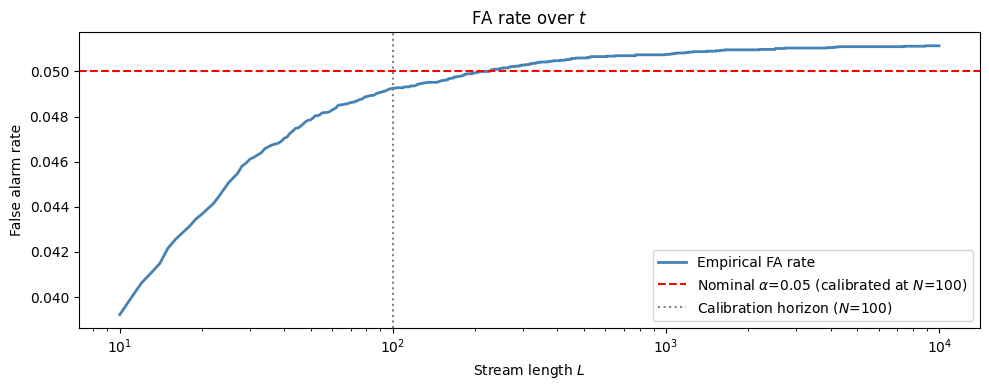

In [78]:
import numpy as np                                                                                                                                                                                            
import matplotlib.pyplot as plt                                                                                                                                                                               
from gridcp import GridDetector                                                                                                                                                                               
from gridcp.calibration import calibrate_threshold_false_alarm, with_calibrated_threshold, mc_alarm_times                                                                                                     
from gridcp.scores import MeanCUSUM                                                                                                                                                                           
from gridcp.typing import PenaltyType
                                                                                                                                                                                                              
ALPHA = 0.05
N_CAL = 100
K_CAL = 100000
K_SIM = 50000
L_MAX = 10000

score    = MeanCUSUM()                                                                                                                                                            
detector = GridDetector(score=score)
sampler  = lambda rng=None: rng.standard_normal()                                                                                                                                                             
start_time = time.perf_counter()              
threshold = calibrate_threshold_false_alarm(
    score, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N_CAL,                                                                                                                                                                          
    pre_sampler=sampler, rng=0,
)
print(f"Calibration done in {time.perf_counter() - start_time:.2f}s. Threshold: {threshold:.4f}")                                                                                                                                                                            
detector_cal = with_calibrated_threshold(detector, threshold)
alarm_times  = mc_alarm_times(detector_cal, K_SIM, L_MAX, pre_sampler=sampler, rng=1)
print(f"Done. {K_SIM:,} null paths, threshold={threshold:.4f}")                                                                                                                                               
                                                                                                                                                                                                              
# --- plot ---                                                                                                                                                                                                
L_SWEEP   = np.unique(np.geomspace(N_CAL // 10, L_MAX, 5_000).astype(int))                                                                                                                                    
at_sorted = np.sort(alarm_times)                                                                                                                                                                              
far_curve = np.searchsorted(at_sorted, L_SWEEP, side="right") / K_SIM
                                                                                                                                                                                                              
fig, ax = plt.subplots(figsize=(10, 4))                                                                                                                                                                       
ax.plot(L_SWEEP[:-1], far_curve[:-1], color="steelblue", linewidth=2, label="Empirical FA rate")                                                                                                                        
ax.axhline(ALPHA, color="r", linestyle="--", label=rf"Nominal $\alpha$={ALPHA} (calibrated at $N$={N_CAL})")                                                                                                  
ax.axvline(N_CAL, color="gray", linestyle=":", label=f"Calibration horizon ($N$={N_CAL})")                                                                                                                    
ax.set_xscale("log")                                                                                                                                                                                          
ax.set_xlabel("Stream length $L$")                                                                                                                                                                            
ax.set_ylabel("False alarm rate")                                                                                                                                                                             
ax.set_title(f"FA rate over $t$")
ax.legend()                                                                                                                                                                                                   
plt.tight_layout()
plt.show()

## Test on well-log dataset

Test the detector on the **Well-log** dataset from the 
[Turing Change Point Dataset](https://github.com/alan-turing-institute/TCPD): 
675 nuclear magnetic resonance measurements from a drill, 
with several abrupt level shifts corresponding to changes in rock strata.
Threshold is calibrated via circular block bootstrap on the first 20% of the stream.
Ground truth changepoints are derived by majority vote across annotators.

In [122]:
# --- Imports ---
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from gridcp import (
    GridDetector,
    calibrate_detector_threshold_false_alarm_from_data,
    with_calibrated_threshold,
)
from gridcp.scores import MeanCUSUMUnknownVariance

TCPD = "/uio/hume/student-u56/espenbur/Desktop/TCPD"
DATASET = "well_log"


In [123]:
# --- Load data and annotations ---
with open(f"{TCPD}/datasets/{DATASET}/{DATASET}.json") as f:
    d = json.load(f)
data = np.array(d["series"][0]["raw"], dtype=float)

with open(f"{TCPD}/annotations.json") as f:
    annotations = json.load(f)
annotator_cps = annotations[DATASET]  # dict: annotator_id -> list of CP indices

print(f"n_obs = {len(data)}")
for k, v in annotator_cps.items():
    print(f"  Annotator {k} ({len(v)} CPs): {v}")


n_obs = 675
  Annotator 6 (11 CPs): [179, 255, 281, 311, 343, 402, 413, 422, 432, 462, 464]
  Annotator 7 (9 CPs): [179, 255, 281, 312, 343, 402, 412, 422, 432]
  Annotator 8 (9 CPs): [179, 255, 282, 312, 343, 402, 413, 422, 432]
  Annotator 12 (2 CPs): [177, 467]
  Annotator 13 (17 CPs): [4, 179, 255, 281, 311, 344, 402, 412, 422, 432, 462, 464, 521, 526, 620, 643, 661]


In [125]:
# --- Choose which changepoints to use as ground truth ---
# Inspect the plot above and set true_cps to the indices you want.
# Example options:
#   true_cps = annotator_cps["7"]          # use a single annotator
#   true_cps = [179, 255, 343, 402, 422]   # pick manually

true_cps = sorted(annotator_cps["7"])  # default: annotator 7 (edit as needed)
print(f"Using {len(true_cps)} CPs: {true_cps}")


Using 9 CPs: [179, 255, 281, 312, 343, 402, 412, 422, 432]


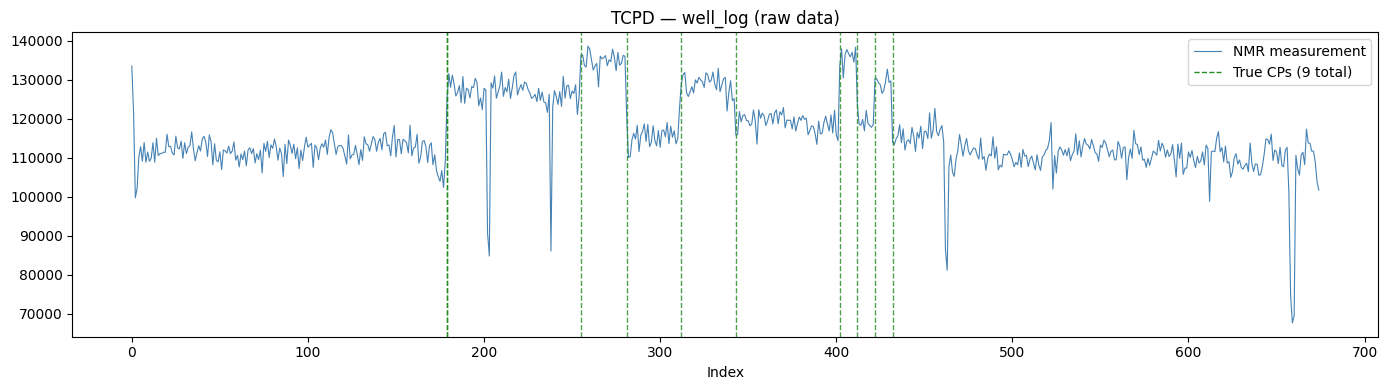

In [126]:
# --- Plot raw data with ground truth changepoints ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(data, color="steelblue", linewidth=0.8, label="NMR measurement")
for cp in true_cps:
    ax.axvline(cp, color="forestgreen", linestyle="--", linewidth=1, alpha=0.8)
ax.axvline(true_cps[0], color="forestgreen", linestyle="--", linewidth=1,
           label=f"True CPs ({len(true_cps)} total)")  # single legend entry
ax.set_title(f"TCPD — {DATASET} (raw data)")
ax.set_xlabel("Index")
ax.legend()
plt.tight_layout()
plt.show()


In [147]:
# --- Calibrate threshold via block bootstrap on first 20% of stream ---
training_data = data[5: 155]
print(f"Training set: first {len(training_data)} obs (assumed change-free)")

score = MeanCUSUMUnknownVariance()
detector = GridDetector(score)
threshold = calibrate_detector_threshold_false_alarm_from_data(
    detector,
    training_data=training_data,
    false_alarm_probability=0.05,
    stream_len=len(data),
    n_paths=2000,
)
detector = with_calibrated_threshold(detector, threshold)
print(f"Calibrated threshold: {threshold:.4f}")


Training set: first 150 obs (assumed change-free)
Calibrated threshold: 2.8498


In [148]:
# --- Run detector ---
state = detector.init_state()
alarms = []
scores = []
offset = 0
for i, x in enumerate(data):
    state, output = detector.update(state, np.array([x]))
    scores.append(output["max_score"])
    if output["alarm"]:
        cp_local = state.grid[output["max_score_index"]]  # CP time relative to last reset
        alarms.append({"alarm_at": i, "cp_estimate": offset + cp_local})
        offset = i + 1
        state = detector.init_state()

detected_cps = [a["cp_estimate"] for a in alarms]
print(f"Detected {len(detected_cps)} CPs: {detected_cps}")
print(f"True      {len(true_cps)} CPs: {true_cps}")


Detected 14 CPs: [173, 201, 236, 255, 280, 311, 342, 401, 412, 422, 432, 461, 469, 656]
True      9 CPs: [179, 255, 281, 312, 343, 402, 412, 422, 432]


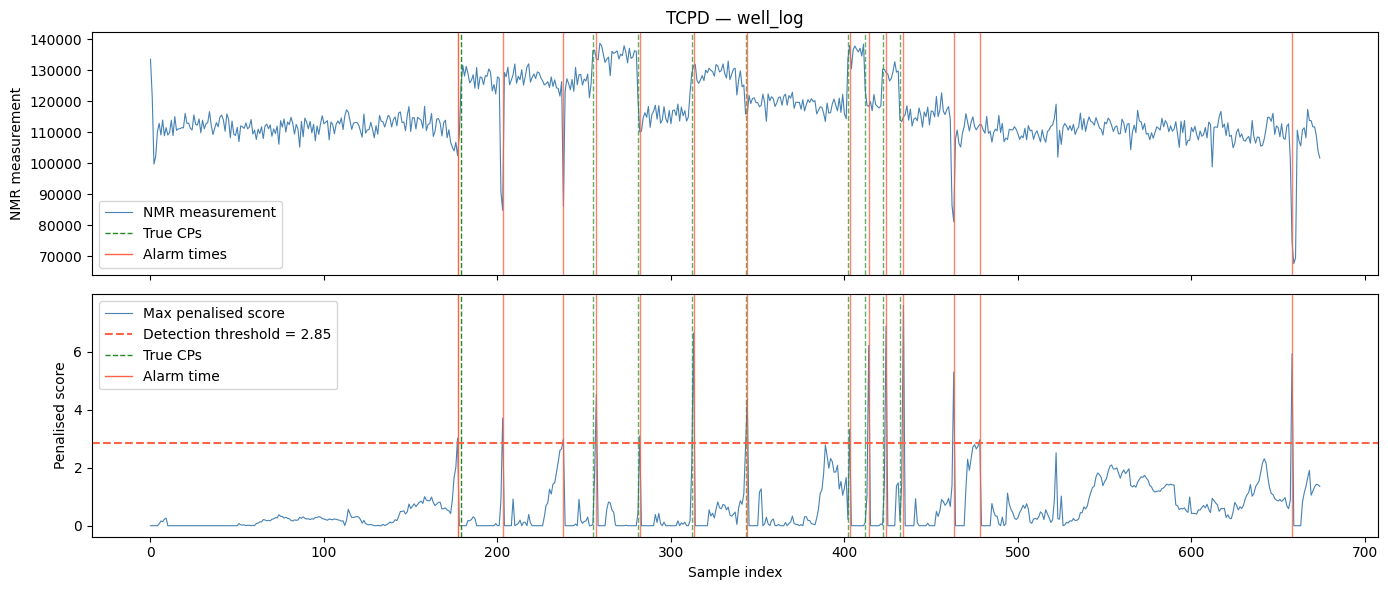

In [149]:
# --- Plot penalised score vs threshold over time ---
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Top: raw data
axes[0].plot(data, color="steelblue", linewidth=0.8, label="NMR measurement")
axes[0].axvline(true_cps[0], color="forestgreen", linestyle="--", linewidth=1,
                label=f"True CPs")
for cp in true_cps[1:]:
    axes[0].axvline(cp, color="forestgreen", linestyle="--", linewidth=1, alpha=0.7)
axes[0].axvline(alarms[0]["alarm_at"], color="tomato", linestyle="-", linewidth=1,
                label=f"Alarm times")
for a in alarms[1:]:
    axes[0].axvline(a["alarm_at"], color="tomato", linestyle="-", linewidth=1, alpha=0.8)
axes[0].set_ylabel("NMR measurement")
axes[0].set_title(f"TCPD — {DATASET}")
axes[0].legend(loc="lower left")

# Bottom: penalised score vs threshold
# Score resets to 0 after each alarm (detector restarts from scratch)
axes[1].plot(scores, color="steelblue", linewidth=0.8, label="Max penalised score")
axes[1].axhline(detector.threshold, color="tomato", linestyle="--", linewidth=1.5,
                label=f"Detection threshold = {detector.threshold:.2f}")
axes[1].axvline(true_cps[0], color="forestgreen", linestyle="--", linewidth=1,
                label="True CPs")
for cp in true_cps[1:]:
    axes[1].axvline(cp, color="forestgreen", linestyle="--", linewidth=1, alpha=0.7)
axes[1].axvline(alarms[0]["alarm_at"], color="tomato", linestyle="-", linewidth=1,
                label="Alarm time")
for a in alarms[1:]:
    axes[1].axvline(a["alarm_at"], color="tomato", linestyle="-", linewidth=1, alpha=0.8)
axes[1].set_ylabel("Penalised score")
axes[1].set_xlabel("Sample index")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()


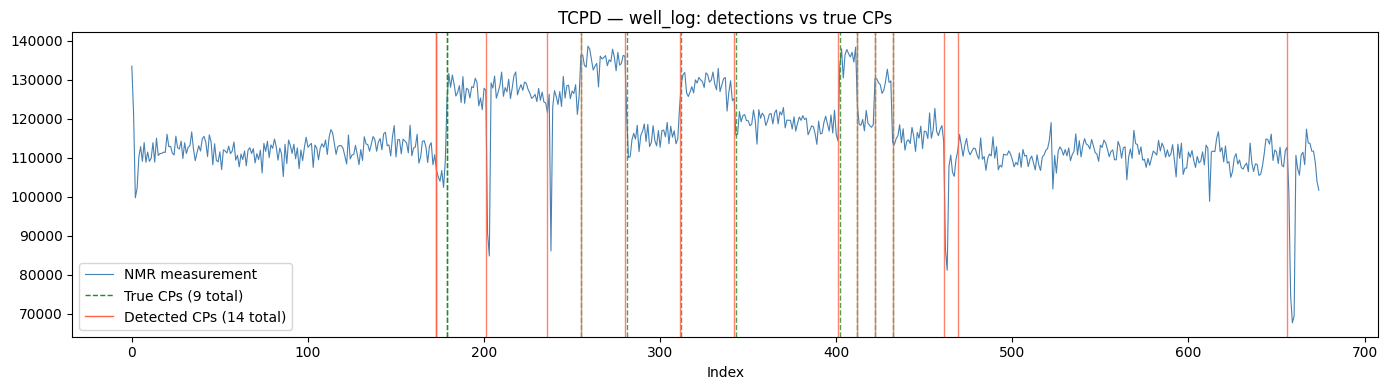

In [150]:
# --- Plot detections vs ground truth ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(data, color="steelblue", linewidth=0.8, label="NMR measurement")
for cp in true_cps:
    ax.axvline(cp, color="forestgreen", linestyle="--", linewidth=1, alpha=0.8)
ax.axvline(true_cps[0], color="forestgreen", linestyle="--", linewidth=1,
           label=f"True CPs ({len(true_cps)} total)")
for cp in detected_cps:
    ax.axvline(cp, color="tomato", linestyle="-", linewidth=1, alpha=0.8)
if detected_cps:
    ax.axvline(detected_cps[0], color="tomato", linestyle="-", linewidth=1,
               label=f"Detected CPs ({len(detected_cps)} total)")
ax.set_title(f"TCPD — {DATASET}: detections vs true CPs")
ax.set_xlabel("Index")
ax.legend()
plt.tight_layout()
plt.show()


### Reset at estimated CP (with replay)

Instead of discarding samples between the estimated changepoint and the alarm time, we reset at the estimated CP and replay those samples into the fresh detector state. This avoids data loss at each reset.

In [151]:
# --- Run detector (reset at estimated CP, with replay) ---
state2 = detector.init_state()
alarms2 = []
scores2 = []
offset2 = 0
for i, x in enumerate(data):
    state2, output2 = detector.update(state2, np.array([x]))
    scores2.append(output2["max_score"])
    if output2["alarm"]:
        cp_local = state2.grid[output2["max_score_index"]]
        cp_abs = offset2 + cp_local
        alarms2.append({"alarm_at": i, "cp_estimate": cp_abs})
        # Reset at estimated CP and replay samples up to current
        offset2 = cp_abs
        state2 = detector.init_state()
        for x_replay in data[cp_abs : i + 1]:
            state2, _ = detector.update(state2, np.array([x_replay]))

detected_cps2 = [a["cp_estimate"] for a in alarms2]
print(f"Detected {len(detected_cps2)} CPs: {detected_cps2}")
print(f"True      {len(true_cps)} CPs: {true_cps}")


Detected 16 CPs: [173, 179, 201, 258, 280, 312, 315, 320, 341, 401, 412, 422, 432, 461, 656, 661]
True      9 CPs: [179, 255, 281, 312, 343, 402, 412, 422, 432]


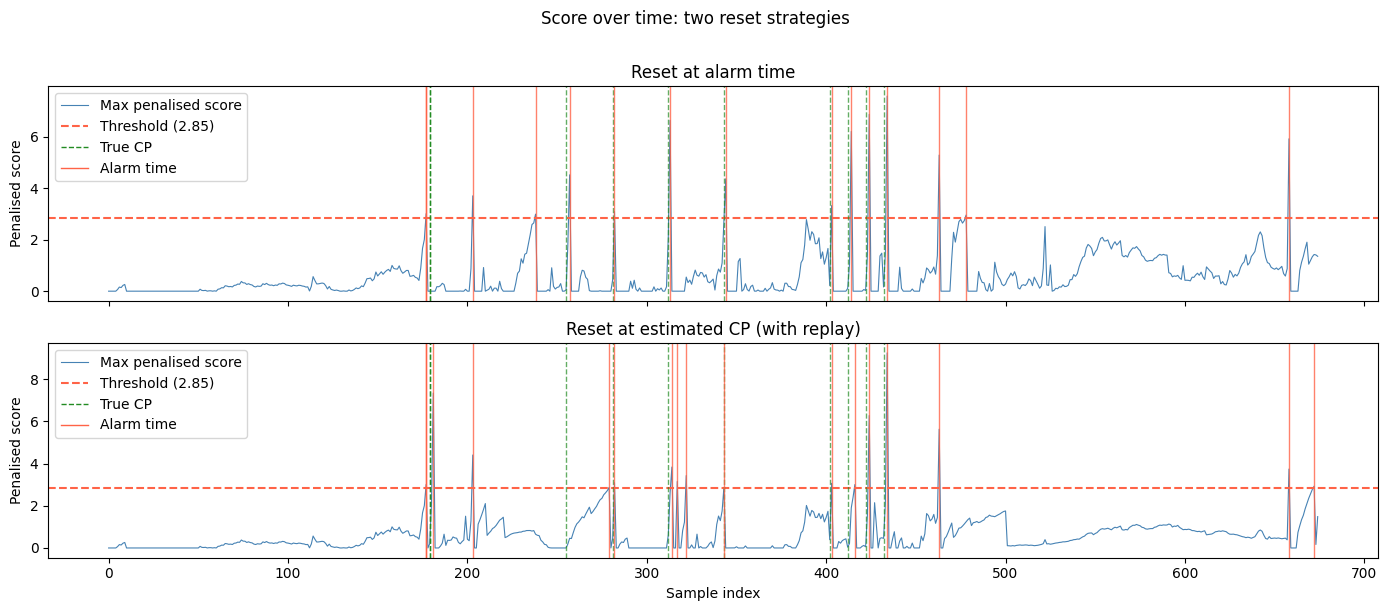

In [152]:
# --- Score plot: reset-at-alarm vs reset-at-CP ---
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

for ax, sc, al, label in [
    (axes[0], scores,  alarms,  "Reset at alarm time"),
    (axes[1], scores2, alarms2, "Reset at estimated CP (with replay)"),
]:
    ax.plot(sc, color="steelblue", linewidth=0.8, label="Max penalised score")
    ax.axhline(detector.threshold, color="tomato", linestyle="--", linewidth=1.5,
               label=f"Threshold ({detector.threshold:.2f})")
    for cp in true_cps:
        ax.axvline(cp, color="forestgreen", linestyle="--", linewidth=1, alpha=0.7)
    ax.axvline(true_cps[0], color="forestgreen", linestyle="--", linewidth=1,
               label="True CP")
    for a in al:
        ax.axvline(a["alarm_at"], color="tomato", linestyle="-", linewidth=1, alpha=0.8)
    ax.axvline(al[0]["alarm_at"], color="tomato", linestyle="-", linewidth=1,
               label="Alarm time")
    ax.set_ylabel("Penalised score")
    ax.set_title(label)
    ax.legend(loc="upper left")

axes[1].set_xlabel("Sample index")
plt.suptitle("Score over time: two reset strategies", y=1.01)
plt.tight_layout()
plt.show()


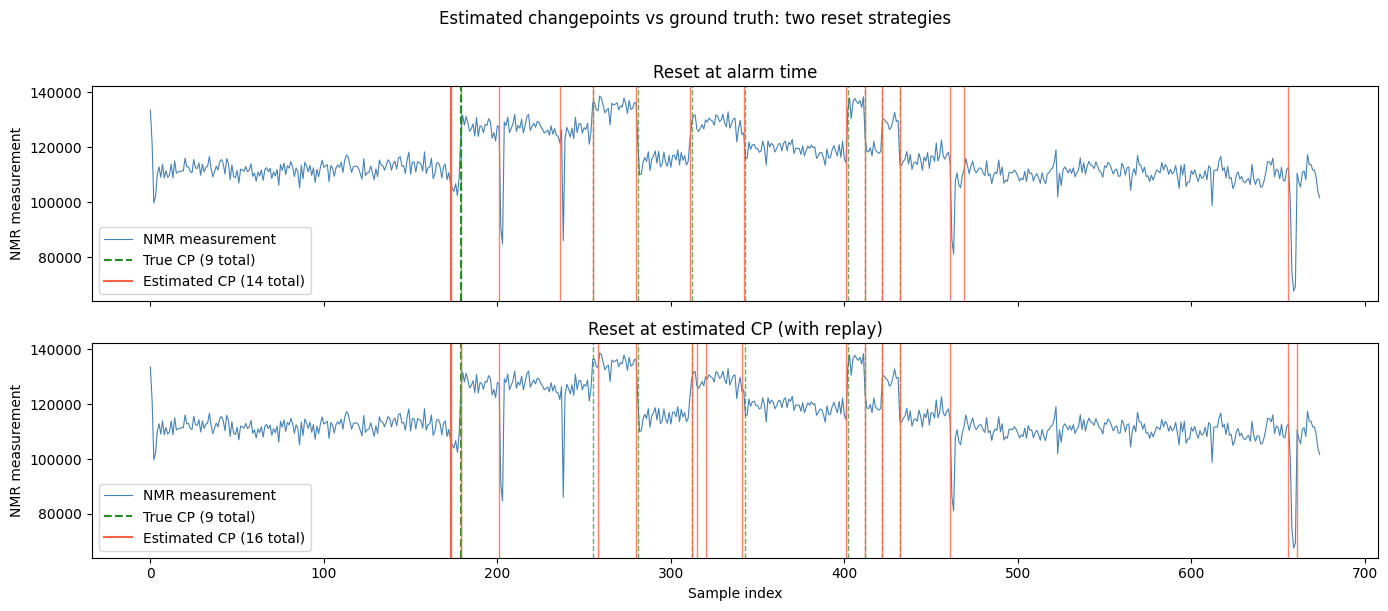

In [153]:
# --- Detections vs ground truth: two reset strategies side by side ---
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

for ax, al, label in [
    (axes[0], alarms,  "Reset at alarm time"),
    (axes[1], alarms2, "Reset at estimated CP (with replay)"),
]:
    ax.plot(data, color="steelblue", linewidth=0.8, label="NMR measurement")
    for cp in true_cps:
        ax.axvline(cp, color="forestgreen", linestyle="--", linewidth=1, alpha=0.7)
    ax.axvline(true_cps[0], color="forestgreen", linestyle="--",
               label=f"True CP ({len(true_cps)} total)")
    cps = [a["cp_estimate"] for a in al]
    for cp in cps:
        ax.axvline(cp, color="tomato", linestyle="-", linewidth=1, alpha=0.8)
    if cps:
        ax.axvline(cps[0], color="tomato", linestyle="-",
                   label=f"Estimated CP ({len(cps)} total)")
    ax.set_ylabel("NMR measurement")
    ax.set_title(label)
    ax.legend(loc="lower left")

axes[1].set_xlabel("Sample index")
plt.suptitle("Estimated changepoints vs ground truth: two reset strategies", y=1.01)
plt.tight_layout()
plt.show()
